# Exploration of credit card fraud detection
 ## Objective 
 - The primary objective of using this dataset is to detect fraudulent transactions in an online payment system.


- Build a binary classification model that predicts whether a transaction is fraudulent (1) or legitimate (0).

- Learn patterns from both transaction-level data and identity-related data.

- Accurately identify fraud while handling high class imbalance and heterogeneous data types.

This dataset enables the analysis of transaction behavior combined with user/device identity information,

**used data source**

- https://www.kaggle.com/code/kabure/extensive-eda-and-modeling-xgb-hyperopt


## Dataset Overview
 - The dataset consists of four separate CSV files, divided into training and testing sets, and further split into **transaction data** and **identity data**.
 **Files Included**

- train_transaction.csv 

- test_transaction.csv

- train_identity.csv

- test_identity.csv

The datasets are linked using a common identifier: **TransactionID**.


Fraud detection is challenging due to:
- Severe class imbalance  
- High-dimensional anonymized features  
- Mixed data types (categorical, numerical, identity-based)

---

##### Notebook Roadmap

1. Data Loading  
2. Memory Optimization  
3. Exploratory Data Analysis (EDA)  
4. Missing Values & Data Quality Checks  
5. Feature Engineering  
6. Model Building 
7. Model Evaluation  
8. Next Steps

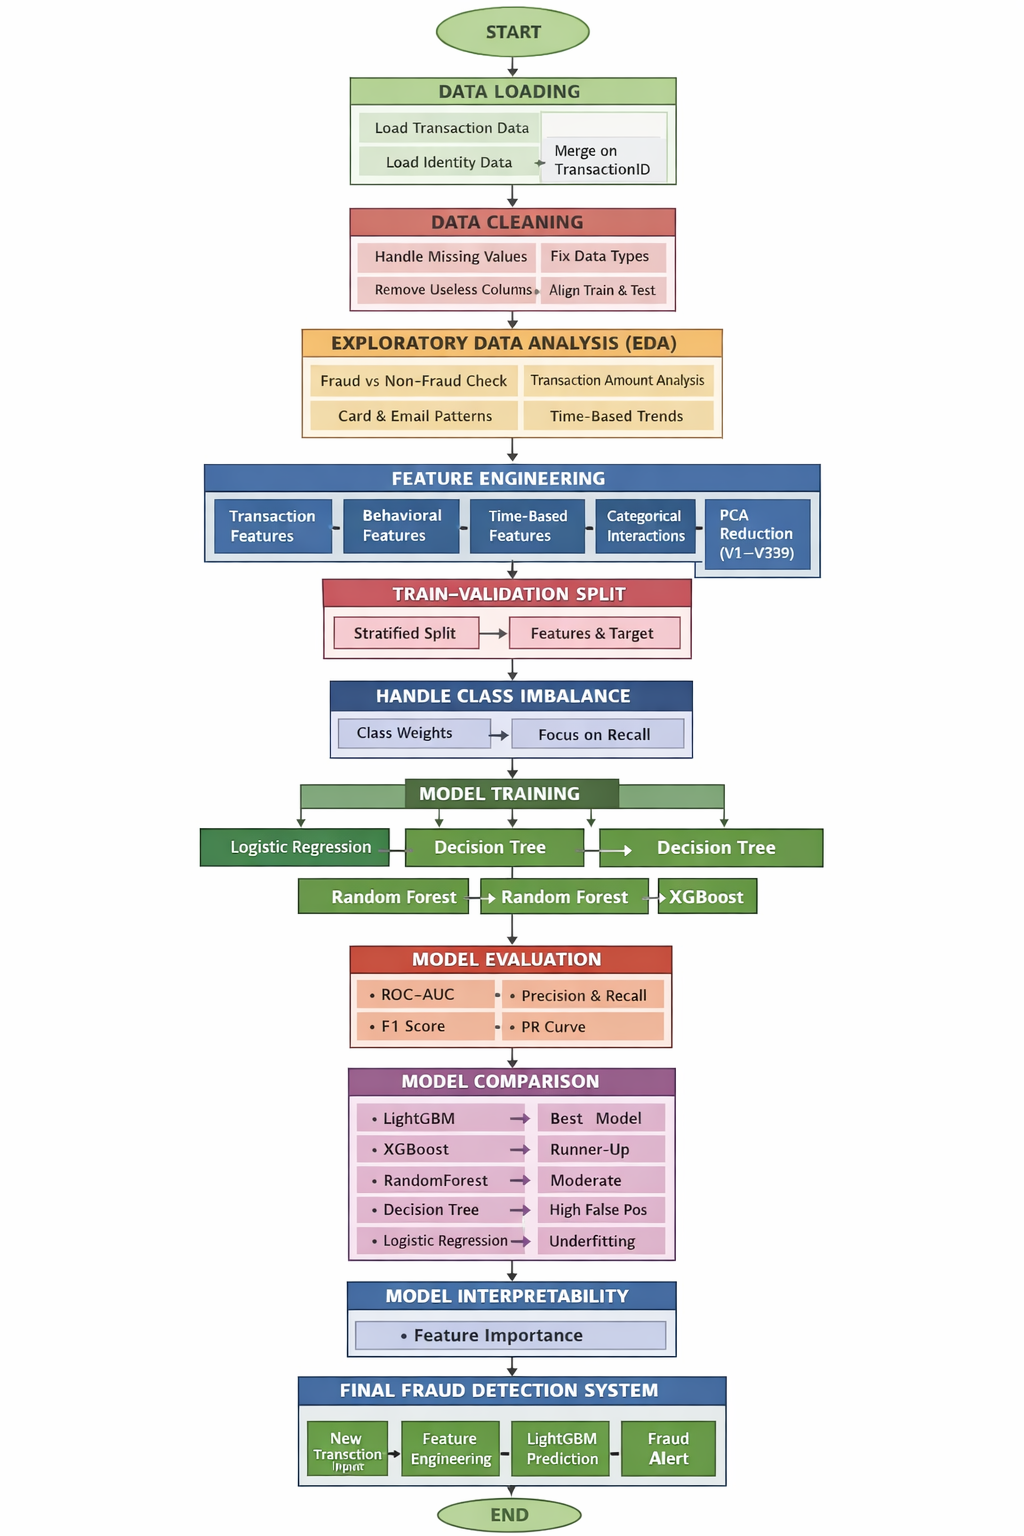



## Import required libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import gc
import os
from IPython.display import Markdown, display

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)

## Load Datasets

In [ ]:
train_transaction = pd.read_csv('C:\\Users\\LENOVO\\Desktop\\Project with Pujan\\frauddetection\\data\\train_transaction.csv')
test_transaction = pd.read_csv('C:\\Users\\LENOVO\\Desktop\\Project with Pujan\\frauddetection\\data\\test_transaction.csv')


# Load identity data
print("Loading identity data...")
train_identity = pd.read_csv('C:\\Users\\LENOVO\\Desktop\\Project with Pujan\\frauddetection\\data\\train_identity.csv')
test_identity = pd.read_csv('C:\\Users\\LENOVO\Desktop\\Project with Pujan\\frauddetection\\data\\test_identity.csv')

Loading identity data...


## Data Understanding 

### Sample data

In [3]:
train_transaction.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,M1,M2,M3,M4,...,V290,V291,V292,V293,V294,V295,V296,V297,V298,V299,V300,V301,V302,V303,V304,V305,V306,V307,V308,V309,V310,V311,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321,V322,V323,V324,V325,V326,V327,V328,V329,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,credit,315.0,87.0,19.0,NaN,NaN,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0,1.0,1.0,14.0,NaN,13.0,NaN,NaN,NaN,NaN,NaN,NaN,13.0,13.0,NaN,NaN,NaN,0.0,T,T,T,M2,...,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,credit,325.0,87.0,NaN,NaN,gmail.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,M0,...,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,debit,330.0,87.0,287.0,NaN,outlook.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,315.0,NaN,NaN,NaN,315.0,T,T,T,M0,...,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,debit,476.0,87.0,NaN,NaN,yahoo.com,NaN,2.0,5.0,0.0,0.0,0.0,4.0,0.0,0.0,1.0,0.0,1.0,0.0,25.0,1.0,112.0,112.0,0.0,94.0,0.0,NaN,NaN,NaN,NaN,84.0,NaN,NaN,NaN,NaN,111.0,NaN,NaN,NaN,M0,...,1.0,1.0,1.0,1.0,38.0,24.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,50.0,1758.0,925.0,0.0,354.0,0.0,135.0,0.0,0.0,0.0,50.0,1404.0,790.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,credit,420.0,87.0,NaN,NaN,gmail.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
train_identity.head()

,TransactionID,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,id_10,id_11,id_12,id_13,id_14,id_15,id_16,id_17,id_18,id_19,id_20,id_21,id_22,id_23,id_24,id_25,id_26,id_27,id_28,id_29,id_30,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987004,0.0,70787.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100.0,NotFound,NaN,-480.0,New,NotFound,166.0,NaN,542.0,144.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,New,NotFound,Android 7.0,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M
1,2987008,-5.0,98945.0,NaN,NaN,0.0,-5.0,NaN,NaN,NaN,NaN,100.0,NotFound,49.0,-300.0,New,NotFound,166.0,NaN,621.0,500.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,New,NotFound,iOS 11.1.2,mobile safari 11.0,32.0,1334x750,match_status:1,T,F,F,T,mobile,iOS Device
2,2987010,-5.0,191631.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,100.0,NotFound,52.0,NaN,Found,Found,121.0,NaN,410.0,142.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Found,Found,NaN,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,Windows
3,2987011,-5.0,221832.0,NaN,NaN,0.0,-6.0,NaN,NaN,NaN,NaN,100.0,NotFound,52.0,NaN,New,NotFound,225.0,NaN,176.0,507.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,New,NotFound,NaN,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,NaN
4,2987016,0.0,7460.0,0.0,0.0,1.0,0.0,NaN,NaN,0.0,0.0,100.0,NotFound,NaN,-300.0,Found,Found,166.0,15.0,529.0,575.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Found,Found,Mac OS X 10_11_6,chrome 62.0,24.0,1280x800,match_status:2,T,F,T,T,desktop,MacOS


### Memory Optimization

In [5]:
def reduce_mem_usage(df, verbose=True):
    numerics = ['int16', 'int32', 'int64', 'float16', 'float32', 'float64']
    start_mem = df.memory_usage().sum() / 1024**2    
    if verbose:
        print(f"Memory usage of dataframe is {start_mem:.2f} MB")
    
    for col in df.columns:
        col_type = df[col].dtypes
        if col_type in numerics:
            c_min = df[col].min()
            c_max = df[col].max()
            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
                else:
                    df[col] = df[col].astype(np.int64)  
            else:
                if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
                    df[col] = df[col].astype(np.float16)
                elif c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
                else:
                    df[col] = df[col].astype(np.float64)    
    
    end_mem = df.memory_usage().sum() / 1024**2
    if verbose:
        print(f"Memory usage after optimization is: {end_mem:.2f} MB")
        print(f"Decreased by {(100 * (start_mem - end_mem) / start_mem):.1f}%")
    return df

# Example usage
df_trans = reduce_mem_usage(train_transaction)
df_id = reduce_mem_usage(train_identity)


Memory usage of dataframe is 1775.15 MB
Memory usage after optimization is: 542.35 MB
Decreased by 69.4%
Memory usage of dataframe is 45.12 MB
Memory usage after optimization is: 25.86 MB
Decreased by 42.7%


### General Dataset Overview
We generate key statistics for each dataset, including:

- Number of rows and columns

- Memory usage

- Duplicate records

- Missing values and percentage

- Unique values per column

- Data types and previews of columns

In [6]:
def generate_general_info_preview(df, preview_count=20):
    """Generate general info DataFrame for a single DataFrame, including missing values and unique counts."""
    
    # General info
    memory_gb = df.memory_usage(deep=True).sum() / (1024**3)
    duplicate_count = df.duplicated().sum()
    total_missing = df.isnull().sum().sum()
    missing_percent = (total_missing / (df.shape[0] * df.shape[1])) * 100
    total_unique = df.nunique().sum()
    
    general_info = pd.DataFrame({
        "Feature": [
            "Total Rows",
            "Total Columns",
            "Memory Usage (GB)",
            "Duplicate Records",
            "Total Missing Values",
            "Missing Value (%)",
            "Total Unique Values"
        ],
        "Value": [
            df.shape[0],
            df.shape[1],
            f"{memory_gb:.2f}",
            duplicate_count,
            total_missing,
            f"{missing_percent:.2f}%",
            total_unique
        ],
        "Columns List": [
            "",
            "",
            "",
            "",
            "",
            "",
            ""
        ]
    })
    
    # Get dtype info with preview and unique count per type
    dtype_counts = df.dtypes.value_counts()
    for dtype, count in dtype_counts.items():
        cols_of_type = df.select_dtypes(include=[dtype]).columns.tolist()
        preview_cols = cols_of_type[:preview_count]
        preview_str = ", ".join(preview_cols)
        if len(cols_of_type) > preview_count:
            preview_str += ", …"
        
        # Unique count for this dtype
        unique_count = df[cols_of_type].nunique().sum()
        
        general_info = pd.concat([general_info, pd.DataFrame({
            "Feature": [f"Columns with dtype {dtype}"],
            "Value": [f"{count} (Unique: {unique_count})"],
            "Columns List": [preview_str]
        })], ignore_index=True)
    
    return general_info

# Dictionary of datasets
datasets = {
    "Train Transaction": df_trans,
    "Test Transaction": test_transaction,
    "Train Identity": df_id,
    "Test Identity": test_identity
}

# Loop through each dataset and display markdown
for name, df in datasets.items():
    general_info = generate_general_info_preview(df, preview_count=20)
    md_table = general_info.to_markdown(index=False)
    display(Markdown(f"### {name} General Info\n{md_table}"))

### Train Transaction General Info
| Feature                    | Value                | Columns List                                                                                                              |
|:---------------------------|:---------------------|:--------------------------------------------------------------------------------------------------------------------------|
| Total Rows                 | 590540               |                                                                                                                           |
| Total Columns              | 394                  |                                                                                                                           |
| Memory Usage (GB)          | 0.85                 |                                                                                                                           |
| Duplicate Records          | 0                    |                                                                                                                           |
| Total Missing Values       | 95566686             |                                                                                                                           |
| Missing Value (%)          | 41.07%               |                                                                                                                           |
| Total Unique Values        | 1695729              |                                                                                                                           |
| Columns with dtype float16 | 332 (Unique: 156168) | TransactionAmt, card2, card3, card5, addr1, addr2, dist1, dist2, C1, C2, C3, C4, C5, C6, C7, C8, C9, C10, C11, C12, …     |
| Columns with dtype float32 | 44 (Unique: 361966)  | V126, V127, V128, V132, V133, V134, V135, V136, V137, V160, V164, V165, V166, V202, V203, V204, V211, V212, V213, V214, … |
| Columns with dtype object  | 14 (Unique: 151)     | ProductCD, card4, card6, P_emaildomain, R_emaildomain, M1, M2, M3, M4, M5, M6, M7, M8, M9                                 |
| Columns with dtype int32   | 2 (Unique: 1163889)  | TransactionID, TransactionDT                                                                                              |
| Columns with dtype int8    | 1 (Unique: 2)        | isFraud                                                                                                                   |
| Columns with dtype int16   | 1 (Unique: 13553)    | card1                                                                                                                     |

### Test Transaction General Info
| Feature                    | Value                | Columns List                                                                                                          |
|:---------------------------|:---------------------|:----------------------------------------------------------------------------------------------------------------------|
| Total Rows                 | 506691               |                                                                                                                       |
| Total Columns              | 393                  |                                                                                                                       |
| Memory Usage (GB)          | 1.77                 |                                                                                                                       |
| Duplicate Records          | 0                    |                                                                                                                       |
| Total Missing Values       | 73490163             |                                                                                                                       |
| Missing Value (%)          | 36.91%               |                                                                                                                       |
| Total Unique Values        | 1498827              |                                                                                                                       |
| Columns with dtype float64 | 376 (Unique: 484055) | TransactionAmt, card2, card3, card5, addr1, addr2, dist1, dist2, C1, C2, C3, C4, C5, C6, C7, C8, C9, C10, C11, C12, … |
| Columns with dtype object  | 14 (Unique: 151)     | ProductCD, card4, card6, P_emaildomain, R_emaildomain, M1, M2, M3, M4, M5, M6, M7, M8, M9                             |
| Columns with dtype int64   | 3 (Unique: 1014621)  | TransactionID, TransactionDT, card1                                                                                   |

### Train Identity General Info
| Feature                    | Value              | Columns List                                                                                                                                  |
|:---------------------------|:-------------------|:----------------------------------------------------------------------------------------------------------------------------------------------|
| Total Rows                 | 144233             |                                                                                                                                               |
| Total Columns              | 41                 |                                                                                                                                               |
| Memory Usage (GB)          | 0.14               |                                                                                                                                               |
| Duplicate Records          | 0                  |                                                                                                                                               |
| Total Missing Values       | 2104107            |                                                                                                                                               |
| Missing Value (%)          | 35.58%             |                                                                                                                                               |
| Total Unique Values        | 264995             |                                                                                                                                               |
| Columns with dtype float16 | 22 (Unique: 2826)  | id_01, id_03, id_04, id_05, id_06, id_07, id_08, id_09, id_10, id_11, id_13, id_14, id_17, id_18, id_19, id_20, id_21, id_22, id_24, id_25, … |
| Columns with dtype object  | 17 (Unique: 2281)  | id_12, id_15, id_16, id_23, id_27, id_28, id_29, id_30, id_31, id_33, id_34, id_35, id_36, id_37, id_38, DeviceType, DeviceInfo               |
| Columns with dtype int32   | 1 (Unique: 144233) | TransactionID                                                                                                                                 |
| Columns with dtype float32 | 1 (Unique: 115655) | id_02                                                                                                                                         |

### Test Identity General Info
| Feature                    | Value               | Columns List                                                                                                                                  |
|:---------------------------|:--------------------|:----------------------------------------------------------------------------------------------------------------------------------------------|
| Total Rows                 | 141907              |                                                                                                                                               |
| Total Columns              | 41                  |                                                                                                                                               |
| Memory Usage (GB)          | 0.15                |                                                                                                                                               |
| Duplicate Records          | 0                   |                                                                                                                                               |
| Total Missing Values       | 2105385             |                                                                                                                                               |
| Missing Value (%)          | 36.19%              |                                                                                                                                               |
| Total Unique Values        | 262514              |                                                                                                                                               |
| Columns with dtype float64 | 23 (Unique: 117742) | id-01, id-02, id-03, id-04, id-05, id-06, id-07, id-08, id-09, id-10, id-11, id-13, id-14, id-17, id-18, id-19, id-20, id-21, id-22, id-24, … |
| Columns with dtype object  | 17 (Unique: 2865)   | id-12, id-15, id-16, id-23, id-27, id-28, id-29, id-30, id-31, id-33, id-34, id-35, id-36, id-37, id-38, DeviceType, DeviceInfo               |
| Columns with dtype int64   | 1 (Unique: 141907)  | TransactionID                                                                                                                                 |

## Initial Data Insights

### Numerical and Categorical Summary

#####  Numerical features summary

In [7]:
df_trans.describe().T

,count,mean,std,min,25%,50%,75%,max
TransactionID,590540.0,3.282270e+06,1.704744e+05,2.987000e+06,3.134635e+06,3282269.50,3429904.25,3577539.0
isFraud,590540.0,3.499001e-02,1.837546e-01,0.000000e+00,0.000000e+00,0.00,0.00,1.0
TransactionDT,590540.0,7.372311e+06,4.617224e+06,8.640000e+04,3.027058e+06,7306527.50,11246620.00,15811131.0
TransactionAmt,590540.0,NaN,NaN,2.509766e-01,4.331250e+01,68.75,125.00,31936.0
card1,590540.0,9.898735e+03,4.901170e+03,1.000000e+03,6.019000e+03,9678.00,14184.00,18396.0
...,...,...,...,...,...,...,...,...
V335,82351.0,NaN,NaN,0.000000e+00,0.000000e+00,0.00,0.00,55136.0
V336,82351.0,NaN,NaN,0.000000e+00,0.000000e+00,0.00,0.00,55136.0
V337,82351.0,5.535242e+01,6.683759e+02,0.000000e+00,0.000000e+00,0.00,0.00,104060.0
V338,82351.0,1.511605e+02,1.095058e+03,0.000000e+00,0.000000e+00,0.00,0.00,104060.0


In [8]:
df_id.describe().T

,count,mean,std,min,25%,50%,75%,max
TransactionID,144233.0,3.236329e+06,1.788496e+05,2987004.0,3077142.0,3198818.0,3392923.0,3577534.0
id_01,144233.0,NaN,0.000000e+00,-100.0,-10.0,-5.0,-5.0,0.0
id_02,140872.0,1.747166e+05,1.596500e+05,1.0,67992.0,125800.5,228749.0,999595.0
id_03,66324.0,0.000000e+00,5.981445e-01,-13.0,0.0,0.0,0.0,10.0
id_04,66324.0,-0.000000e+00,7.011719e-01,-28.0,0.0,0.0,0.0,0.0
id_05,136865.0,NaN,0.000000e+00,-72.0,0.0,0.0,1.0,52.0
id_06,136865.0,NaN,0.000000e+00,-100.0,-6.0,0.0,0.0,0.0
id_07,5155.0,inf,1.138281e+01,-46.0,5.0,14.0,22.0,61.0
id_08,5155.0,-inf,2.607812e+01,-100.0,-48.0,-34.0,-23.0,0.0
id_09,74926.0,0.000000e+00,0.000000e+00,-36.0,0.0,0.0,0.0,25.0


##### Categorical Features

In [9]:
df_trans.describe(include='object').T

,count,unique,top,freq
ProductCD,590540,5,W,439670
card4,588963,4,visa,384767
card6,588969,4,debit,439938
P_emaildomain,496084,59,gmail.com,228355
R_emaildomain,137291,60,gmail.com,57147
M1,319440,2,T,319415
M2,319440,2,T,285468
M3,319440,2,T,251731
M4,309096,3,M0,196405
M5,240058,2,F,132491


In [10]:
df_id.describe(include='object').T

,count,unique,top,freq
id_12,144233,2,NotFound,123025
id_15,140985,3,Found,67728
id_16,129340,2,Found,66324
id_23,5169,3,IP_PROXY:TRANSPARENT,3489
id_27,5169,2,Found,5155
id_28,140978,2,Found,76232
id_29,140978,2,Found,74926
id_30,77565,75,Windows 10,21155
id_31,140282,130,chrome 63.0,22000
id_33,73289,260,1920x1080,16874


- `.describe()` is used for numerical and categorical features to understand distributions, min/max values, and unique categories.

### Missing Values
- Missing values are calculated and sorted to identify columns that require special treatment during preprocessing:

In [11]:
missing = df_trans.isnull().sum()
missing_df_trans = pd.DataFrame({
    'column': missing.index,
    'missing_count': missing.values,
    'missing_percent': (missing.values / len(df_trans)) * 100
}).sort_values(by='missing_count', ascending=False).query("missing_count > 0")

missing_df_trans

,column,missing_count,missing_percent
14,dist2,552913,93.628374
37,D7,551623,93.409930
43,D13,528588,89.509263
44,D14,528353,89.469469
42,D12,525823,89.041047
...,...,...,...
348,V294,12,0.002032
349,V295,12,0.002032
351,V297,12,0.002032
352,V298,12,0.002032


In [12]:
missing_id = df_id.isnull().sum()
missing_df_id = pd.DataFrame({
    'column': missing_id.index,
    'missing_count': missing_id.values,
    'missing_percent': (missing_id.values / len(df_id)) * 100
}).sort_values(by='missing_count', ascending=False).query("missing_count > 0")

missing_df_id

,column,missing_count,missing_percent
24,id_24,139486,96.708798
25,id_25,139101,96.441868
7,id_07,139078,96.425922
8,id_08,139078,96.425922
21,id_21,139074,96.423149
26,id_26,139070,96.420375
23,id_23,139064,96.416215
27,id_27,139064,96.416215
22,id_22,139064,96.416215
18,id_18,99120,68.722137


### Low Variance Features
- Columns where a single value dominates (>95%) are flagged as low-variance features, which may be uninformative for modeling:

In [13]:
low_variance_threshold = 95
for col in df_id.columns:
    class_dist = df_id[col].value_counts(normalize=True) * 100
    # Check if any class exceeds the imbalance threshold
    if (class_dist.max() > low_variance_threshold):
      print(f"*low variance detected in column ({col}): {class_dist.max():.2f}% for category '{class_dist.idxmax()}' ")

*low variance detected in column (id_03): 96.35% for category '0.0' 
*low variance detected in column (id_04): 99.12% for category '0.0' 
*low variance detected in column (id_10): 97.27% for category '0.0' 
*low variance detected in column (id_27): 99.73% for category 'Found' 
*low variance detected in column (id_36): 95.09% for category 'F' 


## Target Variable Overview

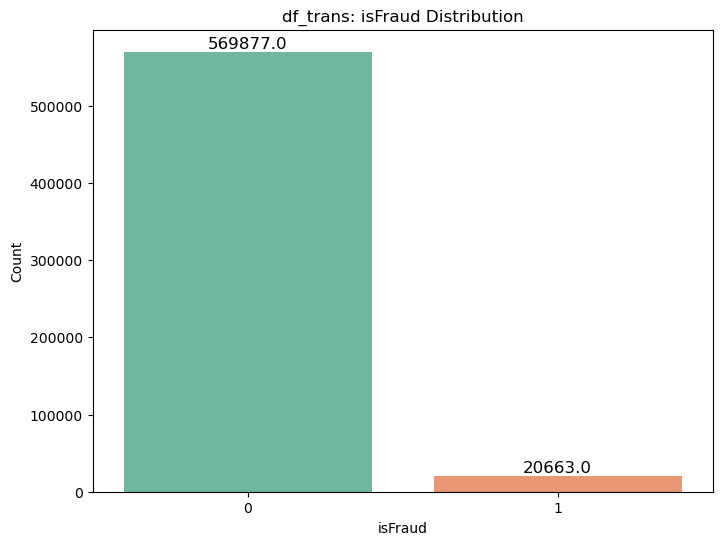

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.countplot(x='isFraud', data=df_trans, palette='Set2')

# Add counts on top of bars
for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height()}', 
                       (p.get_x() + p.get_width() / 2., p.get_height()), 
                       ha='center', va='bottom', fontsize=12)

plt.title('df_trans: isFraud Distribution')
plt.xlabel('isFraud')
plt.ylabel('Count')
plt.show()


- The target variable isFraud is highly imbalanced, which is typical in fraud detection datasets

## Dataset Relationships
- The TransactionID links transaction and identity data. Checking for overlap ensures correct merging during feature engineering

In [15]:
common_ids = len(set(df_trans['TransactionID']) & set(df_id['TransactionID']))
print("Number of common TransactionIDs:", common_ids)

Number of common TransactionIDs: 144233


In [16]:
# Number of transactions and identity rows
num_trans = df_trans.shape[0]
num_id = df_id.shape[0]

# Calculate percentage
identity_percentage = (num_id / num_trans) * 100



display(Markdown(f"""
### Identity Data Coverage

- Total transactions: {num_trans}  
- Transactions with identity information: {num_id} (~{identity_percentage:.2f}%)  

**Interpretation:**  
Only about **{identity_percentage:.2f}% of transactions** have corresponding identity/device data.  
This means most transactions (~{100-identity_percentage:.2f}%) do not have identity features, so when merging datasets:

- A **left join** should be used to keep all transactions.  
- Missing identity values must be handled carefully during modeling.  
- The presence or absence of identity data could itself be a **useful feature** for detecting fraud.
"""))



### Identity Data Coverage

- Total transactions: 590540  
- Transactions with identity information: 144233 (~24.42%)  

**Interpretation:**  
Only about **24.42% of transactions** have corresponding identity/device data.  
This means most transactions (~75.58%) do not have identity features, so when merging datasets:

- A **left join** should be used to keep all transactions.  
- Missing identity values must be handled carefully during modeling.  
- The presence or absence of identity data could itself be a **useful feature** for detecting fraud.


## Exploratory Data Analysis (EDA)

##### Skewness and Kurtosis

**Skewness & Kurtosis Insights**

- **Highly Right-Skewed** → indicates few extreme values. This is common in features like `TransactionAmt` in the transaction dataset.  

- **Leptokurtic (Heavy tails)** → shows lots of outliers, which are often important signals for detecting fraud.  

- **Constant Feature** → represents uninformative features that can potentially be dropped from modeling.  

**Comparison: `df_trans` vs `df_id`**

- **Transaction Features (`df_trans`)**:  
  - Often have **strong skew** and **high kurtosis**, highlighting extreme transaction amounts or unusual behavior.  
  - These features are highly informative for identifying fraudulent transactions.

- **Identity Features (`df_id`)**:  
  - Tend to be **more categorical** or numeric identifiers.  
  - Many numeric ID columns show **low variance** and **moderate skew**, making them less directly predictive.  
  - However, the presence or absence of identity data can itself be an informative signal for fraud detection.


In [17]:
def categorize_skew_kurt(df):
    """
    Returns a DataFrame with skewness and kurtosis for all numerical columns.
    """
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    skewness = df[numeric_cols].skew()
    kurt = df[numeric_cols].kurt()  # Fisher kurtosis (normal=0)

    result = pd.DataFrame({
        "Column": numeric_cols,
        "Skewness": skewness,
        "Kurtosis": kurt,
        "StdDev": df[numeric_cols].std()
    }).reset_index(drop=True)

    # Skewness type
    def get_skew_type(val):
        if val < -2:
            return "Highly Left-Skewed"
        elif val < -1:
            return "Moderately Left-Skewed"
        elif val > 2:
            return "Highly Right-Skewed"
        elif val > 1:
            return "Moderately Right-Skewed"
        else:
            return "Approximately Symmetric"

    # Kurtosis type
    def get_kurt_type(val):
        if val > 1:
            return "Leptokurtic (Heavy tails)"
        elif val < -1:
            return "Platykurtic (Light tails)"
        else:
            return "Mesokurtic (Normal-like)"

    result["Skewness Type"] = result["Skewness"].apply(get_skew_type)
    result["Kurtosis Type"] = result["Kurtosis"].apply(get_kurt_type)

    # Flag constant features
    result.loc[result["StdDev"] == 0, ["Skewness Type", "Kurtosis Type"]] = "Constant Feature"

    return result.sort_values(by="Skewness", key=abs, ascending=False)


In [18]:
skew_kurt_trans = categorize_skew_kurt(df_trans)

In [19]:
display(skew_kurt_trans.head(15))

,Column,Skewness,Kurtosis,StdDev,Skewness Type,Kurtosis Type
359,V319,181.833649,47649.898438,331.837372,Highly Right-Skewed,Leptokurtic (Heavy tails)
175,V135,144.883179,31814.572266,293.662933,Highly Right-Skewed,Leptokurtic (Heavy tails)
361,V321,123.556473,27445.333984,381.328247,Highly Right-Skewed,Leptokurtic (Heavy tails)
254,V214,119.173599,18337.169922,571.757446,Highly Right-Skewed,Leptokurtic (Heavy tails)
316,V276,108.717972,15015.941406,615.412903,Highly Right-Skewed,Leptokurtic (Heavy tails)
177,V137,90.583122,16157.960938,348.163269,Highly Right-Skewed,Leptokurtic (Heavy tails)
318,V278,90.283585,11412.280273,660.492981,Highly Right-Skewed,Leptokurtic (Heavy tails)
377,V337,85.771164,10178.076172,668.375854,Highly Right-Skewed,Leptokurtic (Heavy tails)
256,V216,73.493866,9219.721680,679.809692,Highly Right-Skewed,Leptokurtic (Heavy tails)
360,V320,70.515556,11714.736328,473.217529,Highly Right-Skewed,Leptokurtic (Heavy tails)


In [20]:
skew_kurt_id = categorize_skew_kurt(df_id)
print("Skewness & Kurtosis: Identity Data")
display(skew_kurt_id.head(15))

Skewness & Kurtosis: Identity Data


,Column,Skewness,Kurtosis,StdDev,Skewness Type,Kurtosis Type
8,id_08,-inf,inf,26.078125,Highly Left-Skewed,Leptokurtic (Heavy tails)
19,id_22,3.232422,inf,6.898438,Highly Right-Skewed,Leptokurtic (Heavy tails)
15,id_18,2.080078,13.312500,1.561523,Highly Right-Skewed,Leptokurtic (Heavy tails)
2,id_02,1.838789,4.014415,159650.000000,Moderately Right-Skewed,Leptokurtic (Heavy tails)
20,id_24,1.298828,2.826172,2.375000,Moderately Right-Skewed,Leptokurtic (Heavy tails)
0,TransactionID,0.394459,-1.242738,178849.571186,Approximately Symmetric,Platykurtic (Light tails)
1,id_01,NaN,NaN,0.000000,Constant Feature,Constant Feature
3,id_03,NaN,NaN,0.598145,Approximately Symmetric,Mesokurtic (Normal-like)
4,id_04,NaN,NaN,0.701172,Approximately Symmetric,Mesokurtic (Normal-like)
5,id_05,NaN,NaN,0.000000,Constant Feature,Constant Feature


##### Transaction amount Analysis
Fraudulent transactions often have unusual amounts , either very small  or unusually large.

We examine:
- Distribution of transaction amounts  
- Log-transformed values  
- Outlier behavior

In [21]:
def CalcOutliers(df_num): 

    # calculating mean and std of the array
    data_mean, data_std = np.mean(df_num), np.std(df_num)

    # seting the cut line to both higher and lower values
    # You can change this value
    cut = data_std * 3

    #Calculating the higher and lower cut values
    lower, upper = data_mean - cut, data_mean + cut

    # creating an array of lower, higher and total outlier values 
    outliers_lower = [x for x in df_num if x < lower]
    outliers_higher = [x for x in df_num if x > upper]
    outliers_total = [x for x in df_num if x < lower or x > upper]

    # array without outlier values
    outliers_removed = [x for x in df_num if x > lower and x < upper]
    
    print('Identified lowest outliers: %d' % len(outliers_lower)) # printing total number of values in lower cut of outliers
    print('Identified upper outliers: %d' % len(outliers_higher)) # printing total number of values in higher cut of outliers
    print('Total outlier observations: %d' % len(outliers_total)) # printing total number of values outliers of both sides
    print('Non-outlier observations: %d' % len(outliers_removed)) # printing total number of non outlier values
    print("Total percentual of Outliers: ", round((len(outliers_total) / len(outliers_removed) )*100, 4)) # Percentual of outliers in points
    
    return

def resumetable(df):
    print(f"Dataset Shape: {df.shape}")
    summary = pd.DataFrame(df.dtypes,columns=['dtypes'])
    summary = summary.reset_index()
    summary['Name'] = summary['index']
    summary = summary[['Name','dtypes']]
    summary['Missing'] = df.isnull().sum().values    
    summary['Uniques'] = df.nunique().values
    summary['First Value'] = df.loc[0].values
    summary['Second Value'] = df.loc[1].values
    summary['Third Value'] = df.loc[2].values

    for name in summary['Name'].value_counts().index:
        summary.loc[summary['Name'] == name, 'Entropy'] = round(stats.entropy(df[name].value_counts(normalize=True), base=2),2) 

    return summary

In [22]:
df_trans['TransactionAmt'] = df_trans['TransactionAmt'].astype(float)
print("Transaction Amounts Quantiles:")
print(df_trans['TransactionAmt'].quantile([.01, .025, .1, .25, .5, .75, .9, .975, .99]))

Transaction Amounts Quantiles:
0.010       9.242188
0.025      14.500000
0.100      25.953125
0.250      43.312500
0.500      68.750000
0.750     125.000000
0.900     275.250000
0.975     648.262500
0.990    1104.000000
Name: TransactionAmt, dtype: float64


**Plotting transaction amount values distribution**

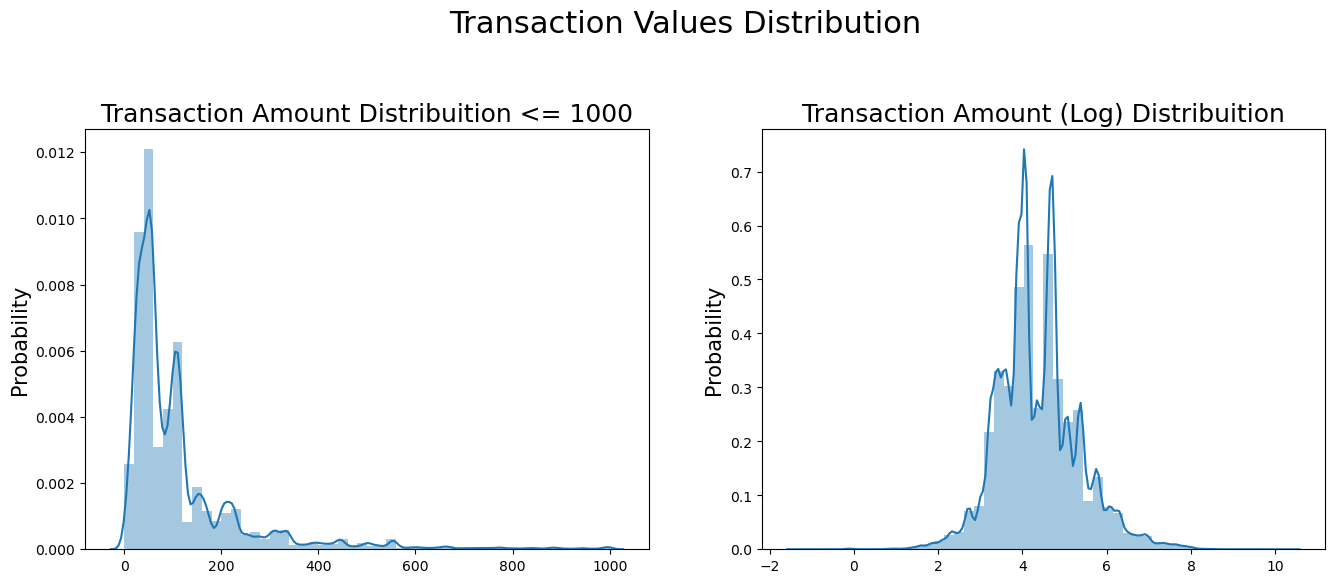

<Figure size 1600x1200 with 0 Axes>

In [23]:
plt.figure(figsize=(16,12))
plt.suptitle('Transaction Values Distribution', fontsize=22)
plt.subplot(221)
g = sns.distplot(df_trans[df_trans['TransactionAmt'] <= 1000]['TransactionAmt'])
g.set_title("Transaction Amount Distribuition <= 1000", fontsize=18)
g.set_xlabel("")
g.set_ylabel("Probability", fontsize=15)

plt.subplot(222)
g1 = sns.distplot(np.log(df_trans['TransactionAmt']))
g1.set_title("Transaction Amount (Log) Distribuition", fontsize=18)
g1.set_xlabel("")
g1.set_ylabel("Probability", fontsize=15)

plt.figure(figsize=(16,12))
plt.show()


**Transaction Amount Outliers**

In [24]:
CalcOutliers(df_trans['TransactionAmt'])

Identified lowest outliers: 0
Identified upper outliers: 10097
Total outlier observations: 10097
Non-outlier observations: 580443
Total percentual of Outliers:  1.7395


From this, we can say that we have 10k rows with outliers that represents 1.7395% of total rows.

##### Product Features
- Distribution of products
- Distribution of Frauds by Product

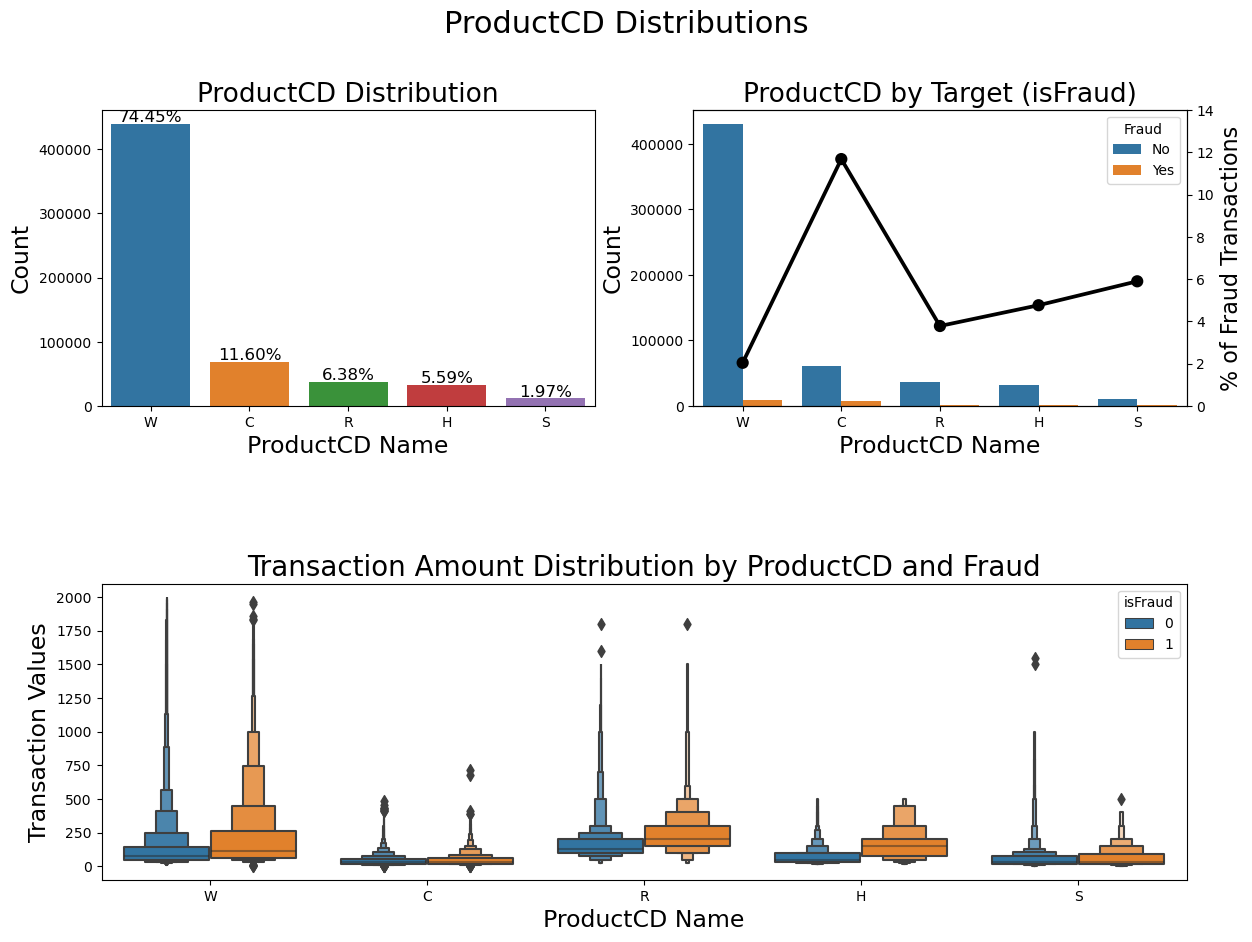

In [25]:
tmp = pd.crosstab(df_trans['ProductCD'], df_trans['isFraud'], normalize='index') * 100
tmp = tmp.reset_index()
tmp.rename(columns={0: 'NoFraud', 1: 'Fraud'}, inplace=True)

total = len(df_trans)  # used for percentage labels

plt.figure(figsize=(14, 10))
plt.suptitle('ProductCD Distributions', fontsize=22)

# ---------- (1) ProductCD overall distribution ----------
plt.subplot(221)
g = sns.countplot(x='ProductCD', data=df_trans, order=df_trans['ProductCD'].value_counts().index)

g.set_title("ProductCD Distribution", fontsize=19)
g.set_xlabel("ProductCD Name", fontsize=17)
g.set_ylabel("Count", fontsize=17)

for p in g.patches:
    height = p.get_height()
    g.text(p.get_x() + p.get_width()/2.,
           height + total*0.005,
           f'{height/total*100:.2f}%',
           ha="center", fontsize=12)

# ---------- (2) ProductCD by Fraud + Fraud Rate Line ----------
plt.subplot(222)
g1 = sns.countplot(x='ProductCD', hue='isFraud', data=df_trans,
                   order=df_trans['ProductCD'].value_counts().index)

g1.set_title("ProductCD by Target (isFraud)", fontsize=19)
g1.set_xlabel("ProductCD Name", fontsize=17)
g1.set_ylabel("Count", fontsize=17)
plt.legend(title='Fraud', labels=['No', 'Yes'])

# Fraud rate line (secondary axis)
gt = g1.twinx()
sns.pointplot(x='ProductCD', y='Fraud', data=tmp,
              order=df_trans['ProductCD'].value_counts().index,
              color='black')
gt.set_ylabel("% of Fraud Transactions", fontsize=16)
gt.set_ylim(0, tmp['Fraud'].max() * 1.2)

# ---------- (3) Transaction Amount Distribution ----------
plt.subplot(212)
g3 = sns.boxenplot(x='ProductCD', y='TransactionAmt', hue='isFraud',
                   data=df_trans[df_trans['TransactionAmt'] <= 2000],
                   order=df_trans['ProductCD'].value_counts().index)

g3.set_title("Transaction Amount Distribution by ProductCD and Fraud", fontsize=20)
g3.set_xlabel("ProductCD Name", fontsize=17)
g3.set_ylabel("Transaction Values", fontsize=17)

plt.subplots_adjust(hspace=0.6, top=0.88)
plt.show()

- W,C and R are the most frequent values.
- W,H and R the distribution of fraud values are slightly higher than the Non-Fraud Transactions.

##### Card Features
- Card features are categoricals.
- Card features has 6 columns and 4 of them seems to be numericals, so lets see the quantiles and distributions.

Card-related variables may capture:
- Issuer patterns  
- Card type risk differences  
- Fraud concentration in certain card segments

In [26]:
from scipy import stats
resumetable(df_trans[['card1', 'card2', 'card3','card4', 'card5', 'card6']])

Dataset Shape: (590540, 6)


,Name,dtypes,Missing,Uniques,First Value,Second Value,Third Value,Entropy
0,card1,int16,0,13553,13926,2755,4663,9.97
1,card2,float16,8933,500,NaN,404.0,490.0,6.32
2,card3,float16,1565,114,150.0,150.0,150.0,0.68
3,card4,object,1577,4,discover,mastercard,visa,1.09
4,card5,float16,4259,119,142.0,102.0,166.0,2.66
5,card6,object,1571,4,credit,credit,debit,0.82


- Card2-Card6 has some missing values. We will need to due with it later.

**Numericals Features Card Quantiles**

In [27]:
print("Card Features Quantiles: ")
print(df_trans[['card1', 'card2', 'card3', 'card5']].quantile([0.01, .025, .1, .25, .5, .75, .975, .99]))

Card Features Quantiles: 
         card1  card2  card3  card5
0.010   1338.0  100.0  144.0  102.0
0.025   1675.0  111.0  150.0  102.0
0.100   2803.0  111.0  150.0  126.0
0.250   6019.0  214.0  150.0  166.0
0.500   9678.0  361.0  150.0  226.0
0.750  14184.0  512.0  150.0  226.0
0.975  18018.0  583.0  185.0  226.0
0.990  18238.0  583.0  185.0  226.0


- We can see that Card 1 and Card 2 has a large distribution of values, so maybe it will be beteer to get the log of these columns

In [28]:
df_trans.loc[df_trans.card3.isin(df_trans.card3.value_counts()[df_trans.card3.value_counts() < 200].index), 'card3'] = "Others"
df_trans.loc[df_trans.card5.isin(df_trans.card5.value_counts()[df_trans.card5.value_counts() < 300].index), 'card5'] = "Others"

**Visualizing Card1, Card2 and Card 3 Distributions**
- As the Card 1 and 2 are numericals, we will plot the distribution of them
- in Card 3, as we have many values with low frequencies, we decided to set value to "Others"
- Also, in Card 3 we set the % of Fraud ratio in yaxis2

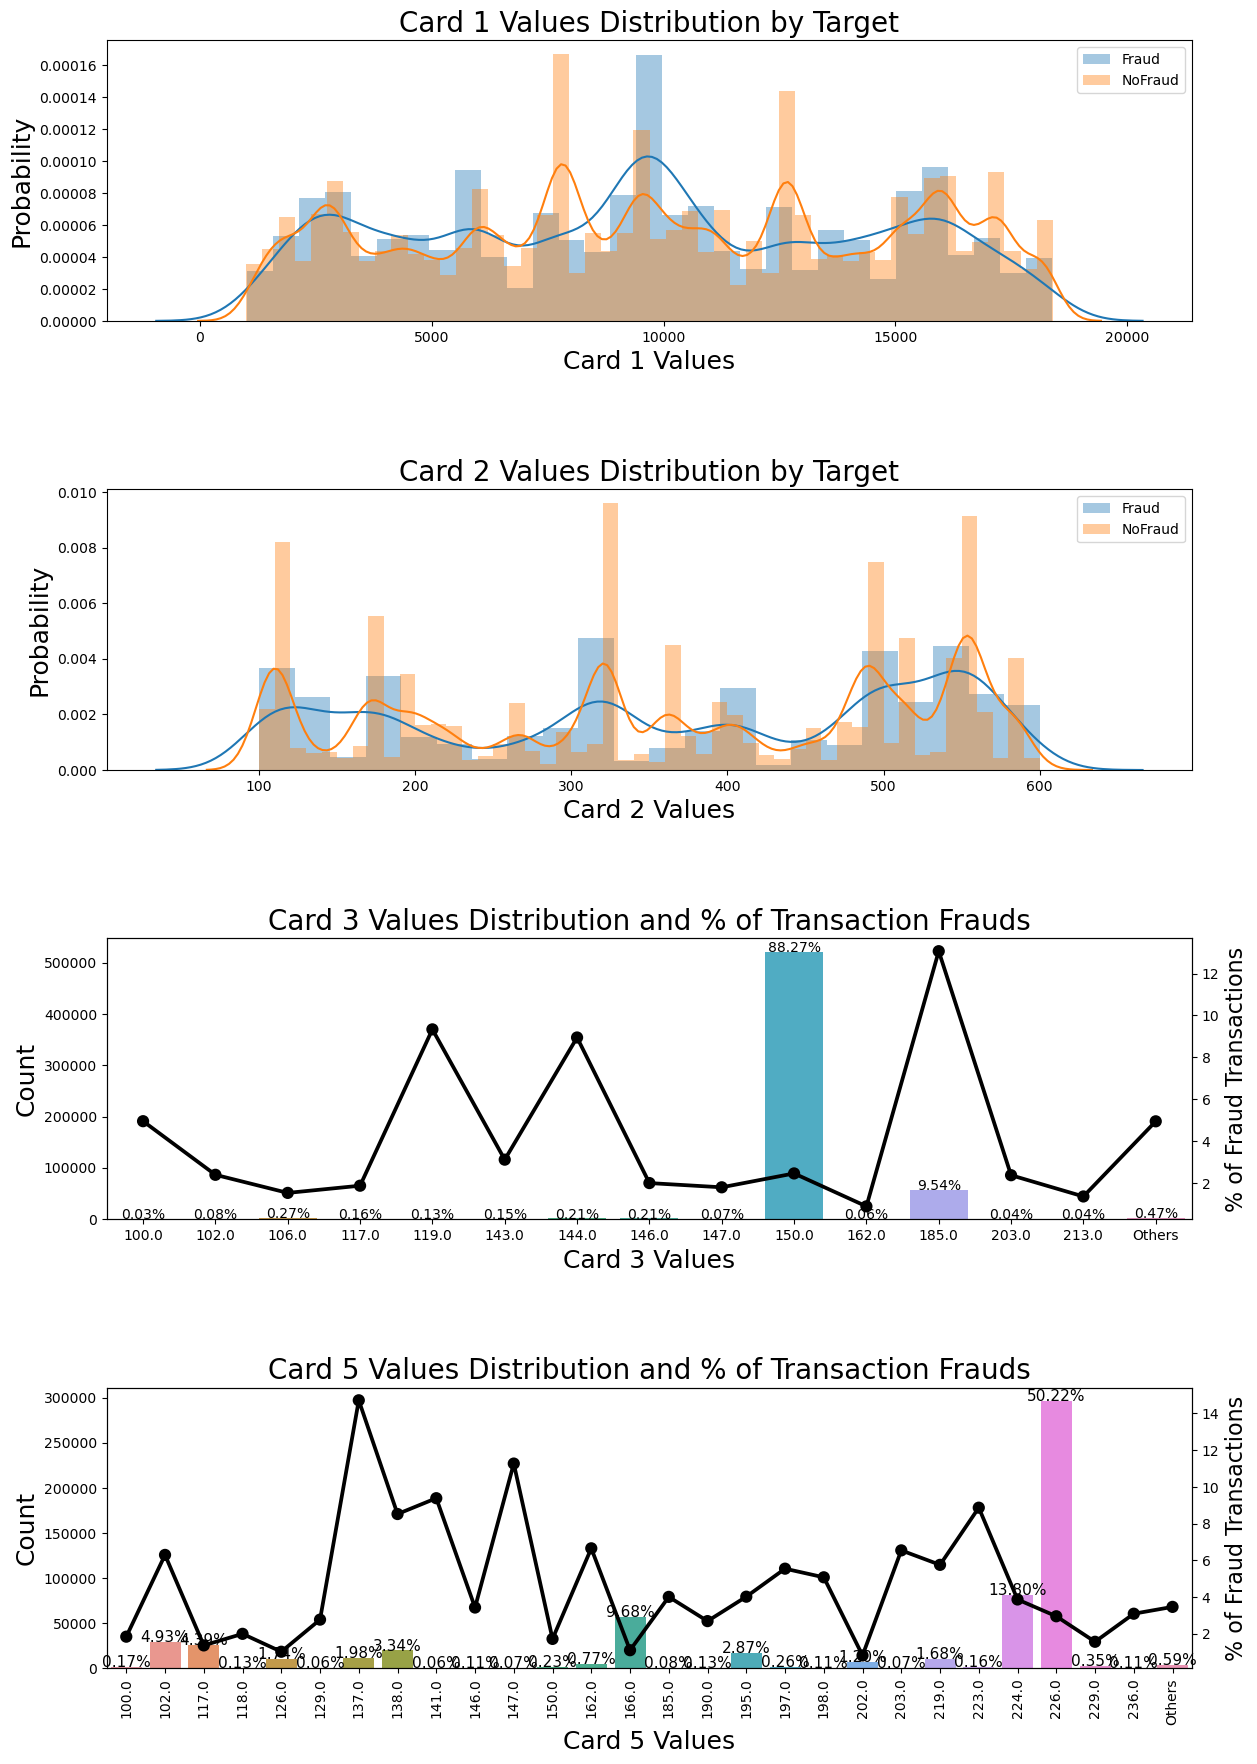

In [29]:
tmp = pd.crosstab(df_trans['card3'], df_trans['isFraud'], normalize='index') * 100
tmp = tmp.reset_index()
tmp.rename(columns={0:'NoFraud', 1:'Fraud'}, inplace=True)

tmp2 = pd.crosstab(df_trans['card5'], df_trans['isFraud'], normalize='index') * 100
tmp2 = tmp2.reset_index()
tmp2.rename(columns={0:'NoFraud', 1:'Fraud'}, inplace=True)

plt.figure(figsize=(14,22))

plt.subplot(411)
g = sns.distplot(df_trans[df_trans['isFraud'] == 1]['card1'], label='Fraud')
g = sns.distplot(df_trans[df_trans['isFraud'] == 0]['card1'], label='NoFraud')
g.legend()
g.set_title("Card 1 Values Distribution by Target", fontsize=20)
g.set_xlabel("Card 1 Values", fontsize=18)
g.set_ylabel("Probability", fontsize=18)

plt.subplot(412)
g1 = sns.distplot(df_trans[df_trans['isFraud'] == 1]['card2'].dropna(), label='Fraud')
g1 = sns.distplot(df_trans[df_trans['isFraud'] == 0]['card2'].dropna(), label='NoFraud')
g1.legend()
g1.set_title("Card 2 Values Distribution by Target", fontsize=20)
g1.set_xlabel("Card 2 Values", fontsize=18)
g1.set_ylabel("Probability", fontsize=18)

plt.subplot(413)
g2 = sns.countplot(x='card3', data=df_trans, order=list(tmp.card3.values))
g22 = g2.twinx()
gg2 = sns.pointplot(x='card3', y='Fraud', data=tmp, 
                    color='black', order=list(tmp.card3.values))
gg2.set_ylabel("% of Fraud Transactions", fontsize=16)
g2.set_title("Card 3 Values Distribution and % of Transaction Frauds", fontsize=20)
g2.set_xlabel("Card 3 Values", fontsize=18)
g2.set_ylabel("Count", fontsize=18)
for p in g2.patches:
    height = p.get_height()
    g2.text(p.get_x()+p.get_width()/2.,
            height + 25,
            '{:1.2f}%'.format(height/total*100),
            ha="center") 

plt.subplot(414)
g3 = sns.countplot(x='card5', data=df_trans, order=list(tmp2.card5.values))
g3t = g3.twinx()
g3t = sns.pointplot(x='card5', y='Fraud', data=tmp2, 
                    color='black', order=list(tmp2.card5.values))
g3t.set_ylabel("% of Fraud Transactions", fontsize=16)
g3.set_title("Card 5 Values Distribution and % of Transaction Frauds", fontsize=20)
g3.set_xticklabels(g3.get_xticklabels(),rotation=90)
g3.set_xlabel("Card 5 Values", fontsize=18)
g3.set_ylabel("Count", fontsize=18)
for p in g3.patches:
    height = p.get_height()
    g3.text(p.get_x()+p.get_width()/2.,
            height + 3,
            '{:1.2f}%'.format(height/total*100),
            ha="center",fontsize=11) 
    
plt.subplots_adjust(hspace = 0.6, top = 0.85)


plt.show()

- In card3, we can see that 100 and 106 are the most common values in the columns.
- We have 4.95% of Frauds in 100 and 1.52% in 106; The values with highest Fraud Transactions are 185, 119 and 119.

- In card5 the most frequent values are 226, 224, 166 that represents 73% of data. Also is posible to see high % of frauds in 137, 147, 141 that has few entries for values.

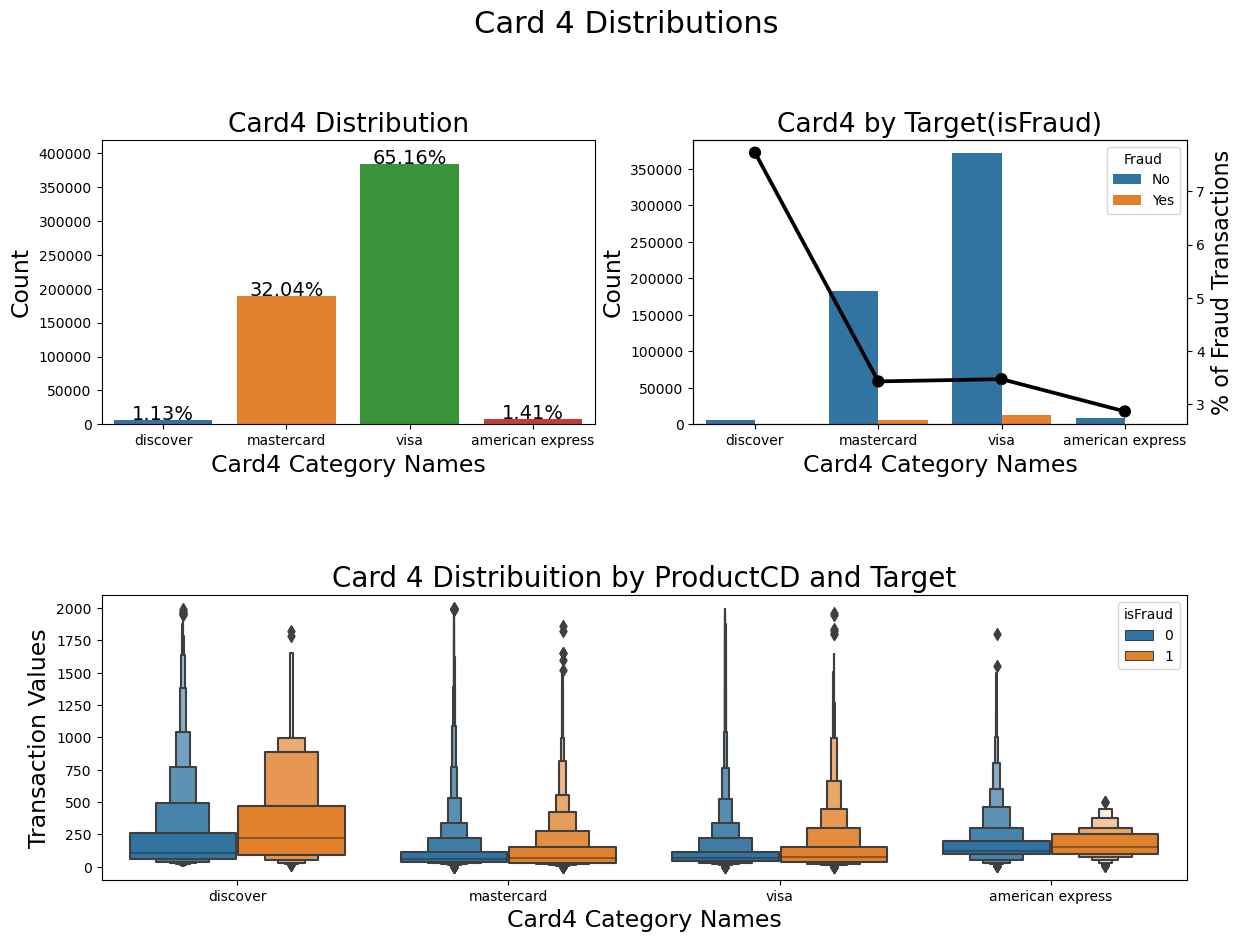

In [30]:
# Categorical 
tmp = pd.crosstab(df_trans['card4'], df_trans['isFraud'], normalize='index') * 100
tmp = tmp.reset_index()
tmp.rename(columns={0:'NoFraud', 1:'Fraud'}, inplace=True)

plt.figure(figsize=(14,10))
plt.suptitle('Card 4 Distributions', fontsize=22)

plt.subplot(221)
g = sns.countplot(x='card4', data=df_trans)
# plt.legend(title='Fraud', loc='upper center', labels=['No', 'Yes'])
g.set_title("Card4 Distribution", fontsize=19)
g.set_ylim(0,420000)
g.set_xlabel("Card4 Category Names", fontsize=17)
g.set_ylabel("Count", fontsize=17)
for p in g.patches:
    height = p.get_height()
    g.text(p.get_x()+p.get_width()/2.,
            height + 3,
            '{:1.2f}%'.format(height/total*100),
            ha="center",fontsize=14) 


plt.subplot(222)
g1 = sns.countplot(x='card4', hue='isFraud', data=df_trans)
plt.legend(title='Fraud', loc='best', labels=['No', 'Yes'])
gt = g1.twinx()
gt = sns.pointplot(x='card4', y='Fraud', data=tmp, 
                   color='black',  
                   order=['discover', 'mastercard', 'visa', 'american express'])
gt.set_ylabel("% of Fraud Transactions", fontsize=16)
g1.set_title("Card4 by Target(isFraud)", fontsize=19)
g1.set_xlabel("Card4 Category Names", fontsize=17)
g1.set_ylabel("Count", fontsize=17)

plt.subplot(212)
g3 = sns.boxenplot(x='card4', y='TransactionAmt', hue='isFraud', 
              data=df_trans[df_trans['TransactionAmt'] <= 2000] )
g3.set_title("Card 4 Distribuition by ProductCD and Target", fontsize=20)
g3.set_xlabel("Card4 Category Names", fontsize=17)
g3.set_ylabel("Transaction Values", fontsize=17)

plt.subplots_adjust(hspace = 0.6, top = 0.85)

plt.show()

- We can see that 97% of our data are in Mastercard(32%) and Visa(65%);we have a highest value in discover(~8%) against ~3.5% of Mastercard and Visa and 2.87% in American Express

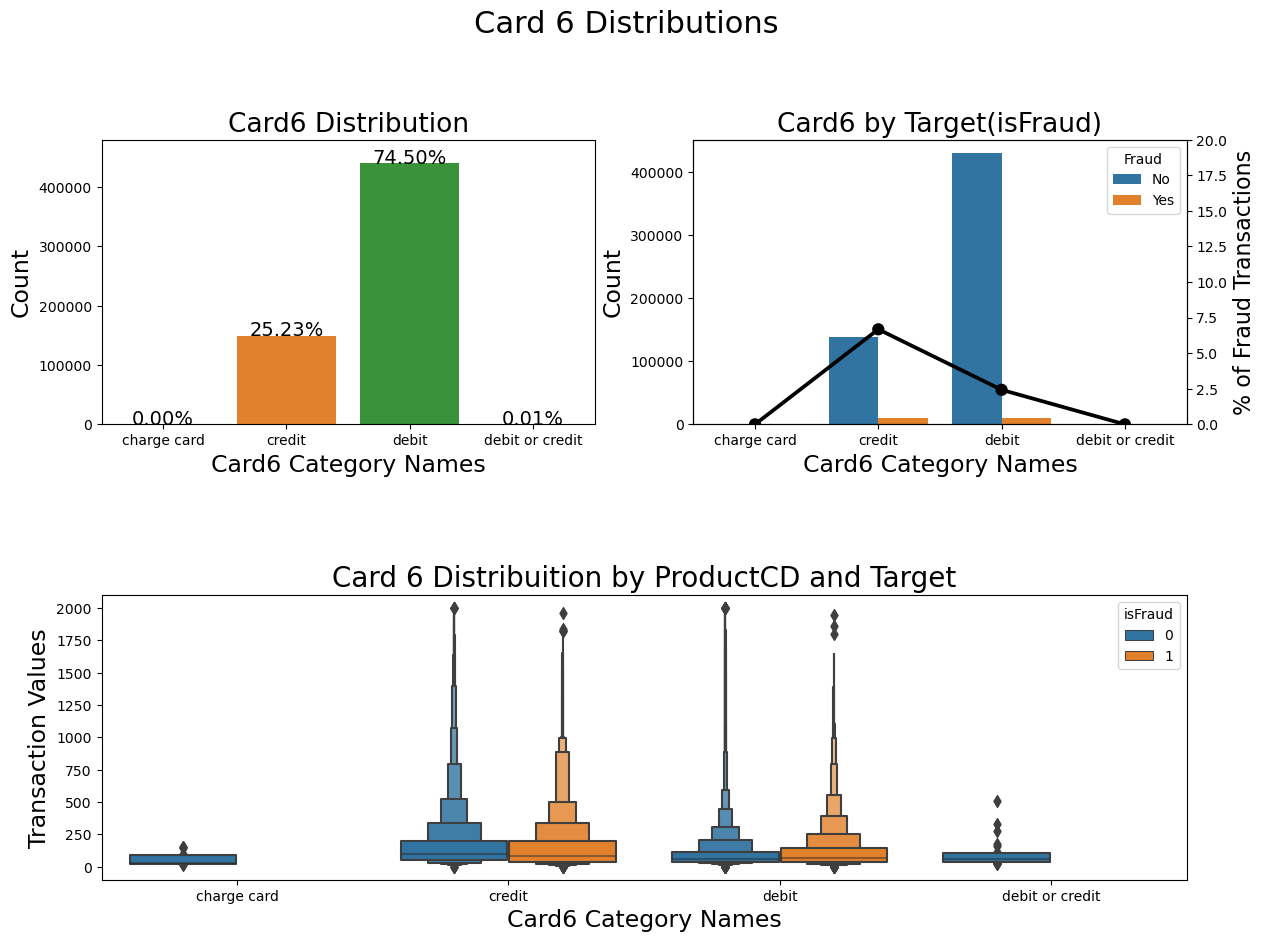

In [93]:
tmp = pd.crosstab(df_trans['card6'], df_trans['isFraud'], normalize='index') * 100
tmp = tmp.reset_index()
tmp.rename(columns={0:'NoFraud', 1:'Fraud'}, inplace=True)

plt.figure(figsize=(14,10))
plt.suptitle('Card 6 Distributions', fontsize=22)

plt.subplot(221)
g = sns.countplot(x='card6', data=df_trans, order=list(tmp.card6.values))
# plt.legend(title='Fraud', loc='upper center', labels=['No', 'Yes'])
g.set_title("Card6 Distribution", fontsize=19)
g.set_ylim(0,480000)
g.set_xlabel("Card6 Category Names", fontsize=17)
g.set_ylabel("Count", fontsize=17)
for p in g.patches:
    height = p.get_height()
    g.text(p.get_x()+p.get_width()/2.,
            height + 3,
            '{:1.2f}%'.format(height/total*100),
            ha="center",fontsize=14) 

plt.subplot(222)
g1 = sns.countplot(x='card6', hue='isFraud', data=df_trans, order=list(tmp.card6.values))
plt.legend(title='Fraud', loc='best', labels=['No', 'Yes'])
gt = g1.twinx()
gt = sns.pointplot(x='card6', y='Fraud', data=tmp, order=list(tmp.card6.values),
                   color='black')
gt.set_ylim(0,20)
gt.set_ylabel("% of Fraud Transactions", fontsize=16)
g1.set_title("Card6 by Target(isFraud)", fontsize=19)
g1.set_xlabel("Card6 Category Names", fontsize=17)
g1.set_ylabel("Count", fontsize=17)

plt.subplot(212)
g3 = sns.boxenplot(x='card6', y='TransactionAmt', hue='isFraud', order=list(tmp.card6.values),
              data=df_trans[df_trans['TransactionAmt'] <= 2000] )
g3.set_title("Card 6 Distribuition by ProductCD and Target", fontsize=20)
g3.set_xlabel("Card6 Category Names", fontsize=17)
g3.set_ylabel("Transaction Values", fontsize=17)

plt.subplots_adjust(hspace = 0.6, top = 0.85)

plt.show()

- All data is on Credit and Debit. We can see a high percentual of Frauds in Credit than Debit transactions.
- The Distribution of Transaction Amount don't shows clear differences.

##### Exploring M1-M9 Features

In [32]:
# Fill missing M values
for col in ['M1','M2','M3','M4','M5','M6','M7','M8','M9']:
    df_trans[col] = df_trans[col].fillna("Miss")

def ploting_dist_ratio(df, col, lim=2000):

    total = len(df)
    total_amt = df['TransactionAmt'].sum()

    tmp = pd.crosstab(df[col], df['isFraud'], normalize='index') * 100
    tmp = tmp.reset_index()
    tmp.rename(columns={0:'NoFraud', 1:'Fraud'}, inplace=True)

    order = list(tmp[col].values)

    plt.figure(figsize=(20,5))
    plt.suptitle(f'{col} Distributions', fontsize=22)

    # ---------------- Count + Fraud Rate ----------------
    plt.subplot(121)
    g = sns.countplot(x=col, data=df, order=order)
    g.set_title(f"{col} Distribution\nCount and % Fraud", fontsize=18)
    g.set_xlabel(f"{col} Category Names", fontsize=16)
    g.set_ylabel("Count", fontsize=17)

    # Fraud rate line
    gt = g.twinx()
    sns.pointplot(x=col, y='Fraud', data=tmp, order=order, color='black')
    gt.set_ylabel("% of Fraud Transactions", fontsize=16)
    gt.set_ylim(0, tmp['Fraud'].max()*1.2)

    # Count % labels
    for p in g.patches:
        height = p.get_height()
        g.text(p.get_x()+p.get_width()/2.,
               height + total*0.002,
               f'{height/total*100:.2f}%',
               ha="center", fontsize=11)

    # ---------------- Amount Distribution + Fraud Amount Share ----------------
    perc_amt = (
        df.groupby(['isFraud', col])['TransactionAmt'].sum()
        .div(total_amt)
        .mul(100)
        .unstack('isFraud')
        .reset_index()
        .rename(columns={0:'NoFraud', 1:'Fraud'})
    )

    plt.subplot(122)
    g1 = sns.boxplot(x=col, y='TransactionAmt', hue='isFraud',
                     data=df[df['TransactionAmt'] <= lim],
                     order=order)

    g1.set_title(f"{col} Transaction Amount Distribution", fontsize=18)
    g1.set_xlabel(f"{col} Category Names", fontsize=16)
    g1.set_ylabel("Transaction Amount ($)", fontsize=16)

    # Fraud amount % line
    g1t = g1.twinx()
    sns.pointplot(x=col, y='Fraud', data=perc_amt, order=order, color='black')
    g1t.set_ylabel("% of Total Fraud Amount", fontsize=16)
    g1t.set_ylim(0, perc_amt['Fraud'].max()*1.2)

    plt.subplots_adjust(hspace=.4, wspace=0.35, top=0.80)
    plt.show()

**M distribution: Count %Fraud and Transaction Amount Distribution**

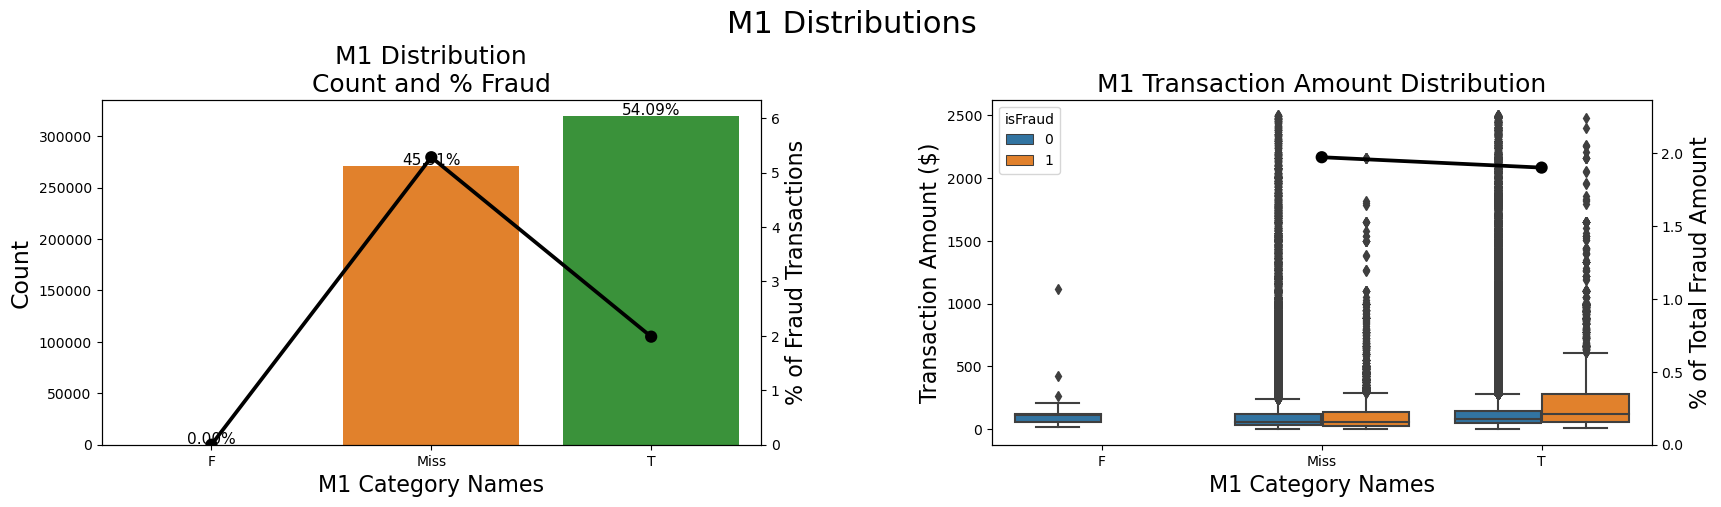

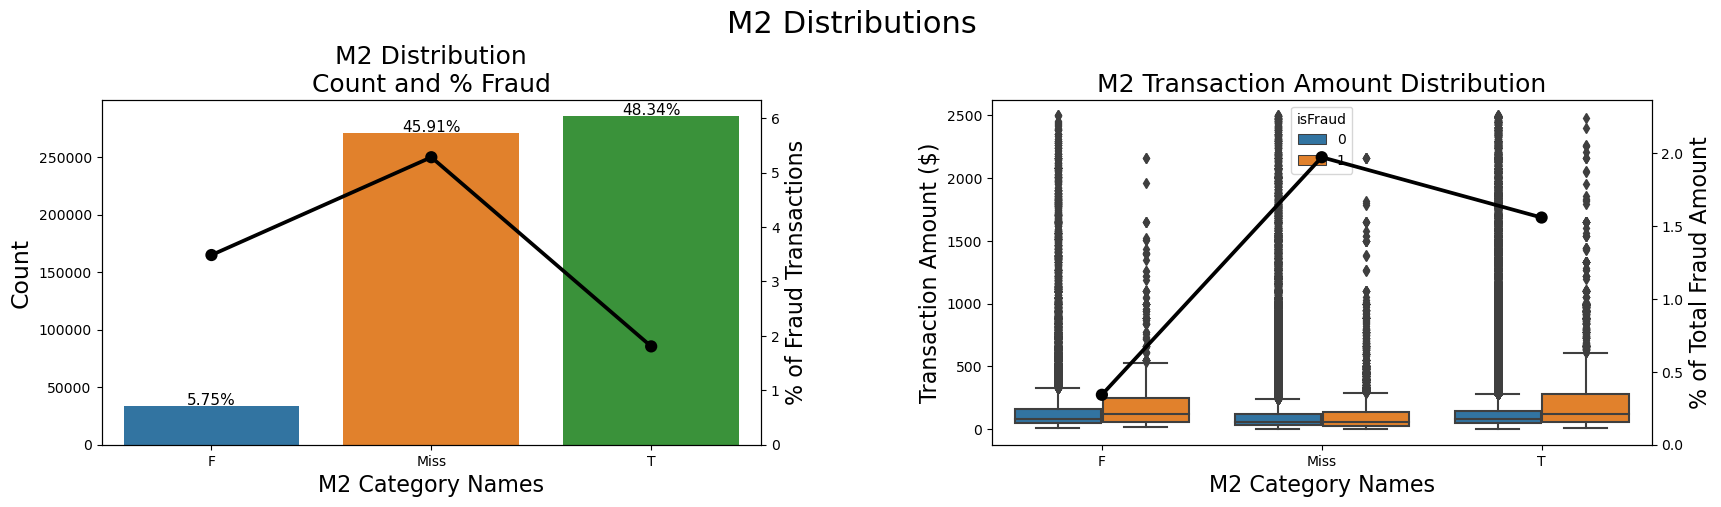

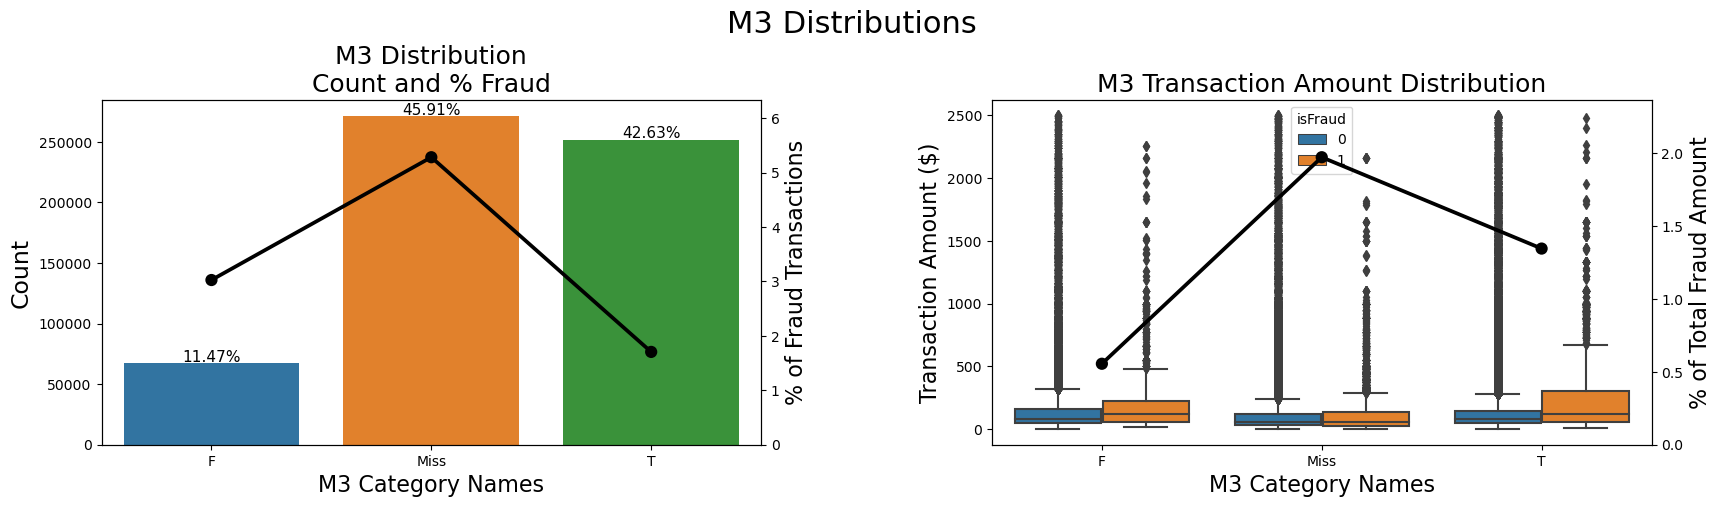

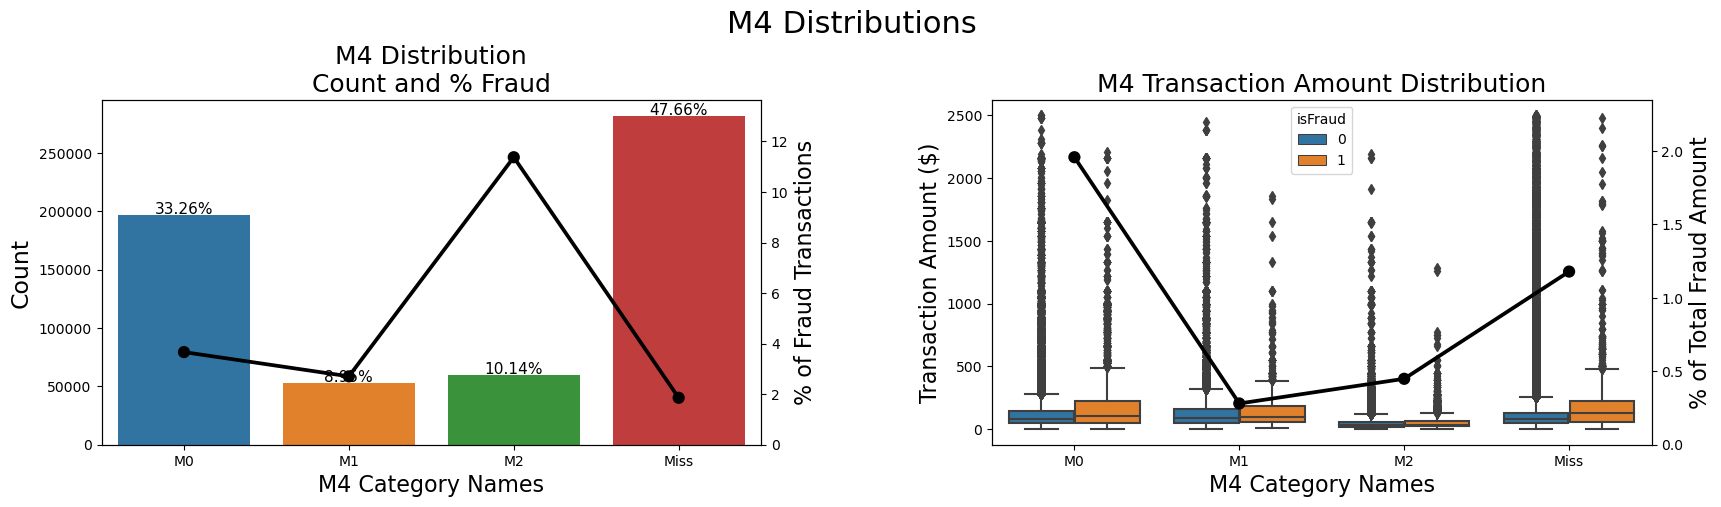

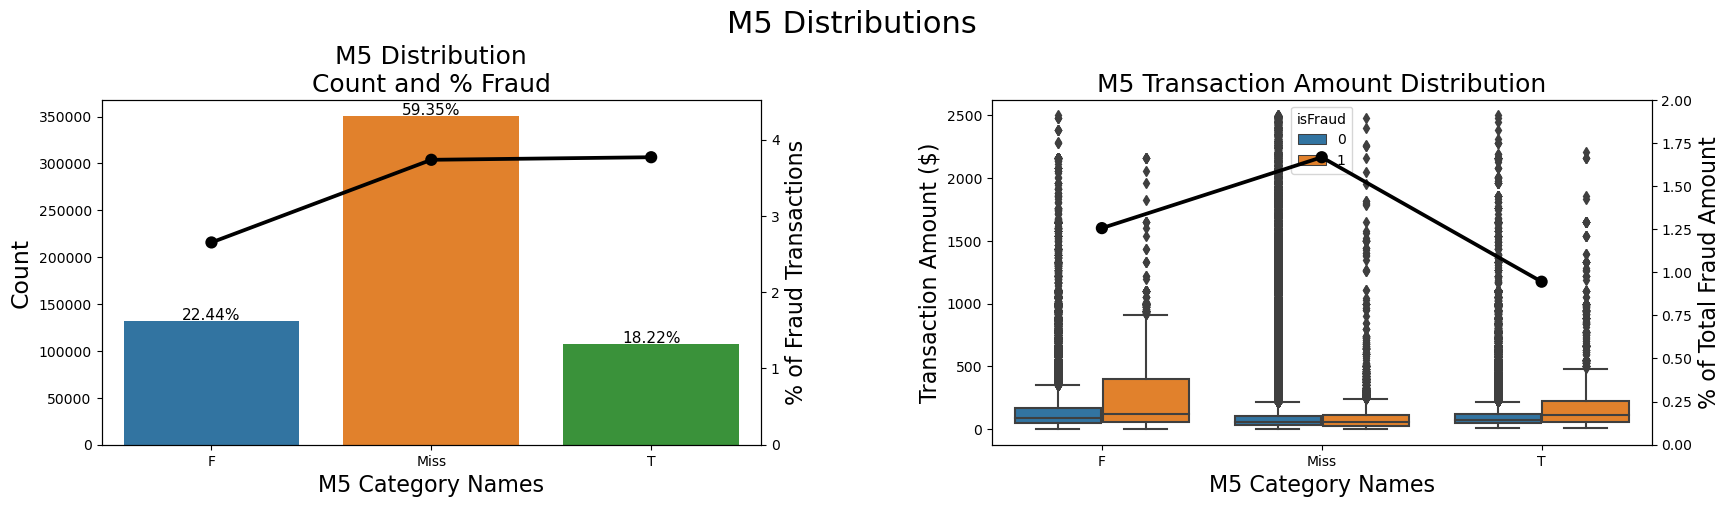

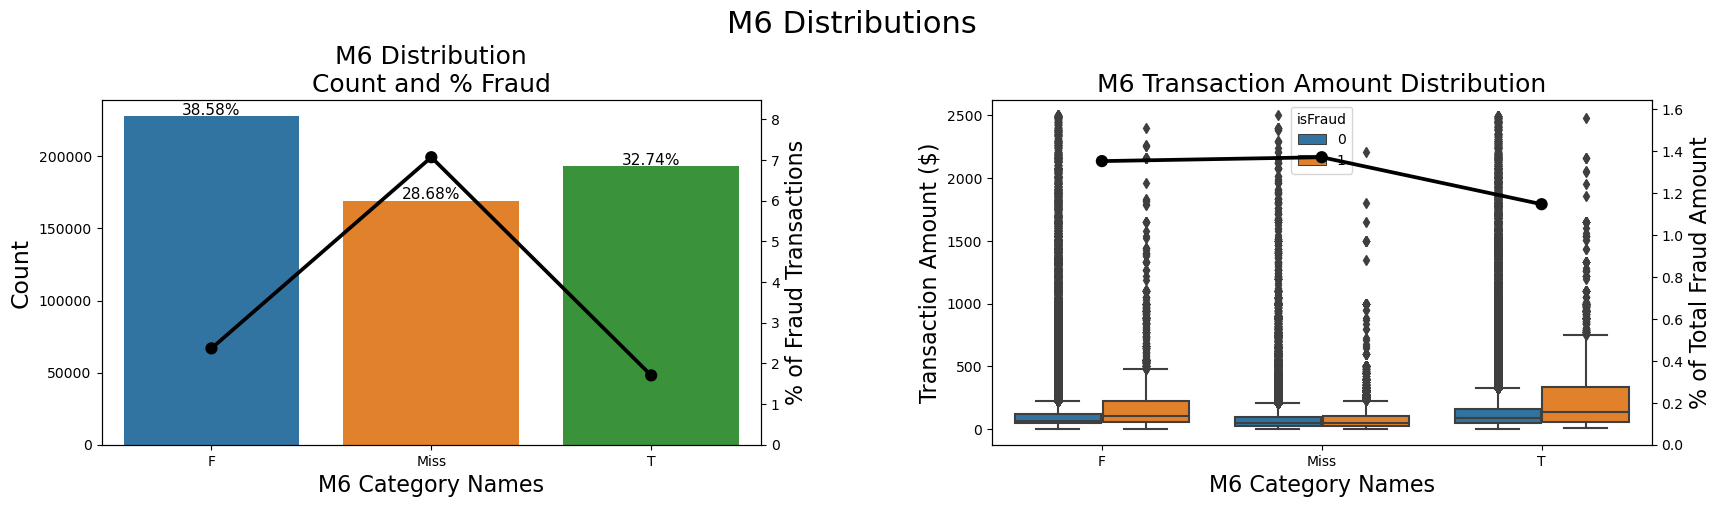

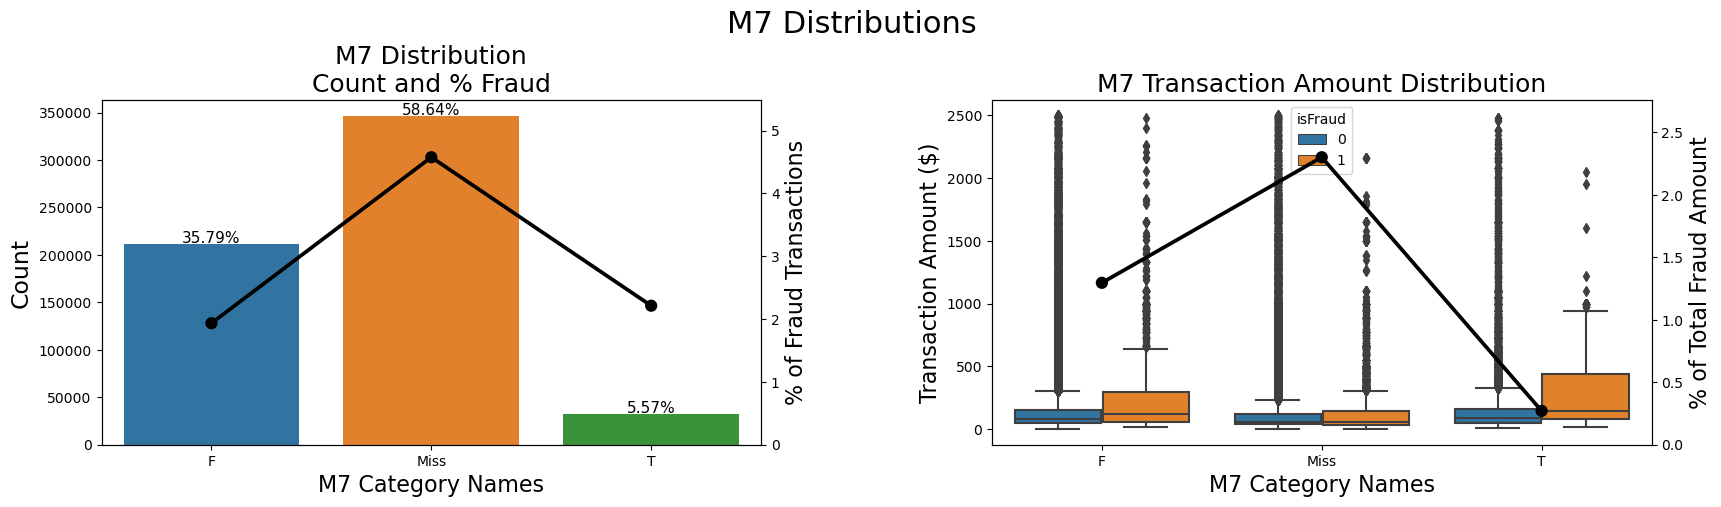

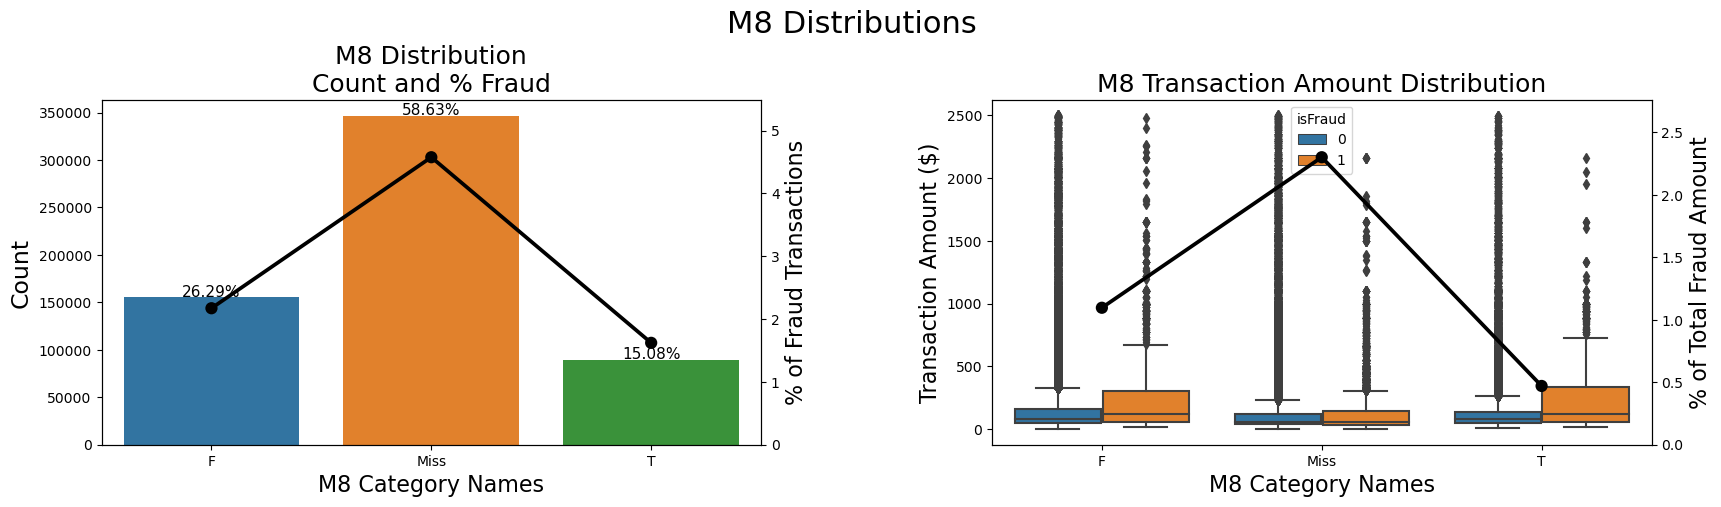

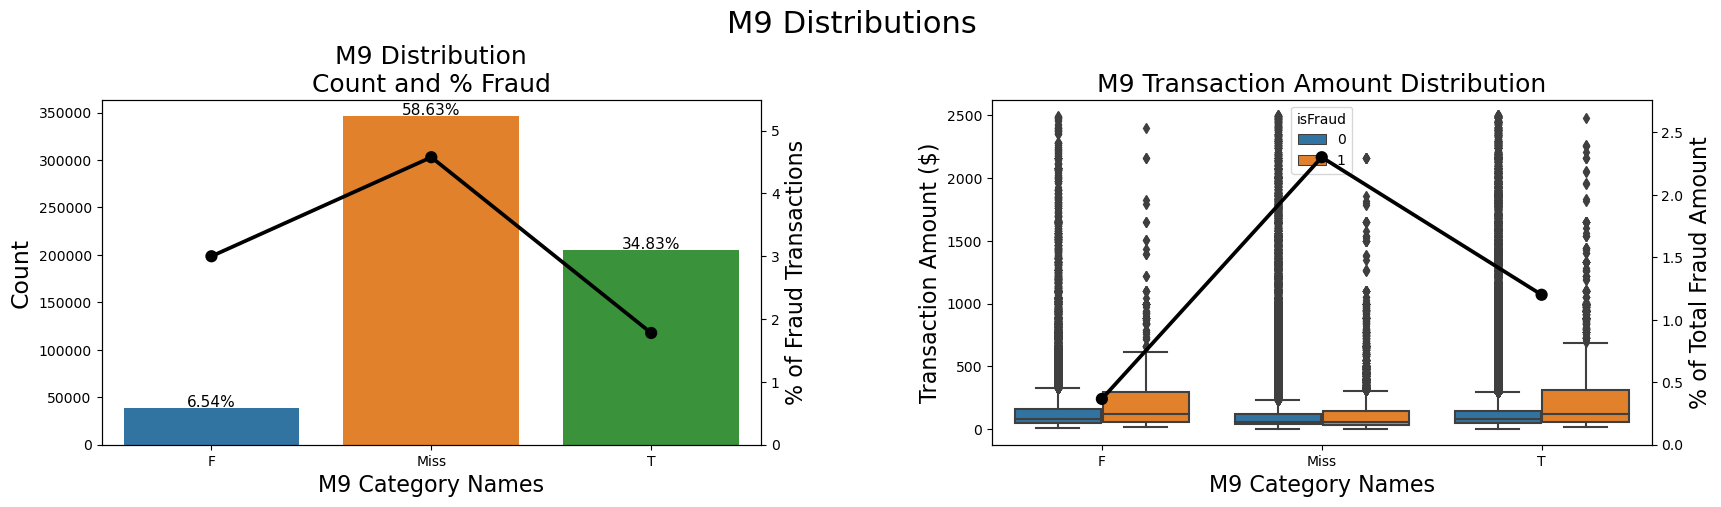

In [33]:
for col in ['M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9']:
    ploting_dist_ratio(df_trans, col, lim=2500)


##### Addr1 and Addr2

In [34]:
print("Card Features Quantiles: ")
print(df_trans[['addr1', 'addr2']].quantile([0.01, .025, .1, .25, .5, .75, .90,.975, .99]))

Card Features Quantiles: 
       addr1  addr2
0.010  123.0   87.0
0.025  123.0   87.0
0.100  177.0   87.0
0.250  204.0   87.0
0.500  299.0   87.0
0.750  330.0   87.0
0.900  441.0   87.0
0.975  498.0   87.0
0.990  512.0   87.0


In [35]:
df_trans.loc[df_trans.addr1.isin(df_trans.addr1.value_counts()[df_trans.addr1.value_counts() <= 5000 ].index), 'addr1'] = "Others"
df_trans.loc[df_trans.addr2.isin(df_trans.addr2.value_counts()[df_trans.addr2.value_counts() <= 50 ].index), 'addr2'] = "Others"

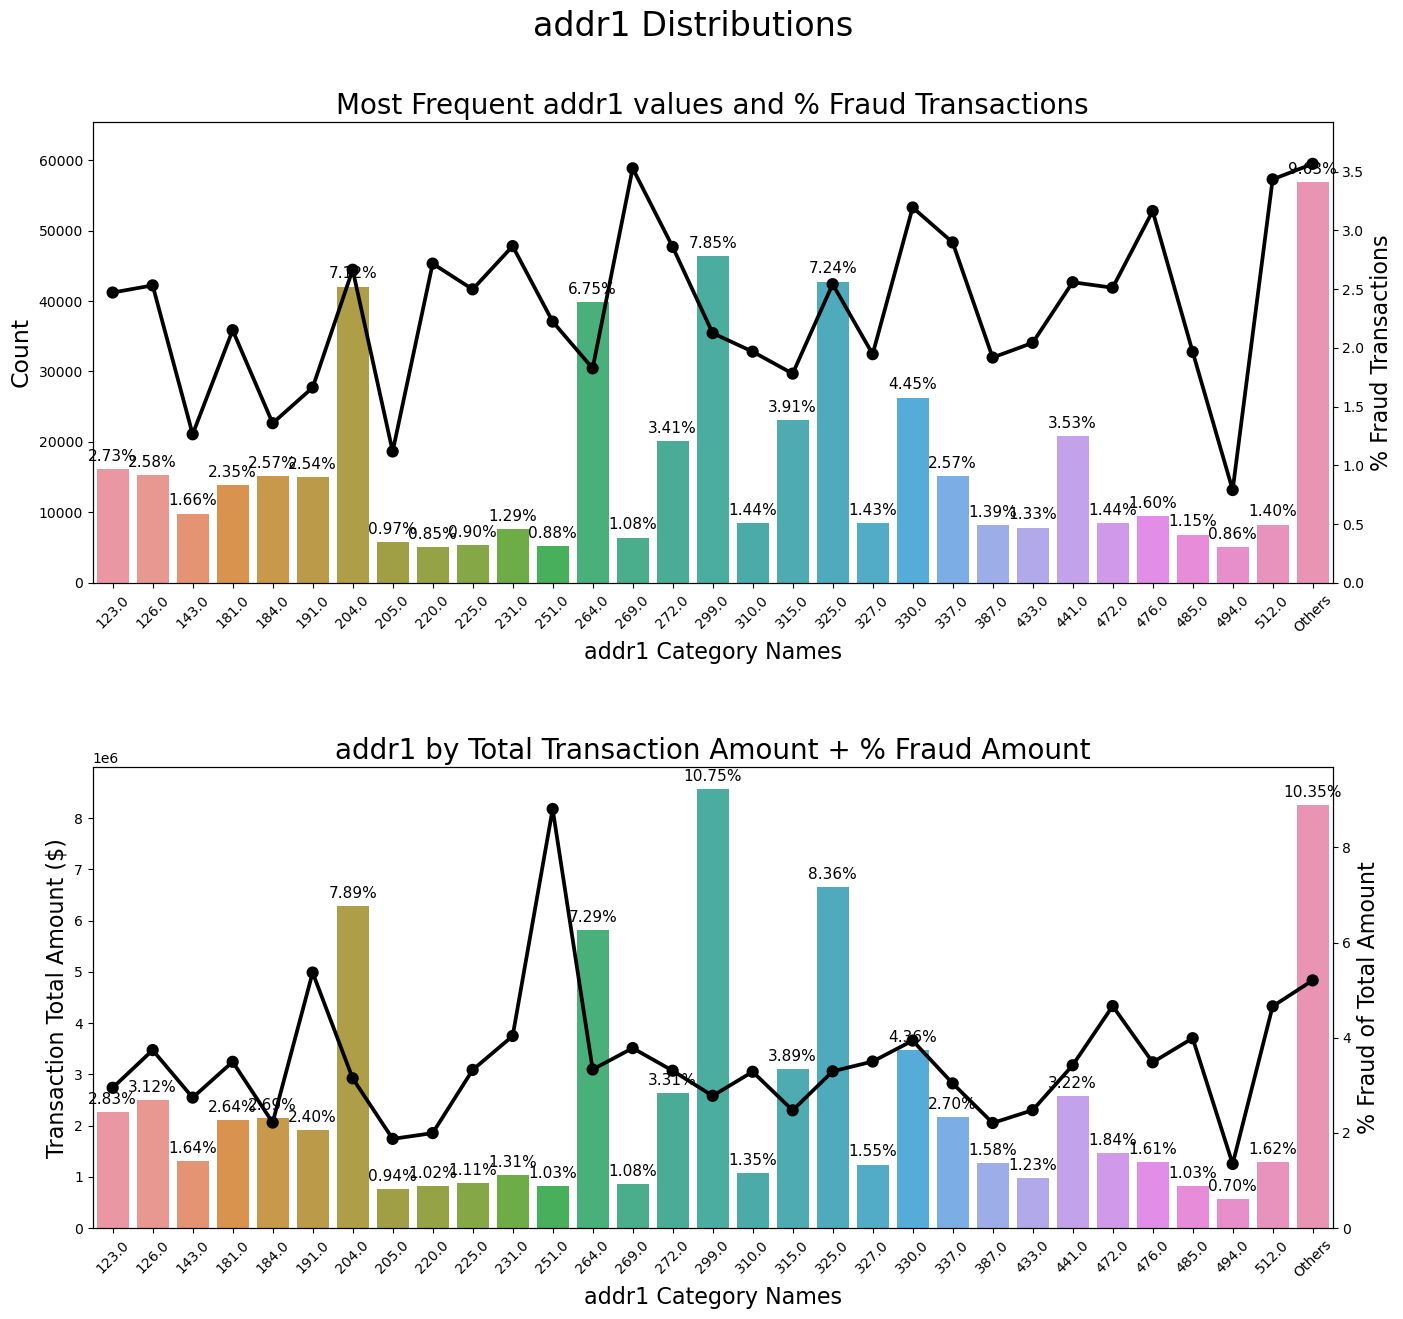

In [36]:
def ploting_cnt_amt(df, col, lim=2000):
    if df[col].dtype == 'float16':
        df[col] = df[col].astype('float32')

    total = len(df)
    total_amt = df['TransactionAmt'].sum()

    tmp = pd.crosstab(df[col], df['isFraud'], normalize='index') * 100
    tmp = tmp.reset_index()
    tmp.rename(columns={0:'NoFraud', 1:'Fraud'}, inplace=True)
    
    order = list(tmp[col].values)
    
    plt.figure(figsize=(16,14))    
    plt.suptitle(f'{col} Distributions', fontsize=24)
    
    # ---------------- Count + Fraud Rate ----------------
    plt.subplot(211)
    g = sns.countplot(x=col, data=df, order=order)
    gt = g.twinx()
    sns.pointplot(x=col, y='Fraud', data=tmp, order=order, color='black')

    gt.set_ylim(0, tmp['Fraud'].max()*1.1)
    gt.set_ylabel("% Fraud Transactions", fontsize=16)
    g.set_title(f"Most Frequent {col} values and % Fraud Transactions", fontsize=20)
    g.set_xlabel(f"{col} Category Names", fontsize=16)
    g.set_ylabel("Count", fontsize=17)
    g.tick_params(axis='x', rotation=45)

    sizes = []
    for p in g.patches:
        height = p.get_height()
        sizes.append(height)
        g.text(p.get_x()+p.get_width()/2.,
               height + total*0.002,
               f'{height/total*100:.2f}%',
               ha="center", fontsize=11)
        
    g.set_ylim(0, max(sizes)*1.15)
    
    # ---------------- Total Amount + Fraud Amount % ----------------
    perc_amt = (
        df.groupby(['isFraud', col])['TransactionAmt'].sum()
        / df.groupby(col)['TransactionAmt'].sum() * 100
    ).unstack('isFraud').reset_index().fillna(0)

    perc_amt.rename(columns={0:'NoFraud', 1:'Fraud'}, inplace=True)
    amt = df.groupby(col)['TransactionAmt'].sum().reset_index()
    
    plt.subplot(212)
    g1 = sns.barplot(x=col, y='TransactionAmt', data=amt, order=order)
    g1t = g1.twinx()
    sns.pointplot(x=col, y='Fraud', data=perc_amt, order=order, color='black')

    g1t.set_ylim(0, perc_amt['Fraud'].max()*1.1)
    g1t.set_ylabel("% Fraud of Total Amount", fontsize=16)

    g1.set_title(f"{col} by Total Transaction Amount + % Fraud Amount", fontsize=20)
    g1.set_xlabel(f"{col} Category Names", fontsize=16)
    g1.set_ylabel("Transaction Total Amount ($)", fontsize=16)
    g1.tick_params(axis='x', rotation=45)

    for p in g1.patches:
        height = p.get_height()
        g1.text(p.get_x()+p.get_width()/2.,
                height + total_amt*0.002,
                f'{height/total_amt*100:.2f}%',
                ha="center", fontsize=11)
        
    plt.subplots_adjust(hspace=.4, top=0.9)
    plt.show()


# Run
ploting_cnt_amt(df_trans, 'addr1')


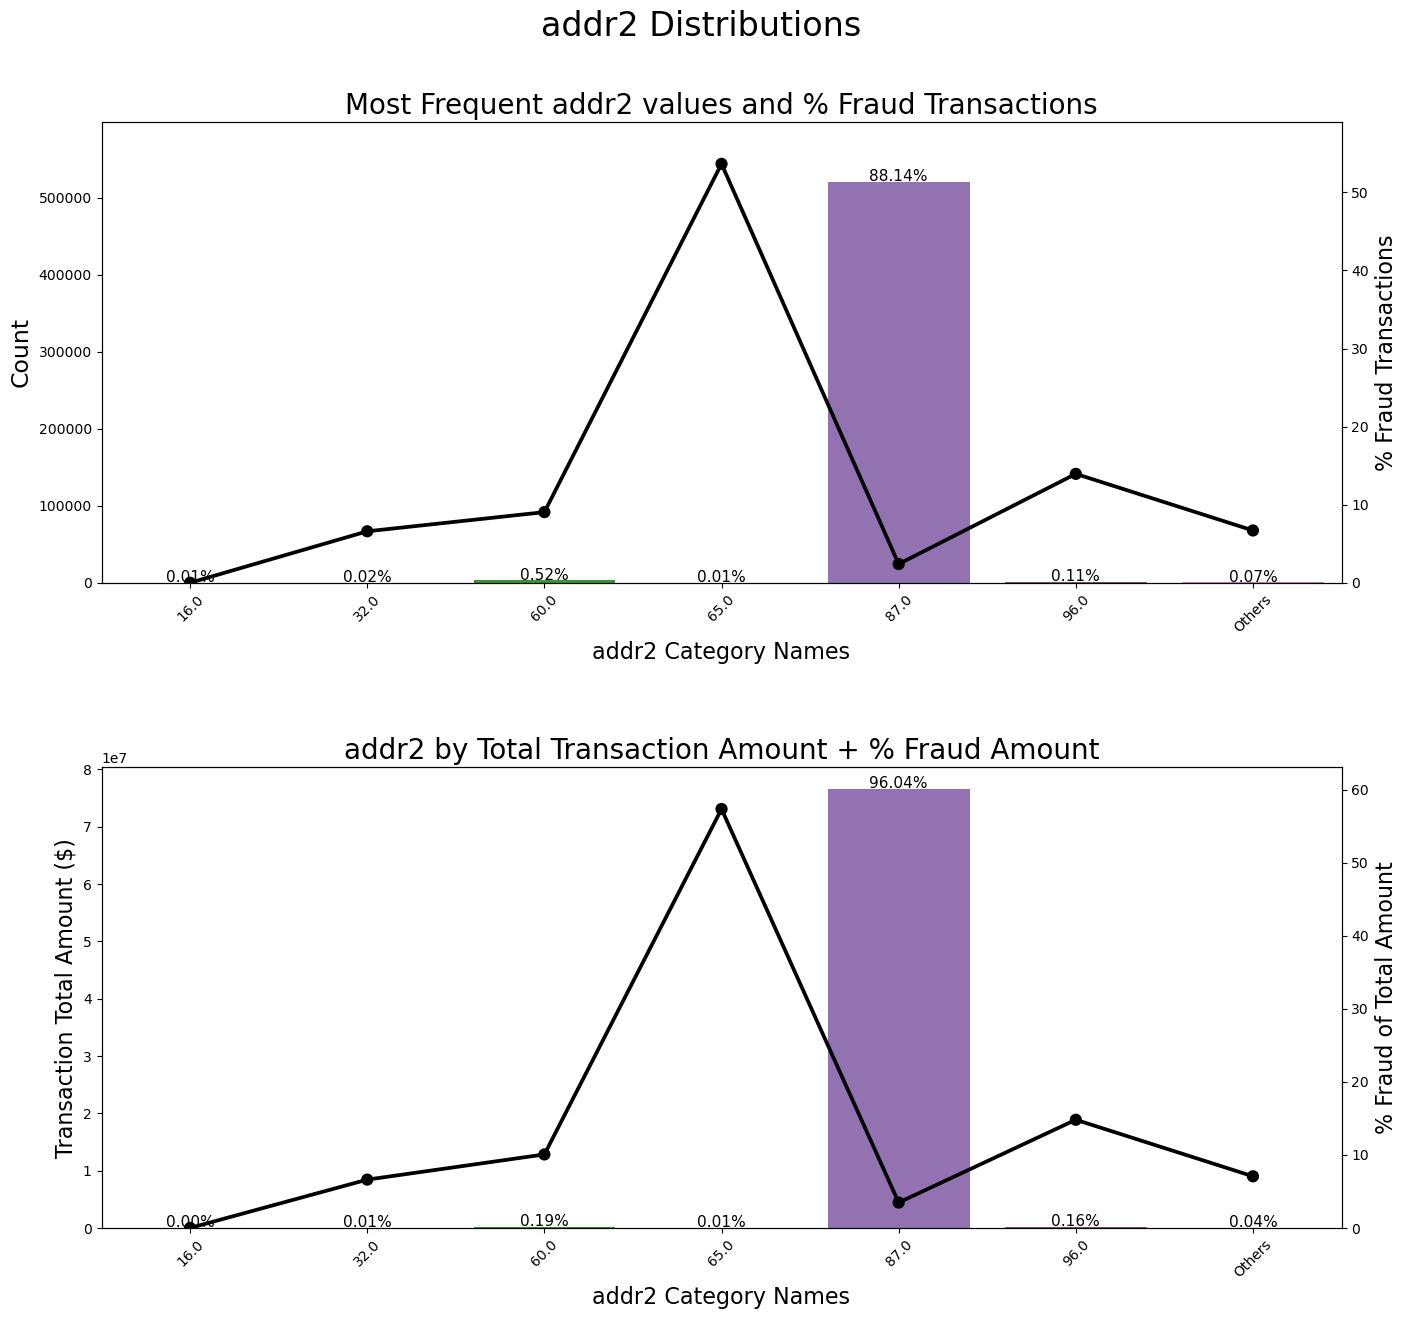

In [37]:
# Addr 2
ploting_cnt_amt(df_trans, 'addr2')

Almost all entries in Addr2 are in the same value.

Interestingly in the value 65 , the percent of frauds are almost 60%

Altought the value 87 has 88% of total entries, it has 96% of Total Transaction Amounts

##### P emaildomain Distributions
- We group all e-mail domains by the respective enterprises.Also, We will set as "Others" all values with less than 500 entries.

Fraudsters often use certain email providers or disposable domains.

We group email domains by provider to detect:
- Fraud-heavy providers  
- Differences between purchaser and recipient emails

In [38]:
df_trans.loc[df_trans['P_emaildomain'].isin(['gmail.com', 'gmail']),'P_emaildomain'] = 'Google'

df_trans.loc[df_trans['P_emaildomain'].isin(['yahoo.com', 'yahoo.com.mx',  'yahoo.co.uk',
                                         'yahoo.co.jp', 'yahoo.de', 'yahoo.fr',
                                         'yahoo.es']), 'P_emaildomain'] = 'Yahoo Mail'
df_trans.loc[df_trans['P_emaildomain'].isin(['hotmail.com','outlook.com','msn.com', 'live.com.mx', 
                                         'hotmail.es','hotmail.co.uk', 'hotmail.de',
                                         'outlook.es', 'live.com', 'live.fr',
                                         'hotmail.fr']), 'P_emaildomain'] = 'Microsoft'
df_trans.loc[df_trans.P_emaildomain.isin(df_trans.P_emaildomain\
                                         .value_counts()[df_trans.P_emaildomain.value_counts() <= 500 ]\
                                         .index), 'P_emaildomain'] = "Others"
df_trans.P_emaildomain.fillna("NoInf", inplace=True)

**Ploting P-Email Domain**

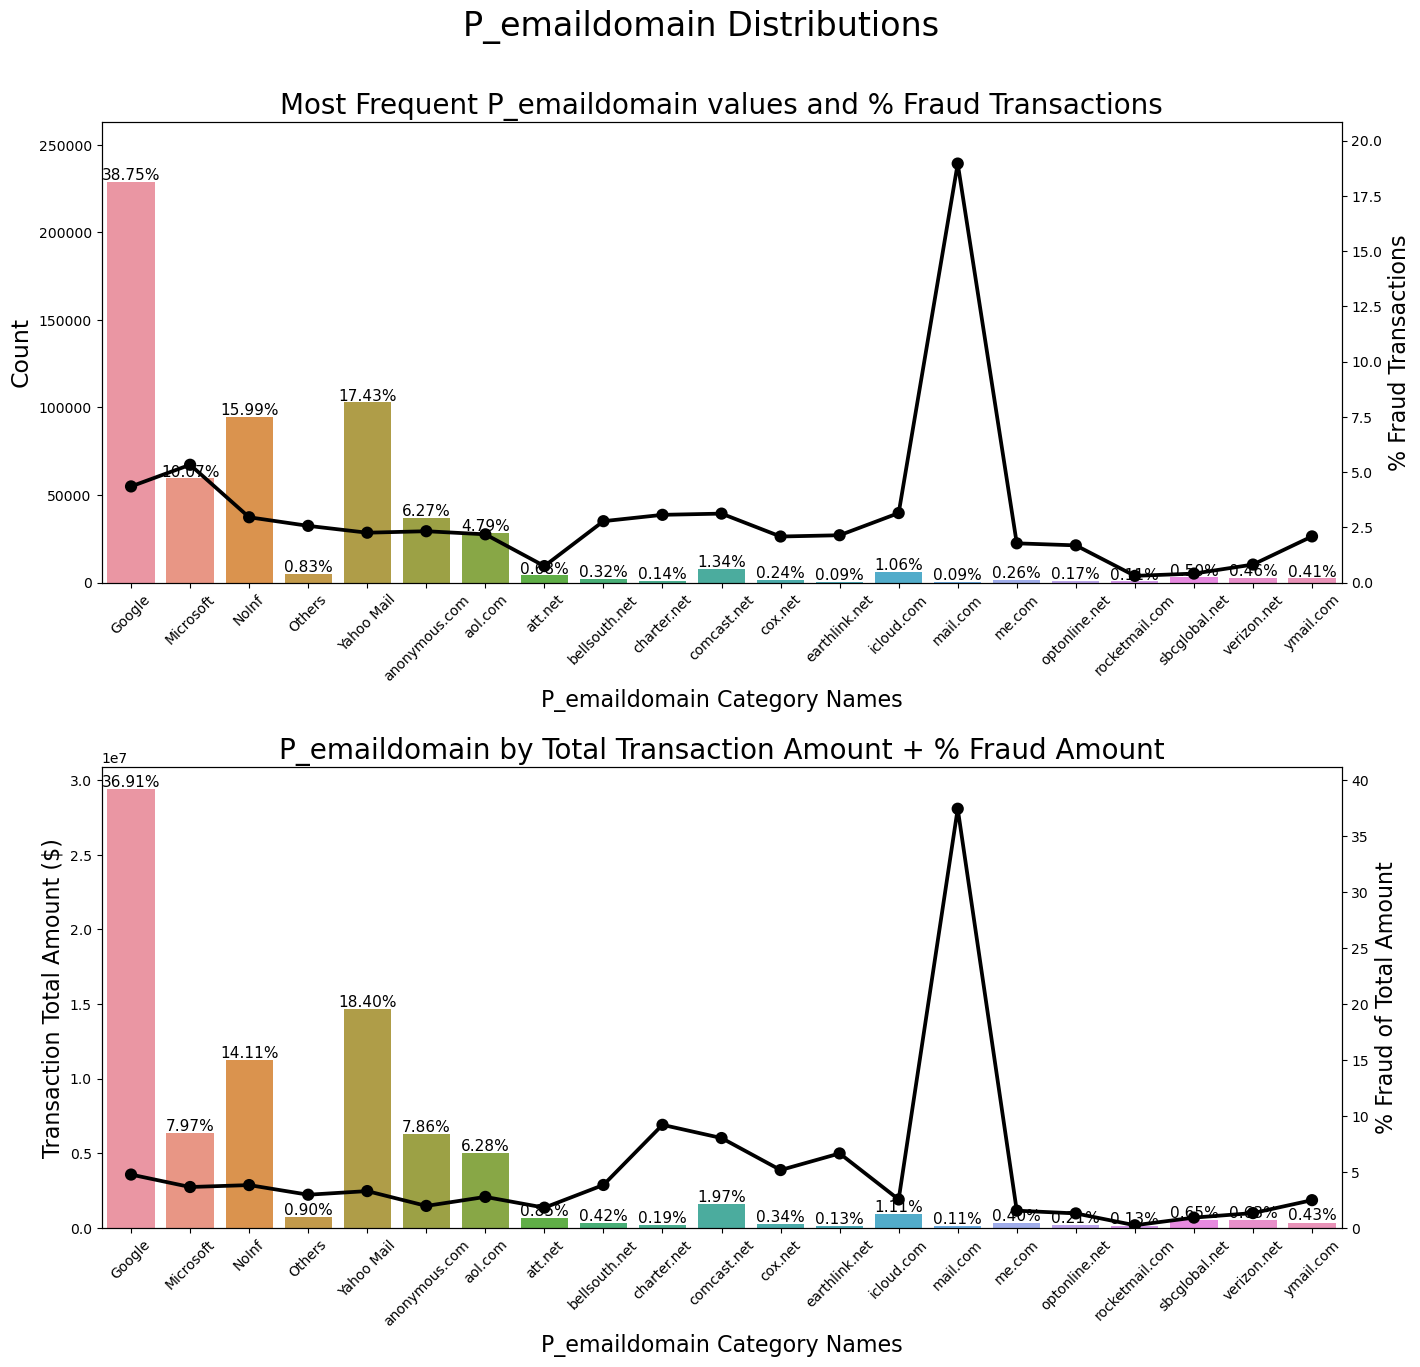

In [39]:
ploting_cnt_amt(df_trans, 'P_emaildomain')

**R-Email Domain plot distribution**
- I will group all e-mail domains by the respective enterprises.
- I will set as "Others" all values with less than 300 entries.

In [40]:
df_trans.loc[df_trans['R_emaildomain'].isin(['gmail.com', 'gmail']),'R_emaildomain'] = 'Google'

df_trans.loc[df_trans['R_emaildomain'].isin(['yahoo.com', 'yahoo.com.mx',  'yahoo.co.uk',
                                             'yahoo.co.jp', 'yahoo.de', 'yahoo.fr',
                                             'yahoo.es']), 'R_emaildomain'] = 'Yahoo Mail'
df_trans.loc[df_trans['R_emaildomain'].isin(['hotmail.com','outlook.com','msn.com', 'live.com.mx', 
                                             'hotmail.es','hotmail.co.uk', 'hotmail.de',
                                             'outlook.es', 'live.com', 'live.fr',
                                             'hotmail.fr']), 'R_emaildomain'] = 'Microsoft'
df_trans.loc[df_trans.R_emaildomain.isin(df_trans.R_emaildomain\
                                         .value_counts()[df_trans.R_emaildomain.value_counts() <= 300 ]\
                                         .index), 'R_emaildomain'] = "Others"
df_trans.R_emaildomain.fillna("NoInf", inplace=True)

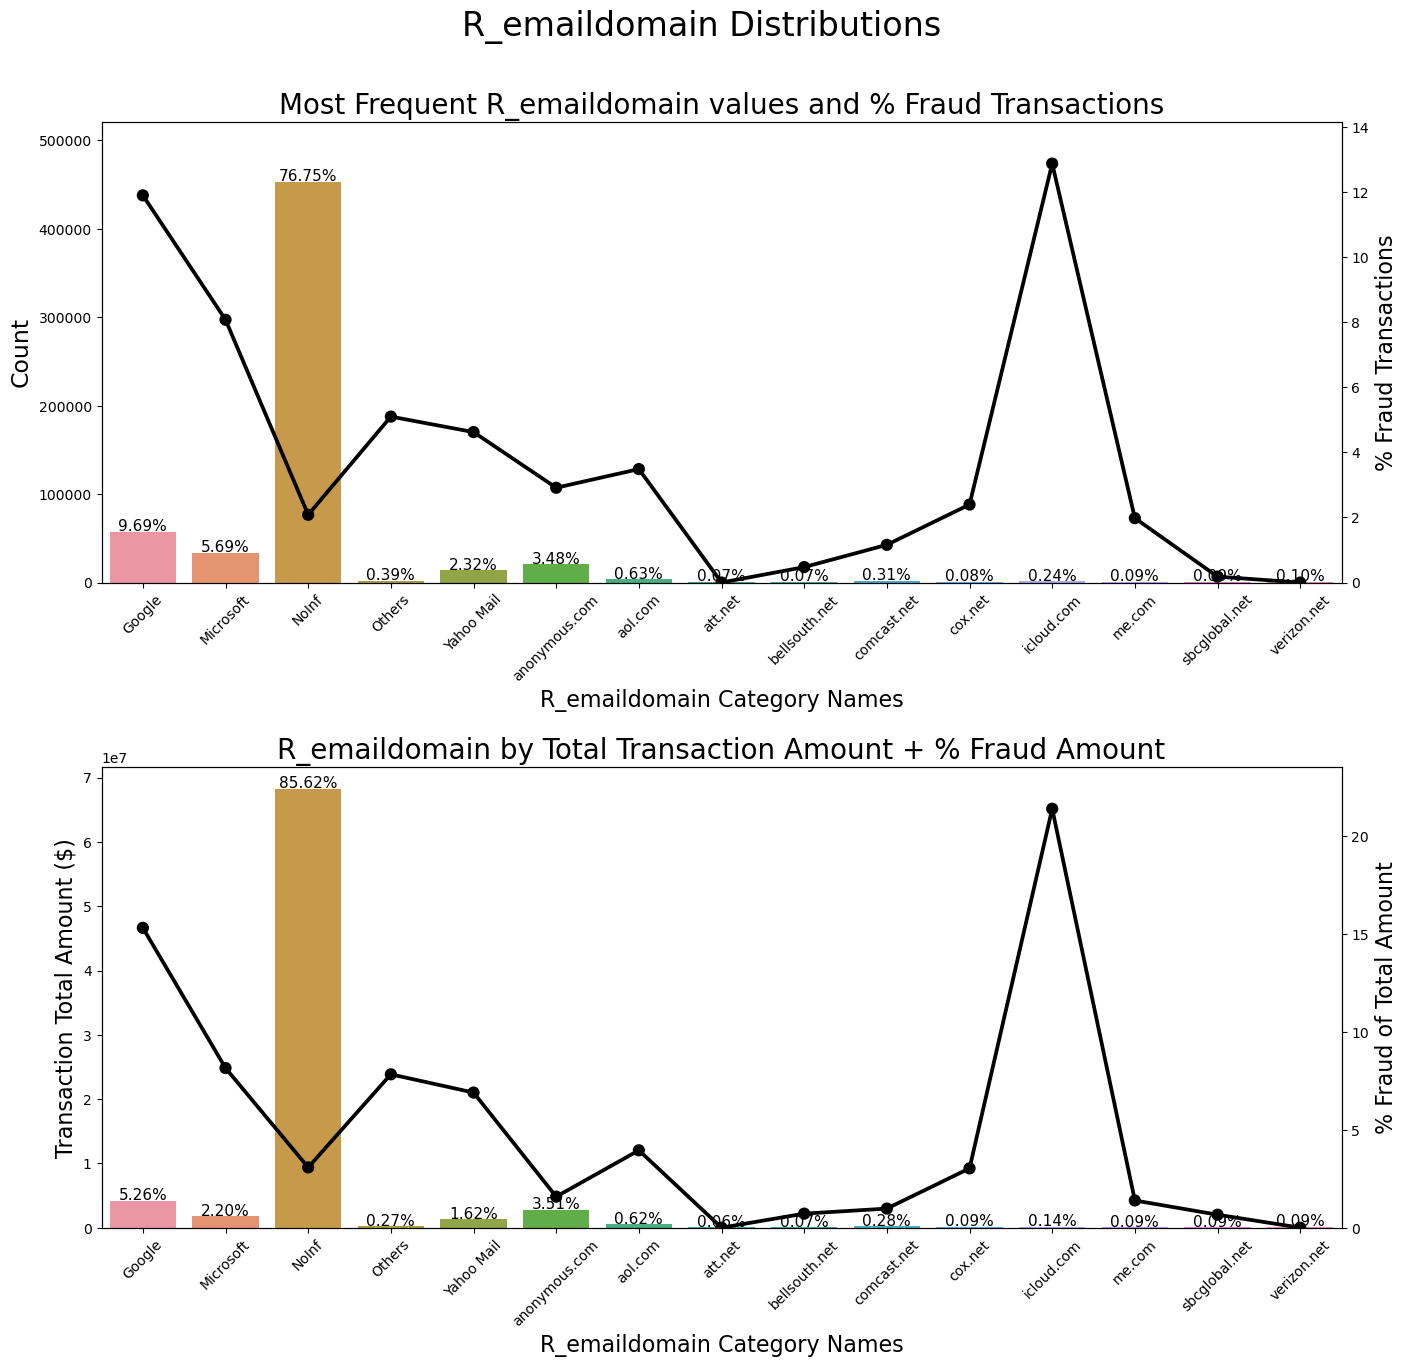

In [41]:
ploting_cnt_amt(df_trans, 'R_emaildomain')


- We can see a very similar distribution in both email domain features.
- It's interesting that we have high values in google and icloud frauds

##### C1-C14 features

In [42]:
resumetable(df_trans[['C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8',
                      'C9', 'C10', 'C11', 'C12', 'C13', 'C14']])

Dataset Shape: (590540, 14)


,Name,dtypes,Missing,Uniques,First Value,Second Value,Third Value,Entropy
0,C1,float16,0,1495,1.0,1.0,1.0,2.72
1,C2,float16,0,1167,1.0,1.0,1.0,2.75
2,C3,float16,0,27,0.0,0.0,0.0,0.04
3,C4,float16,0,1223,0.0,0.0,0.0,1.12
4,C5,float16,0,319,0.0,0.0,0.0,2.06
5,C6,float16,0,1291,1.0,1.0,1.0,2.52
6,C7,float16,0,1069,0.0,0.0,0.0,0.71
7,C8,float16,0,1130,0.0,0.0,0.0,1.25
8,C9,float16,0,205,1.0,0.0,1.0,2.62
9,C10,float16,0,1122,0.0,0.0,0.0,1.23


In [43]:
df_trans[['C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8',
                      'C9', 'C10', 'C11', 'C12', 'C13', 'C14']].describe()

,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14
count,590540.0,590540.0,590540.000000,590540.0,590540.0,590540.0,590540.0,590540.0,590540.0,590540.0,590540.0,590540.0,590540.0,590540.0
mean,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,0.150635,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN
min,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25%,1.0,1.0,0.000000,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0
50%,1.0,1.0,0.000000,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,3.0,1.0
75%,3.0,3.0,0.000000,0.0,1.0,2.0,0.0,0.0,2.0,0.0,2.0,0.0,12.0,2.0
max,4684.0,5692.0,26.000000,2252.0,349.0,2252.0,2256.0,3332.0,210.0,3256.0,3188.0,3188.0,2918.0,1429.0


In [44]:
df_trans[['C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8',
                      'C9', 'C10', 'C11', 'C12', 'C13', 'C14']].describe()

,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14
count,590540.0,590540.0,590540.000000,590540.0,590540.0,590540.0,590540.0,590540.0,590540.0,590540.0,590540.0,590540.0,590540.0,590540.0
mean,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,0.150635,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN
min,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25%,1.0,1.0,0.000000,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0
50%,1.0,1.0,0.000000,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,3.0,1.0
75%,3.0,3.0,0.000000,0.0,1.0,2.0,0.0,0.0,2.0,0.0,2.0,0.0,12.0,2.0
max,4684.0,5692.0,26.000000,2252.0,349.0,2252.0,2256.0,3332.0,210.0,3256.0,3188.0,3188.0,2918.0,1429.0


**C1 Distribution Plot**

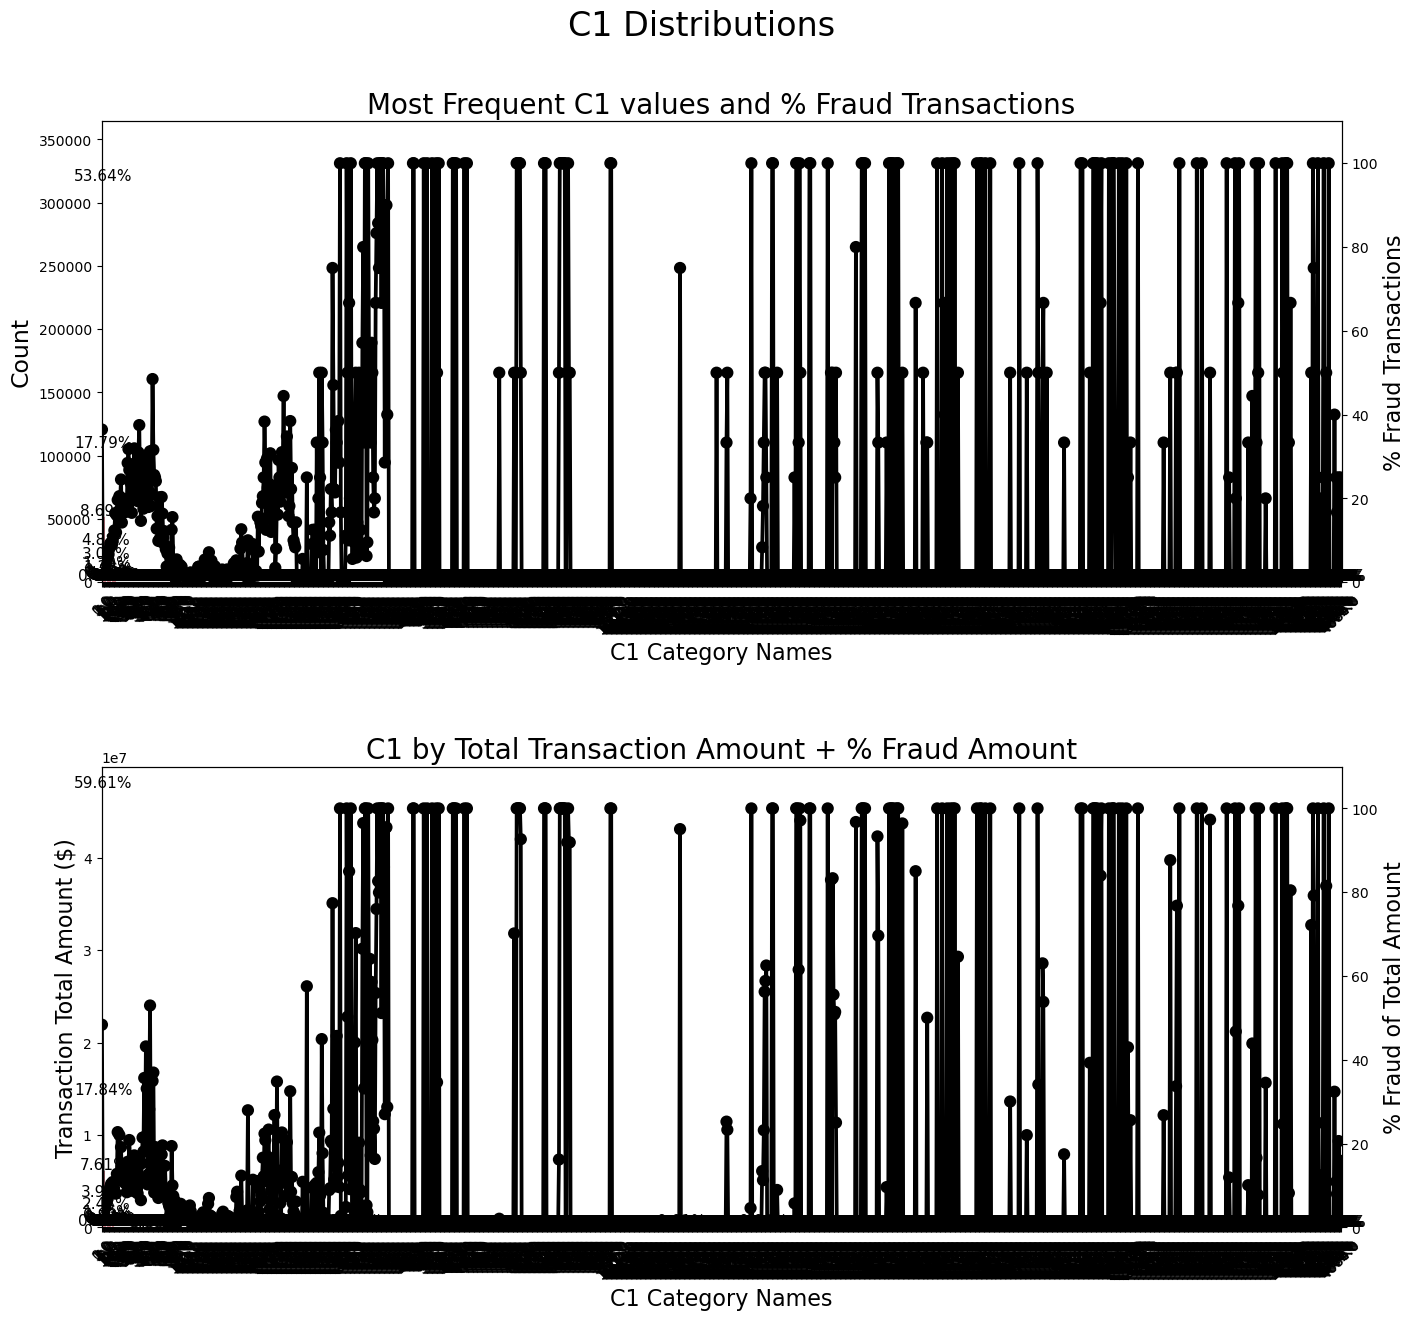

In [45]:
ploting_cnt_amt(df_trans, 'C1')

In [46]:
df_trans.loc[df_trans.C2.isin(df_trans.C2\
                              .value_counts()[df_trans.C2.value_counts() <= 350 ]\
                              .index), 'C2'] = "Others"

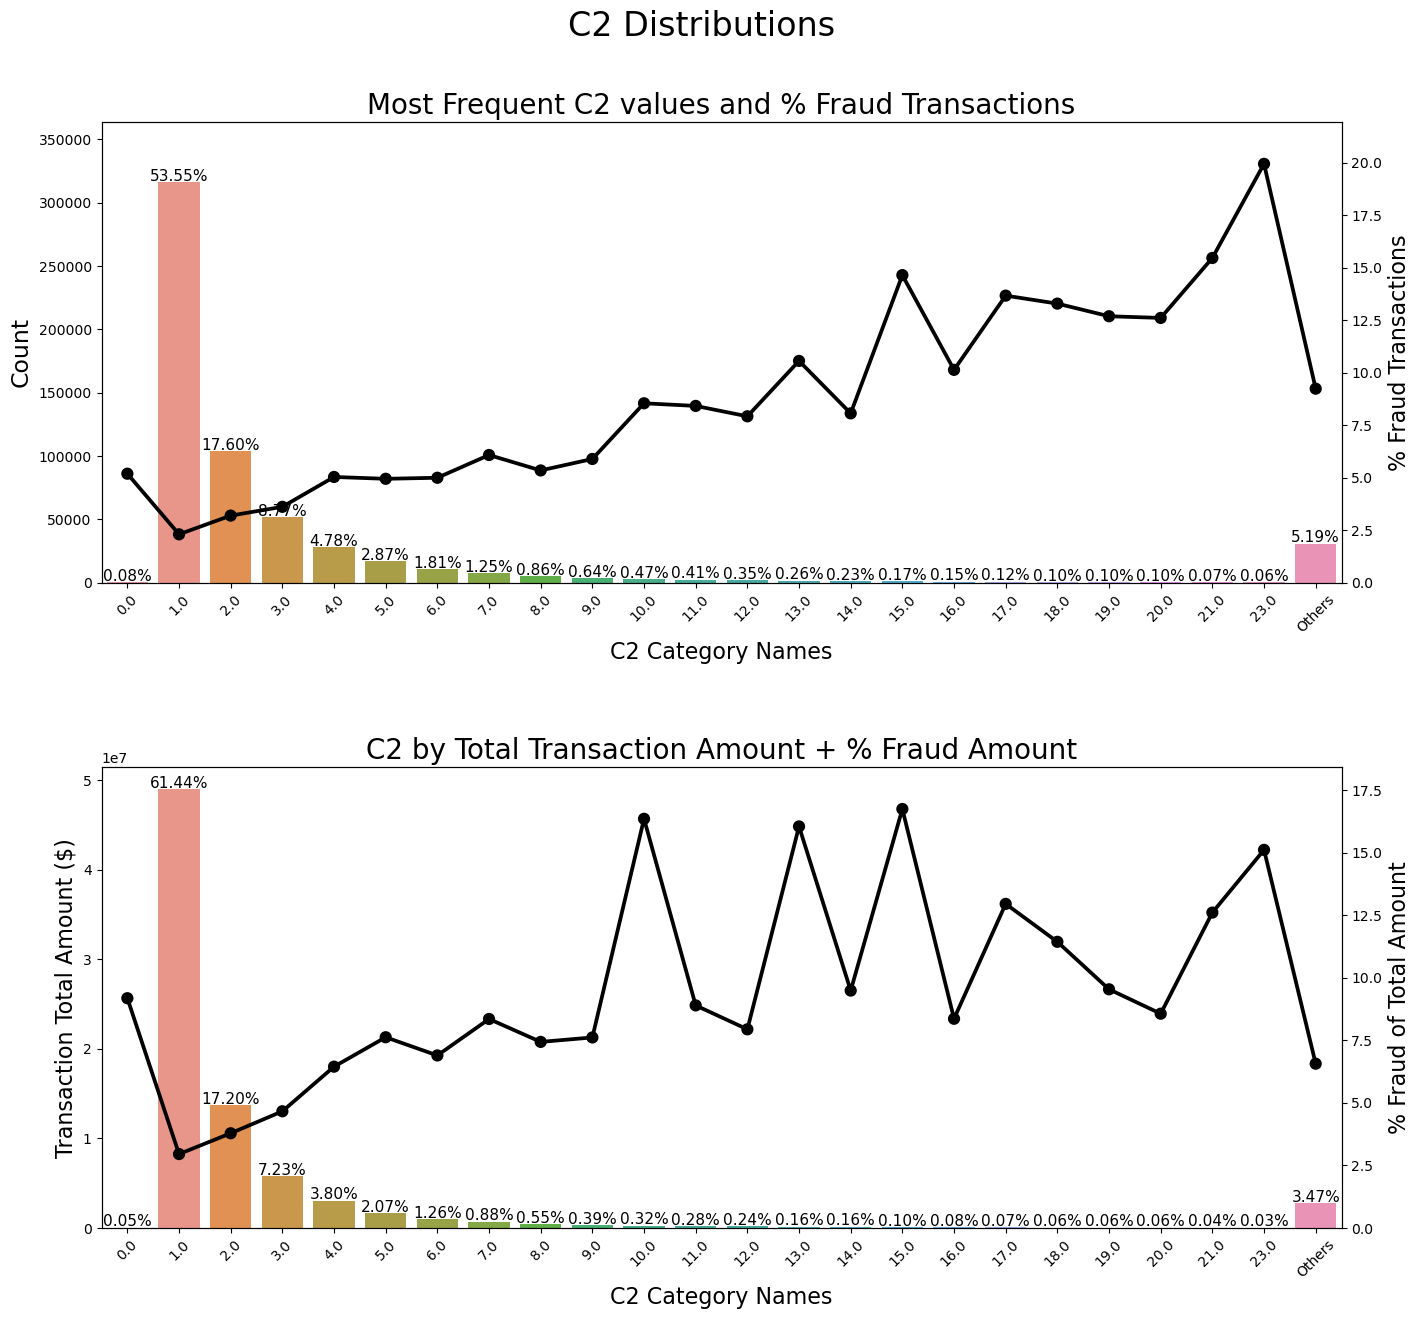

In [47]:
ploting_cnt_amt(df_trans, 'C2')

- Top 3 values are 1, 2 and 3 and is the same on Total Amounts. We see the same pattern on fraud ratios

##### TimeDelta Feature
- Let's see if the frauds have some specific hour that has highest % of frauds
- Converting to Total Days, Weekdays and Hours.

We convert transaction timestamps into human-readable time features.

In [48]:
import datetime

START_DATE = '2017-12-01'
startdate = datetime.datetime.strptime(START_DATE, "%Y-%m-%d")
df_trans["Date"] = df_trans['TransactionDT'].apply(lambda x: (startdate + datetime.timedelta(seconds=x)))

df_trans['_Weekdays'] = df_trans['Date'].dt.dayofweek
df_trans['_Hours'] = df_trans['Date'].dt.hour
df_trans['_Days'] = df_trans['Date'].dt.day

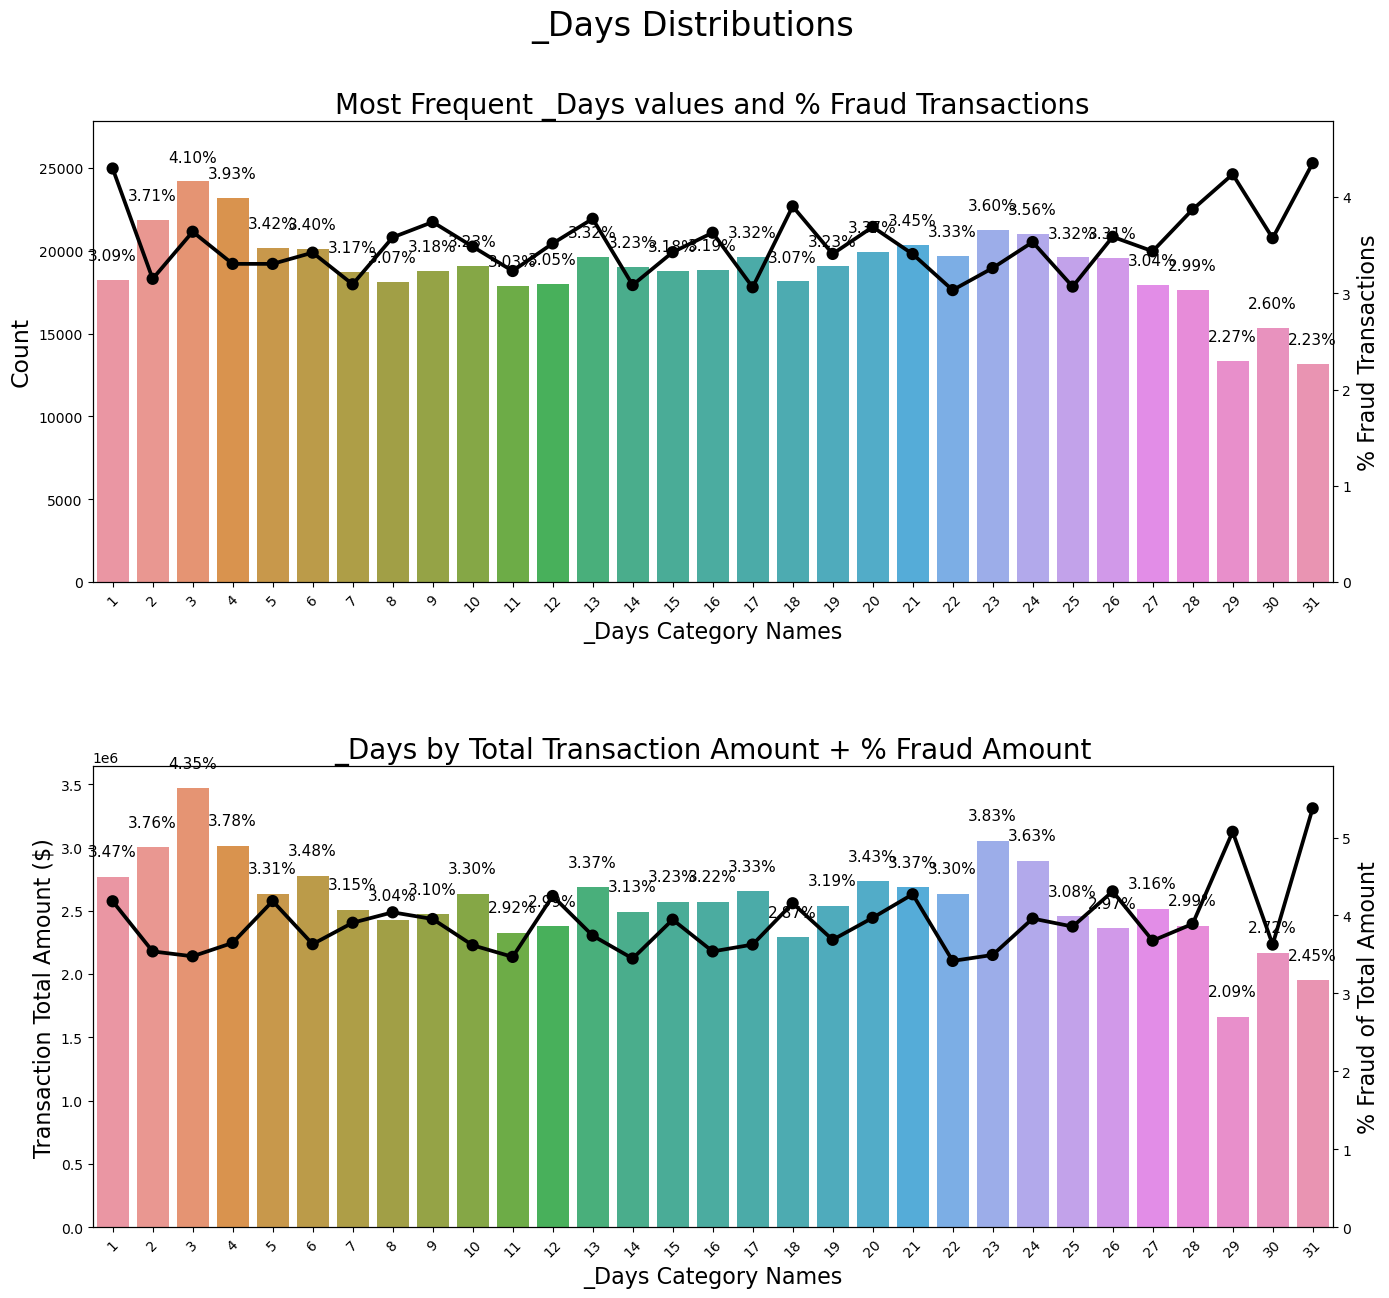

In [49]:
ploting_cnt_amt(df_trans, '_Days')

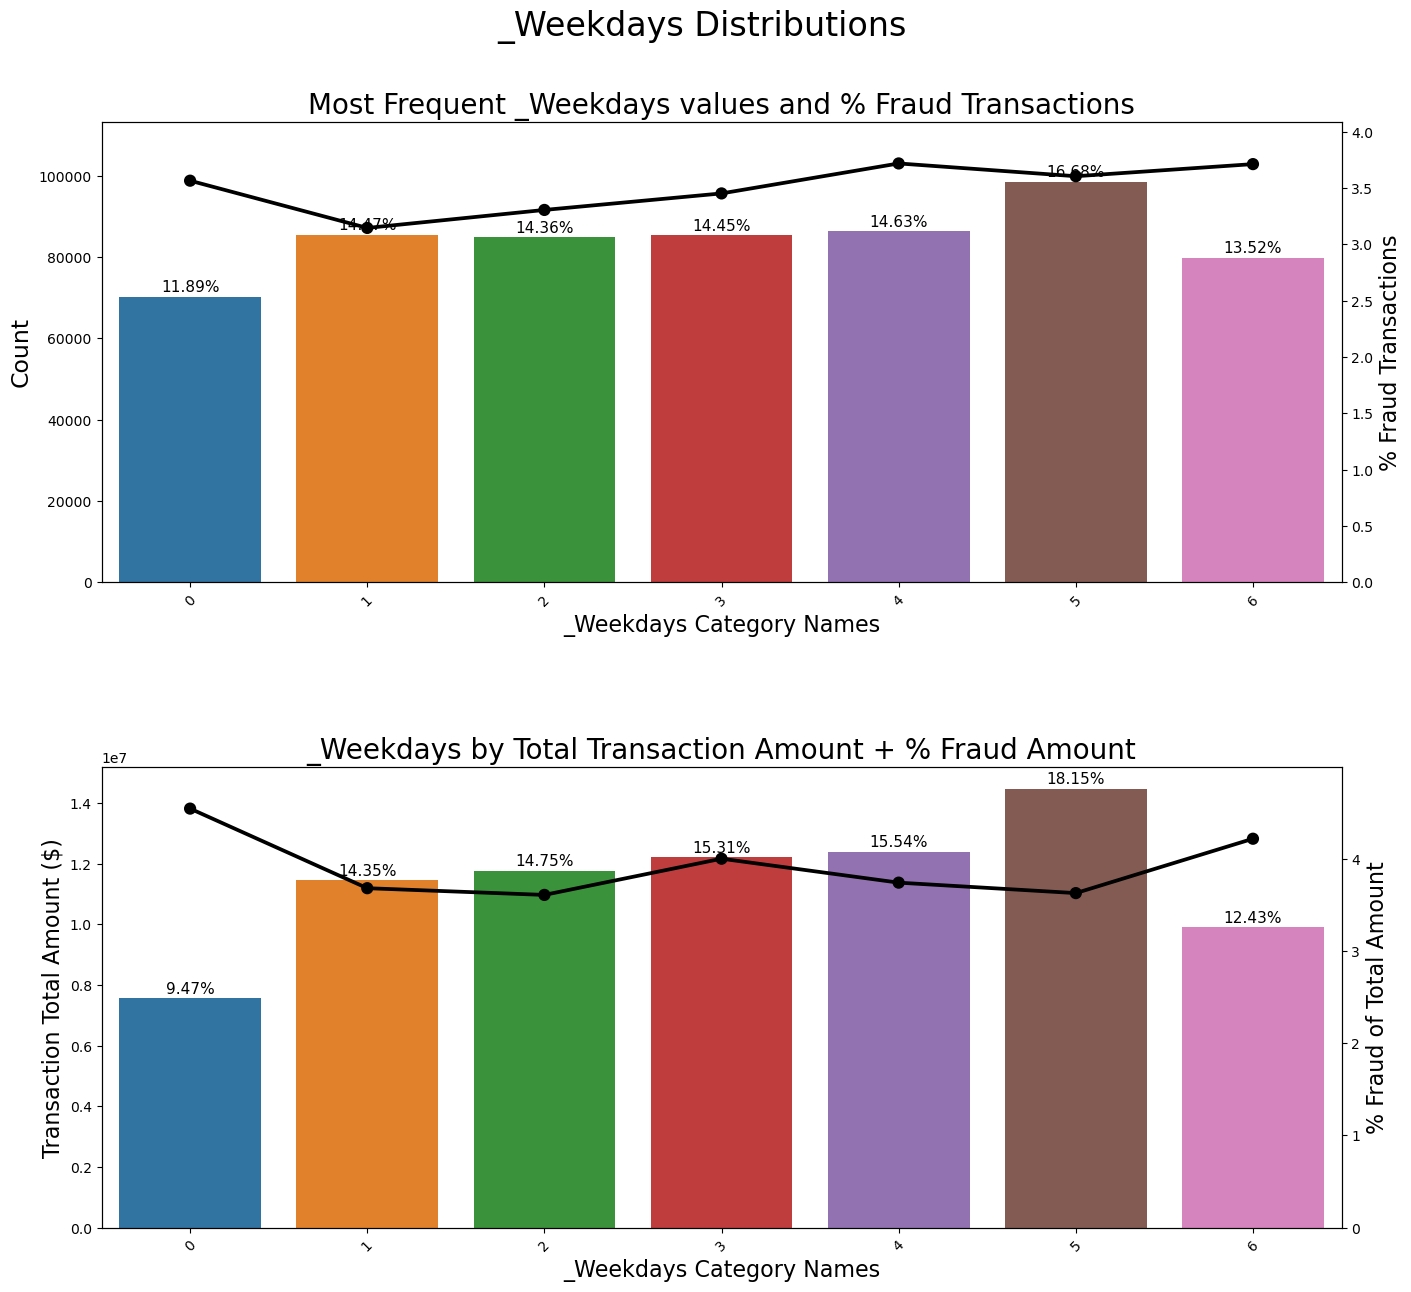

In [50]:
# Ploting WeekDays Distributions

ploting_cnt_amt(df_trans, '_Weekdays')

- We don't have the reference of date but we can see that two days has lower transactions, that we can infer it is weekend days

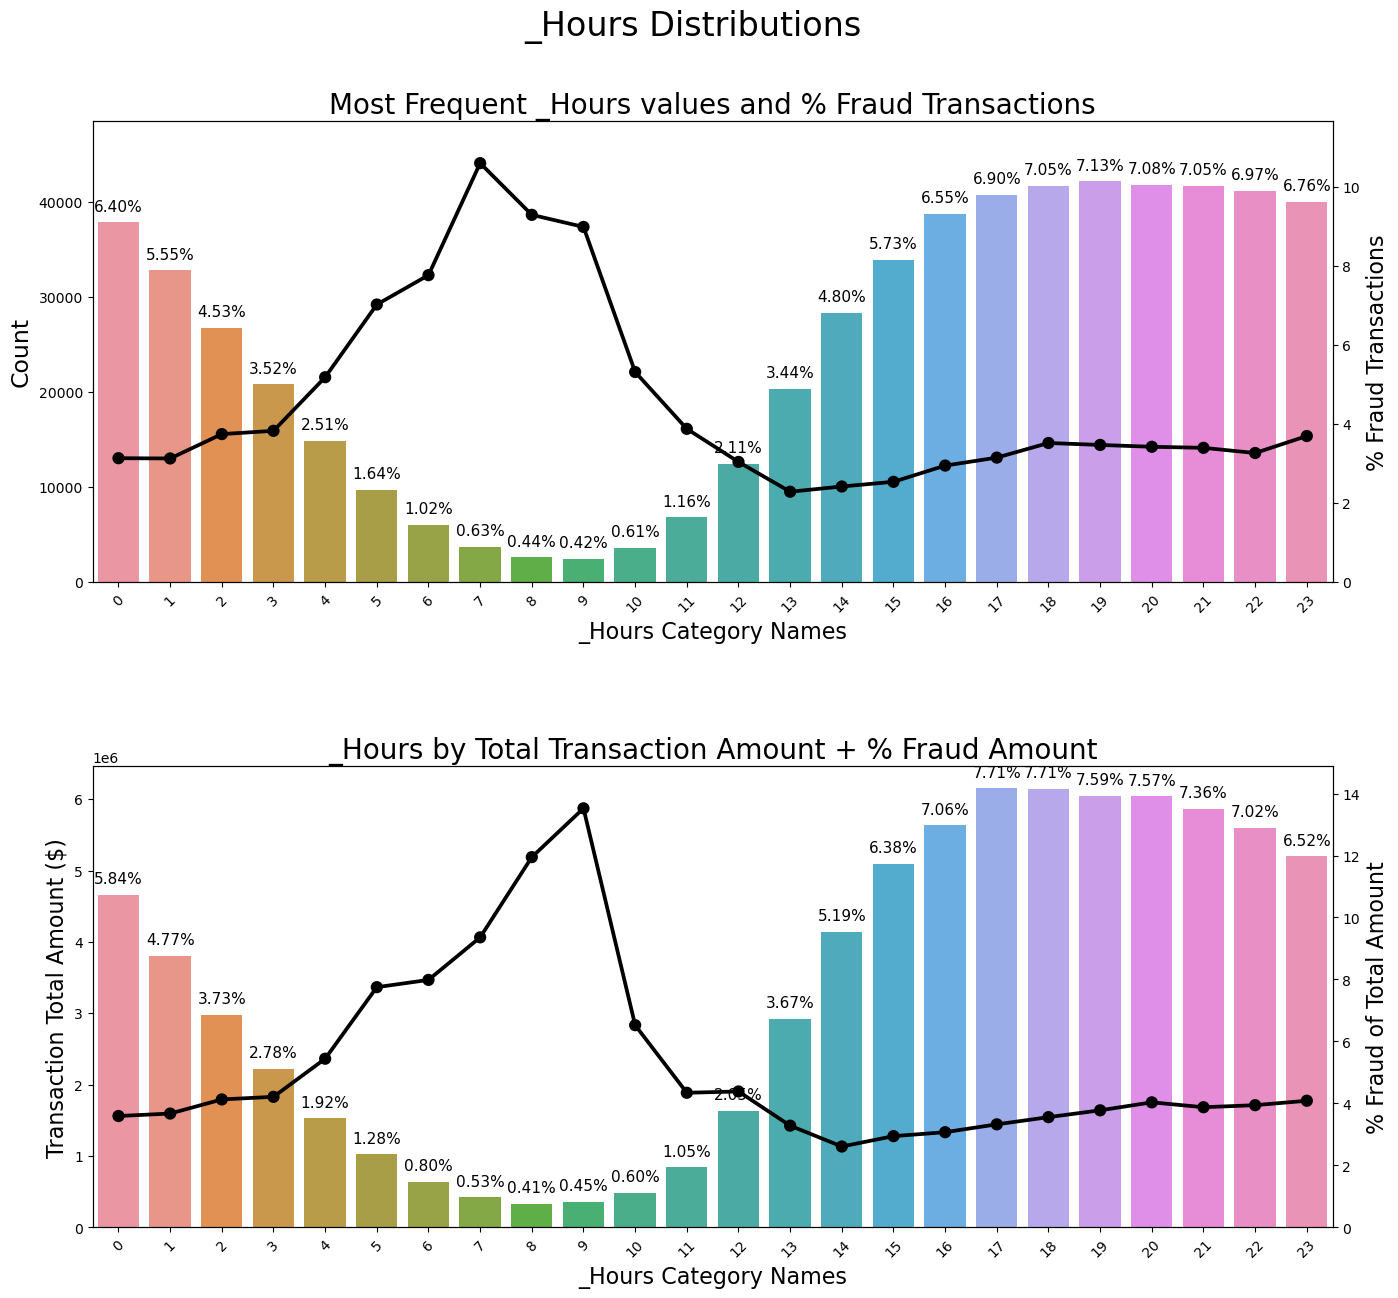

In [51]:
# Ploting Hours Distributions
ploting_cnt_amt(df_trans, '_Hours')

##### Features [id_12 to id_38]

In [52]:
df_id[['id_12', 'id_13', 'id_14', 'id_15', 'id_16', 'id_17', 'id_18',
       'id_19', 'id_20', 'id_21', 'id_22', 'id_23', 'id_24', 'id_25',
       'id_26', 'id_27', 'id_28', 'id_29', 'id_30', 'id_31', 'id_32',
       'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38']].describe(include='all')

,id_12,id_13,id_14,id_15,id_16,id_17,id_18,id_19,id_20,id_21,id_22,id_23,id_24,id_25,id_26,id_27,id_28,id_29,id_30,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38
count,144233,127320.0,80044.0,140985,129340,139369.0,4.511300e+04,139318.0,139261.0,5159.0,5169.000000,5169,4747.000000,5132.0000,5163.00000,5169,140978,140978,77565,140282,77586.0,73289,77805,140985,140985,140985,140985
unique,2,NaN,NaN,3,2,NaN,NaN,NaN,NaN,NaN,NaN,3,NaN,NaN,NaN,2,2,2,75,130,NaN,260,4,2,2,2,2
top,NotFound,NaN,NaN,Found,Found,NaN,NaN,NaN,NaN,NaN,NaN,IP_PROXY:TRANSPARENT,NaN,NaN,NaN,Found,Found,Found,Windows 10,chrome 63.0,NaN,1920x1080,match_status:2,T,F,T,F
freq,123025,NaN,NaN,67728,66324,NaN,NaN,NaN,NaN,NaN,NaN,3489,NaN,NaN,NaN,5155,76232,74926,21155,22000,NaN,16874,60011,77814,134066,110452,73922
mean,NaN,NaN,NaN,NaN,NaN,NaN,inf,NaN,NaN,inf,inf,NaN,12.789062,inf,inf,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,0.0,NaN,NaN,NaN,0.0,1.561523e+00,NaN,NaN,inf,6.898438,NaN,2.375000,97.4375,32.09375,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,10.0,-660.0,NaN,NaN,100.0,1.000000e+01,100.0,100.0,100.0,10.000000,NaN,11.000000,100.0000,100.00000,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,49.0,-360.0,NaN,NaN,166.0,1.300000e+01,266.0,256.0,252.0,14.000000,NaN,11.000000,321.0000,119.00000,NaN,NaN,NaN,NaN,NaN,24.0,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,52.0,-300.0,NaN,NaN,166.0,1.500000e+01,341.0,472.0,252.0,14.000000,NaN,11.000000,321.0000,149.00000,NaN,NaN,NaN,NaN,NaN,24.0,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,52.0,-300.0,NaN,NaN,225.0,1.500000e+01,427.0,533.0,486.5,14.000000,NaN,15.000000,371.0000,169.00000,NaN,NaN,NaN,NaN,NaN,32.0,NaN,NaN,NaN,NaN,NaN,NaN


In [53]:
#df_train = df_trans.merge(df_id, how='left', left_index=True, right_index=True)
df_train = df_trans.merge(df_id, on='TransactionID', how='left')


In [54]:
def cat_feat_ploting(df, col):
    tmp = pd.crosstab(df[col], df['isFraud'], normalize='index') * 100
    tmp = tmp.reset_index()
    tmp.rename(columns={0:'NoFraud', 1:'Fraud'}, inplace=True)

    plt.figure(figsize=(14,10))
    plt.suptitle(f'{col} Distributions', fontsize=22)

    plt.subplot(221)
    g = sns.countplot(x=col, data=df, order=tmp[col].values)
    # plt.legend(title='Fraud', loc='upper center', labels=['No', 'Yes'])

    g.set_title(f"{col} Distribution", fontsize=19)
    g.set_xlabel(f"{col} Name", fontsize=17)
    g.set_ylabel("Count", fontsize=17)
    # g.set_ylim(0,500000)
    for p in g.patches:
        height = p.get_height()
        g.text(p.get_x()+p.get_width()/2.,
                height + 3,
                '{:1.2f}%'.format(height/total*100),
                ha="center", fontsize=14) 

    plt.subplot(222)
    g1 = sns.countplot(x=col, hue='isFraud', data=df, order=tmp[col].values)
    plt.legend(title='Fraud', loc='best', labels=['No', 'Yes'])
    gt = g1.twinx()
    gt = sns.pointplot(x=col, y='Fraud', data=tmp, color='black', order=tmp[col].values)
    gt.set_ylabel("% of Fraud Transactions", fontsize=16)

    g1.set_title(f"{col} by Target(isFraud)", fontsize=19)
    g1.set_xlabel(f"{col} Name", fontsize=17)
    g1.set_ylabel("Count", fontsize=17)

    plt.subplot(212)
    g3 = sns.boxenplot(x=col, y='TransactionAmt', hue='isFraud', 
                       data=df[df['TransactionAmt'] <= 2000], order=tmp[col].values )
    g3.set_title("Transaction Amount Distribuition by ProductCD and Target", fontsize=20)
    g3.set_xlabel("ProductCD Name", fontsize=17)
    g3.set_ylabel("Transaction Values", fontsize=17)

    plt.subplots_adjust(hspace = 0.4, top = 0.85)

    plt.show()

**Ploting columns with few unique values**

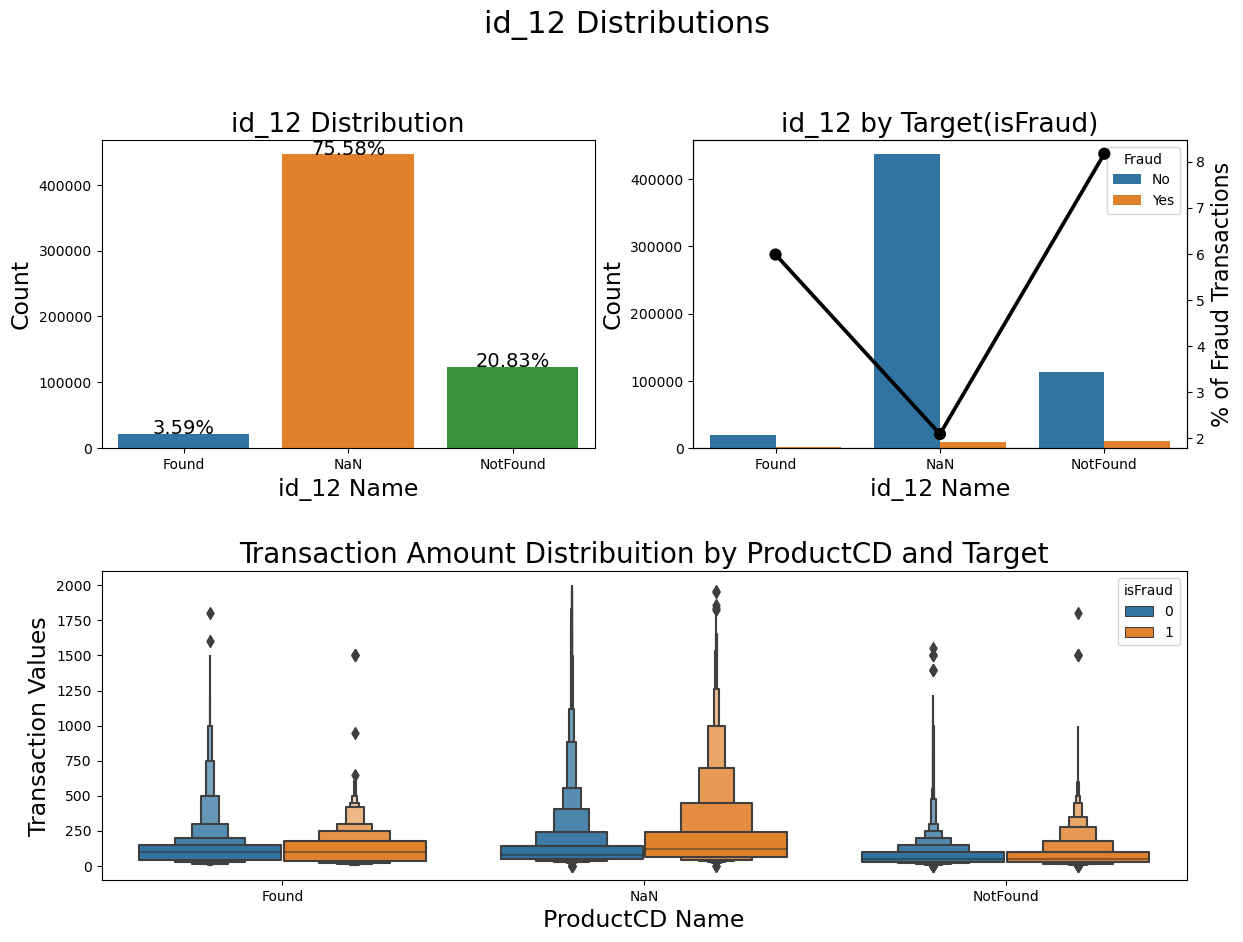

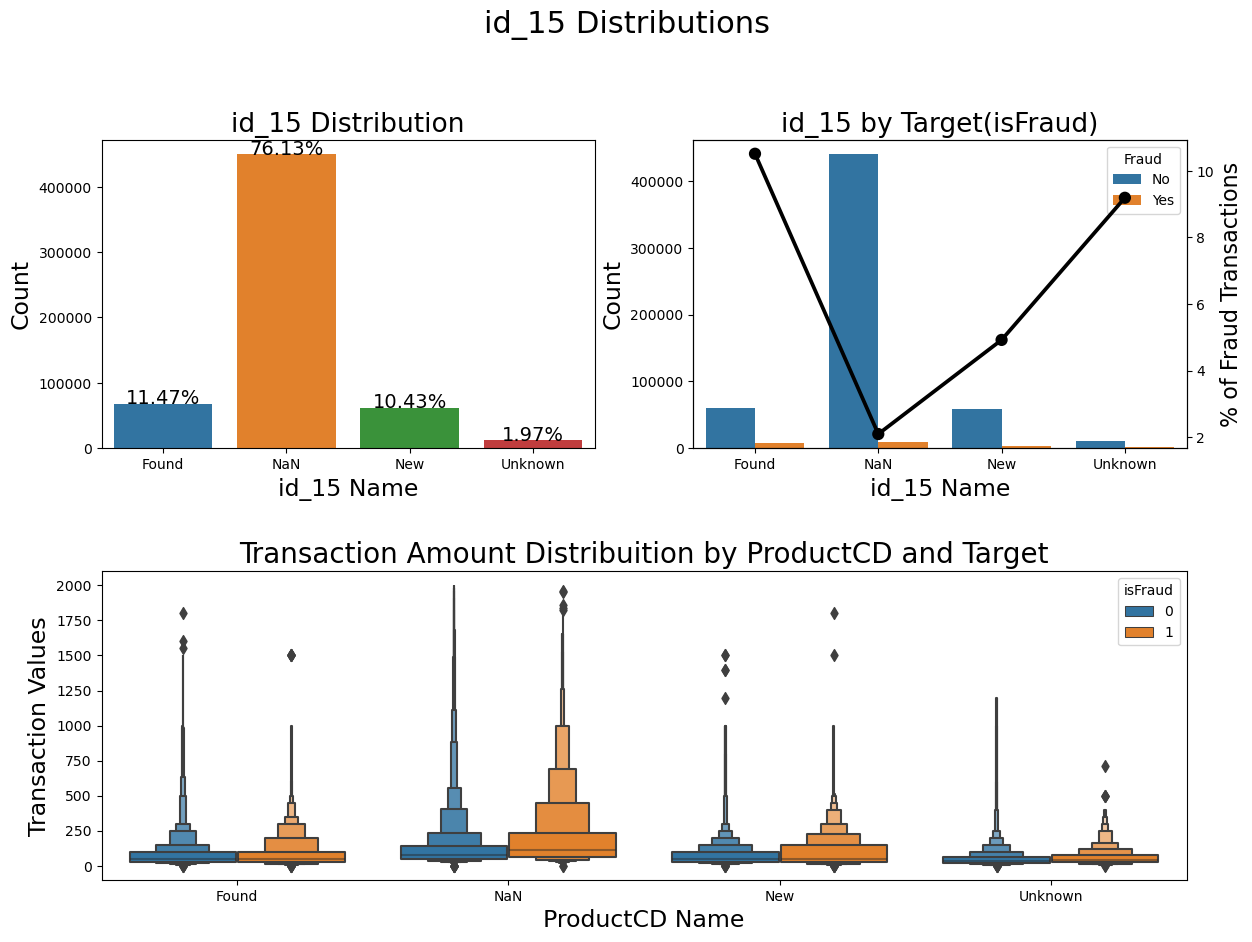

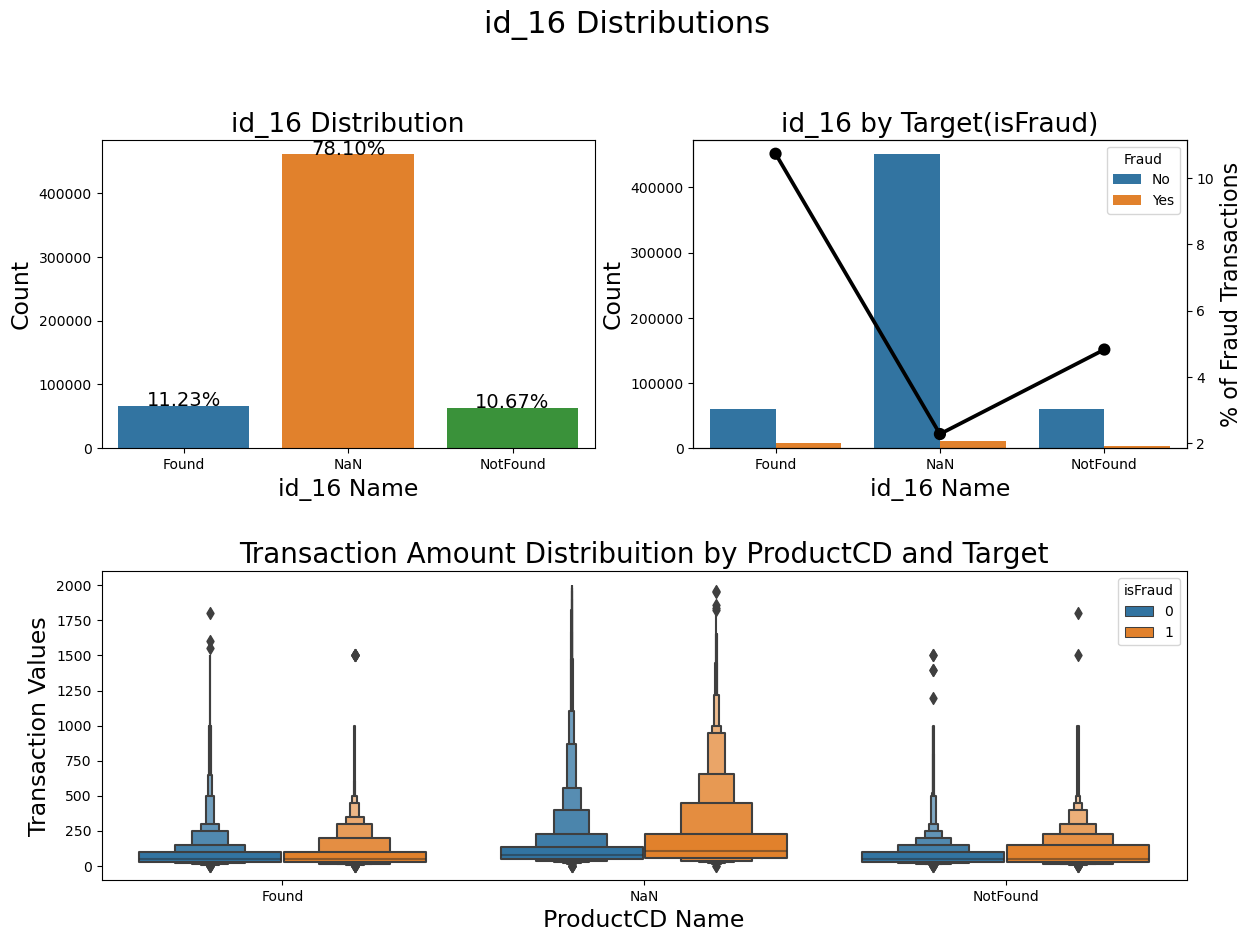

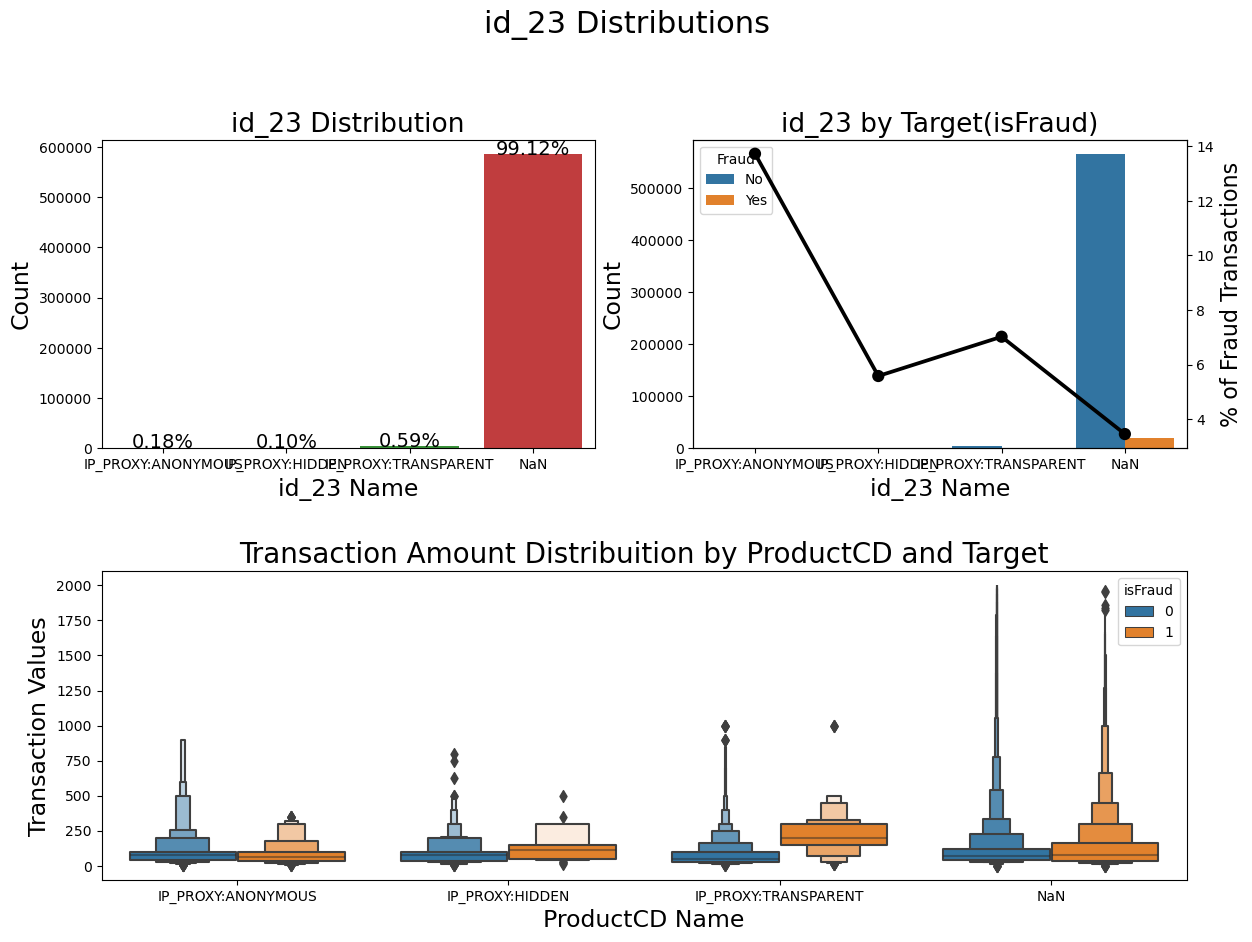

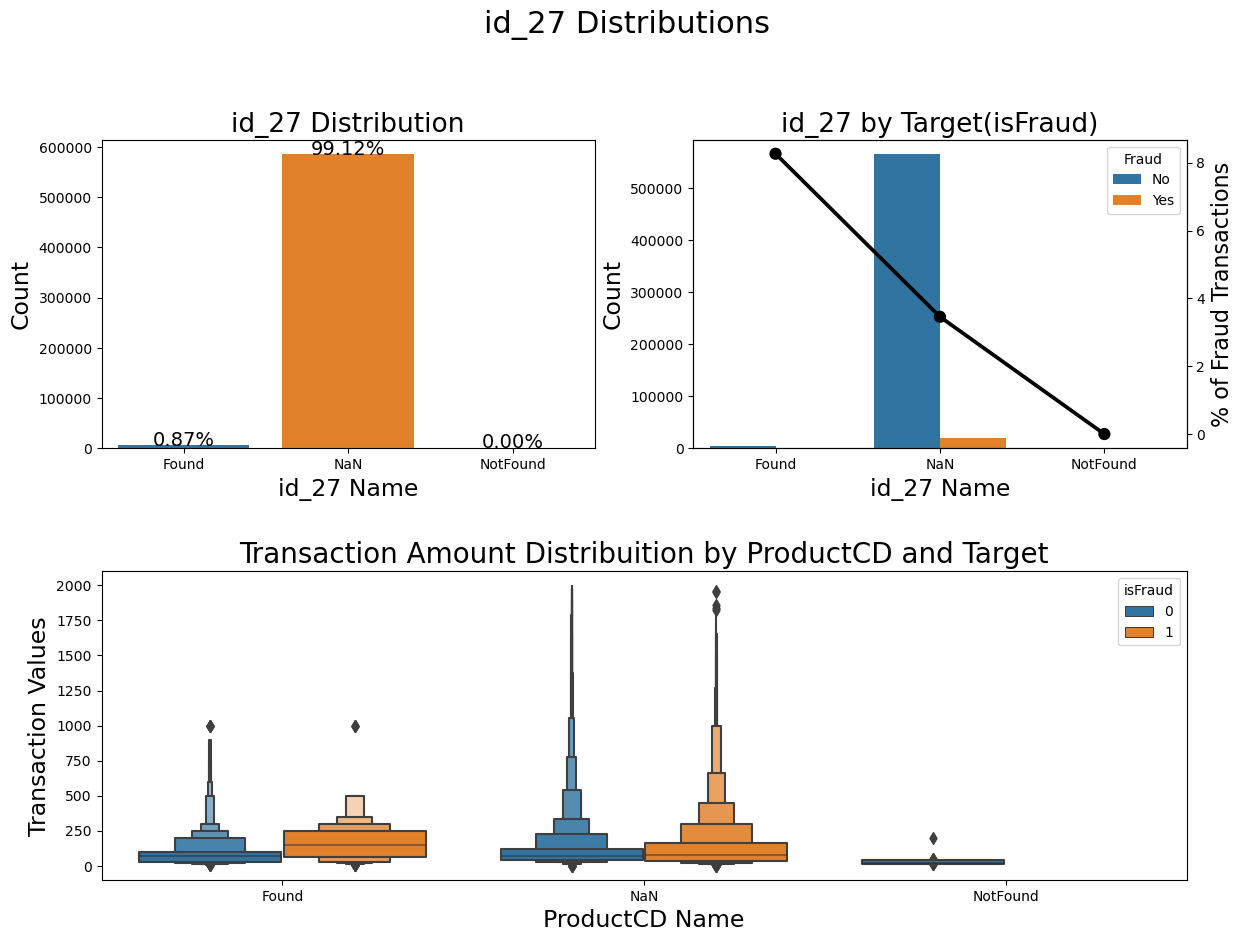

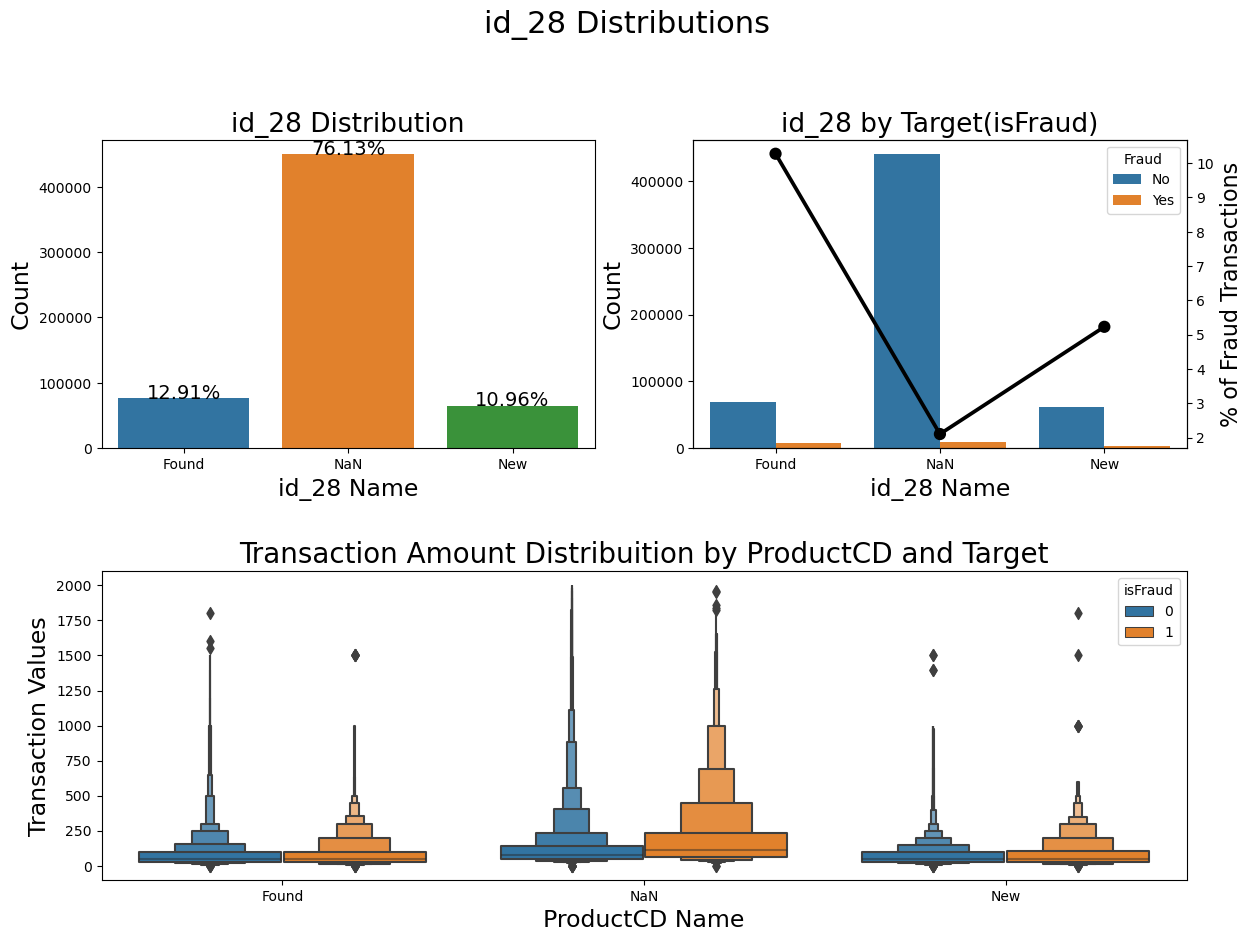

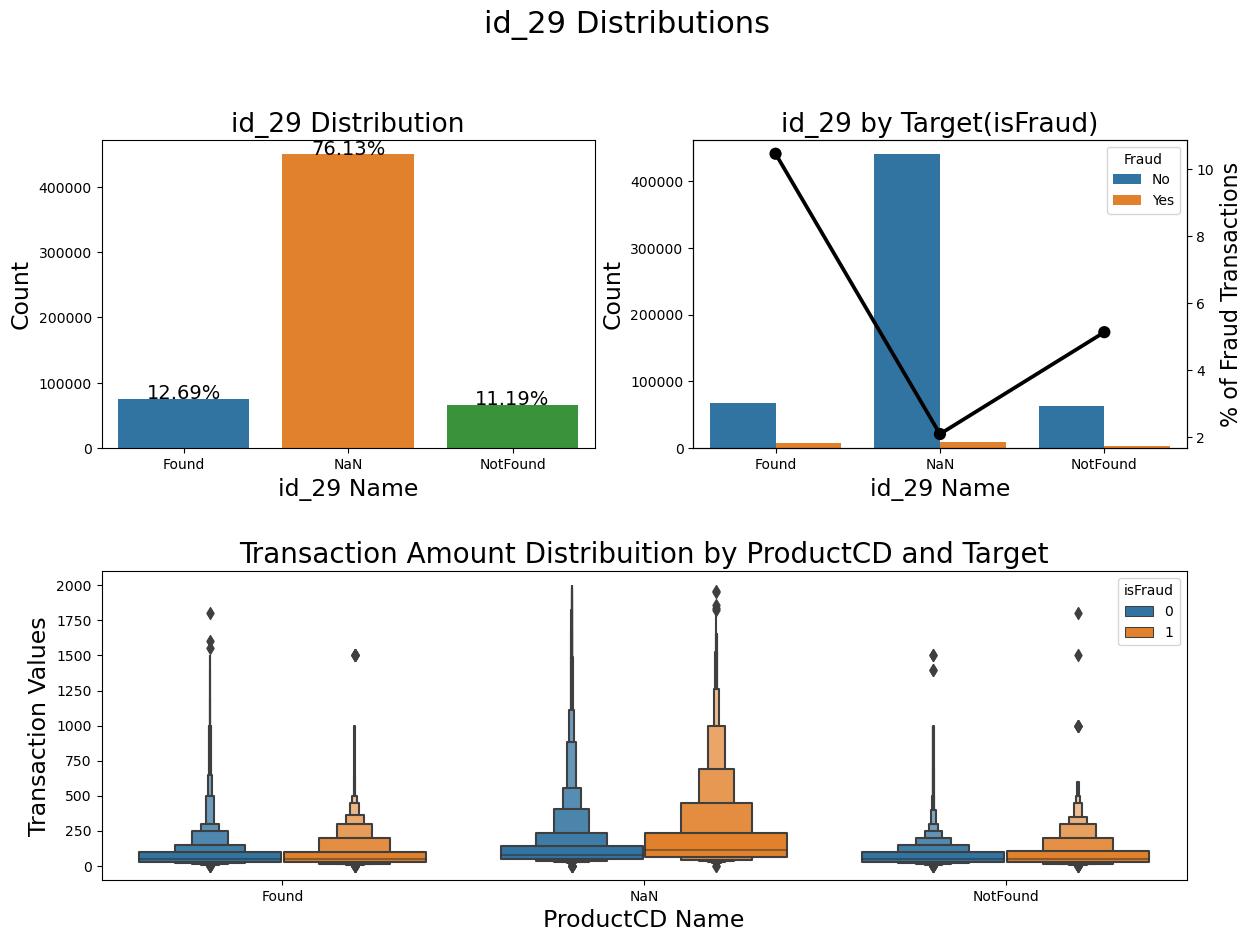

In [55]:
for col in ['id_12', 'id_15', 'id_16', 'id_23', 'id_27', 'id_28', 'id_29']:
    df_train[col] = df_train[col].fillna('NaN')
    cat_feat_ploting(df_train, col)

In [56]:
# Id 30
df_train.loc[df_train['id_30'].str.contains('Windows', na=False), 'id_30'] = 'Windows'
df_train.loc[df_train['id_30'].str.contains('iOS', na=False), 'id_30'] = 'iOS'
df_train.loc[df_train['id_30'].str.contains('Mac OS', na=False), 'id_30'] = 'Mac'
df_train.loc[df_train['id_30'].str.contains('Android', na=False), 'id_30'] = 'Android'
df_train['id_30'].fillna("NAN", inplace=True)

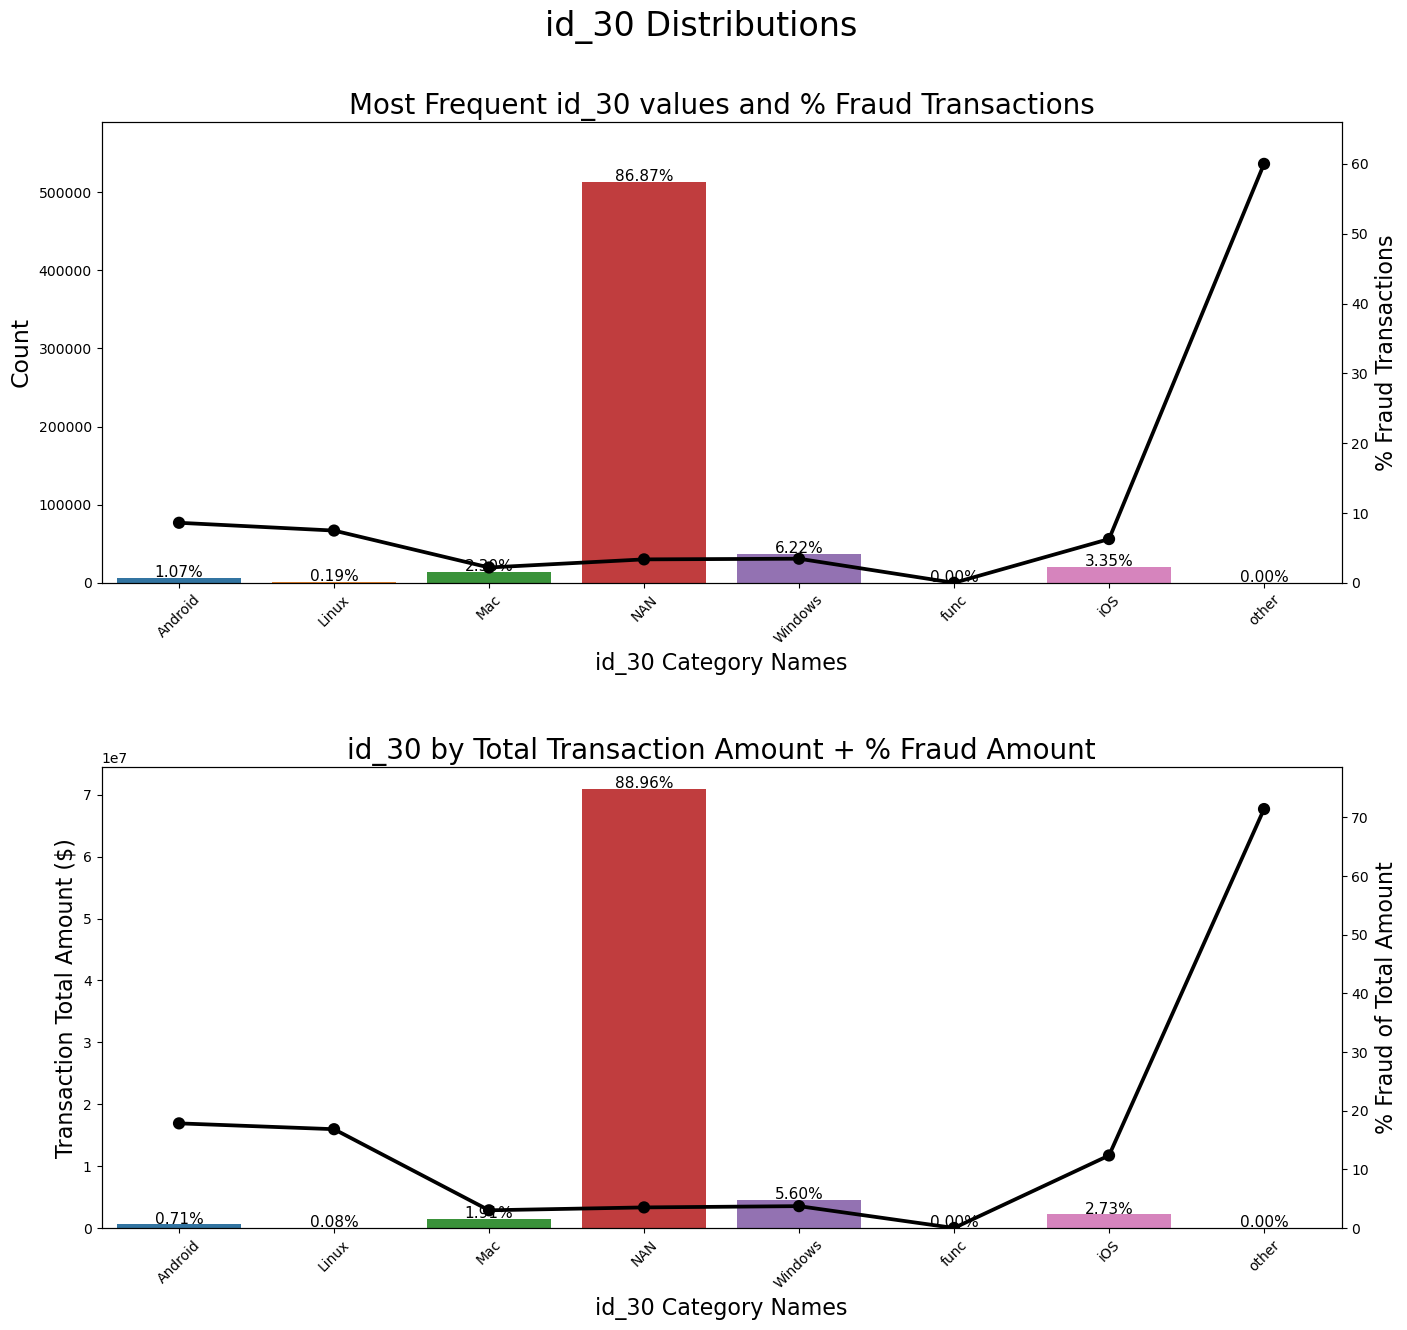

In [57]:
ploting_cnt_amt(df_train, 'id_30')

In [58]:
# Id 31
df_train.loc[df_train['id_31'].str.contains('chrome', na=False), 'id_31'] = 'Chrome'
df_train.loc[df_train['id_31'].str.contains('firefox', na=False), 'id_31'] = 'Firefox'
df_train.loc[df_train['id_31'].str.contains('safari', na=False), 'id_31'] = 'Safari'
df_train.loc[df_train['id_31'].str.contains('edge', na=False), 'id_31'] = 'Edge'
df_train.loc[df_train['id_31'].str.contains('ie', na=False), 'id_31'] = 'IE'
df_train.loc[df_train['id_31'].str.contains('samsung', na=False), 'id_31'] = 'Samsung'
df_train.loc[df_train['id_31'].str.contains('opera', na=False), 'id_31'] = 'Opera'
df_train['id_31'].fillna("NAN", inplace=True)
df_train.loc[df_train.id_31.isin(df_train.id_31.value_counts()[df_train.id_31.value_counts() < 200].index), 'id_31'] = "Others"

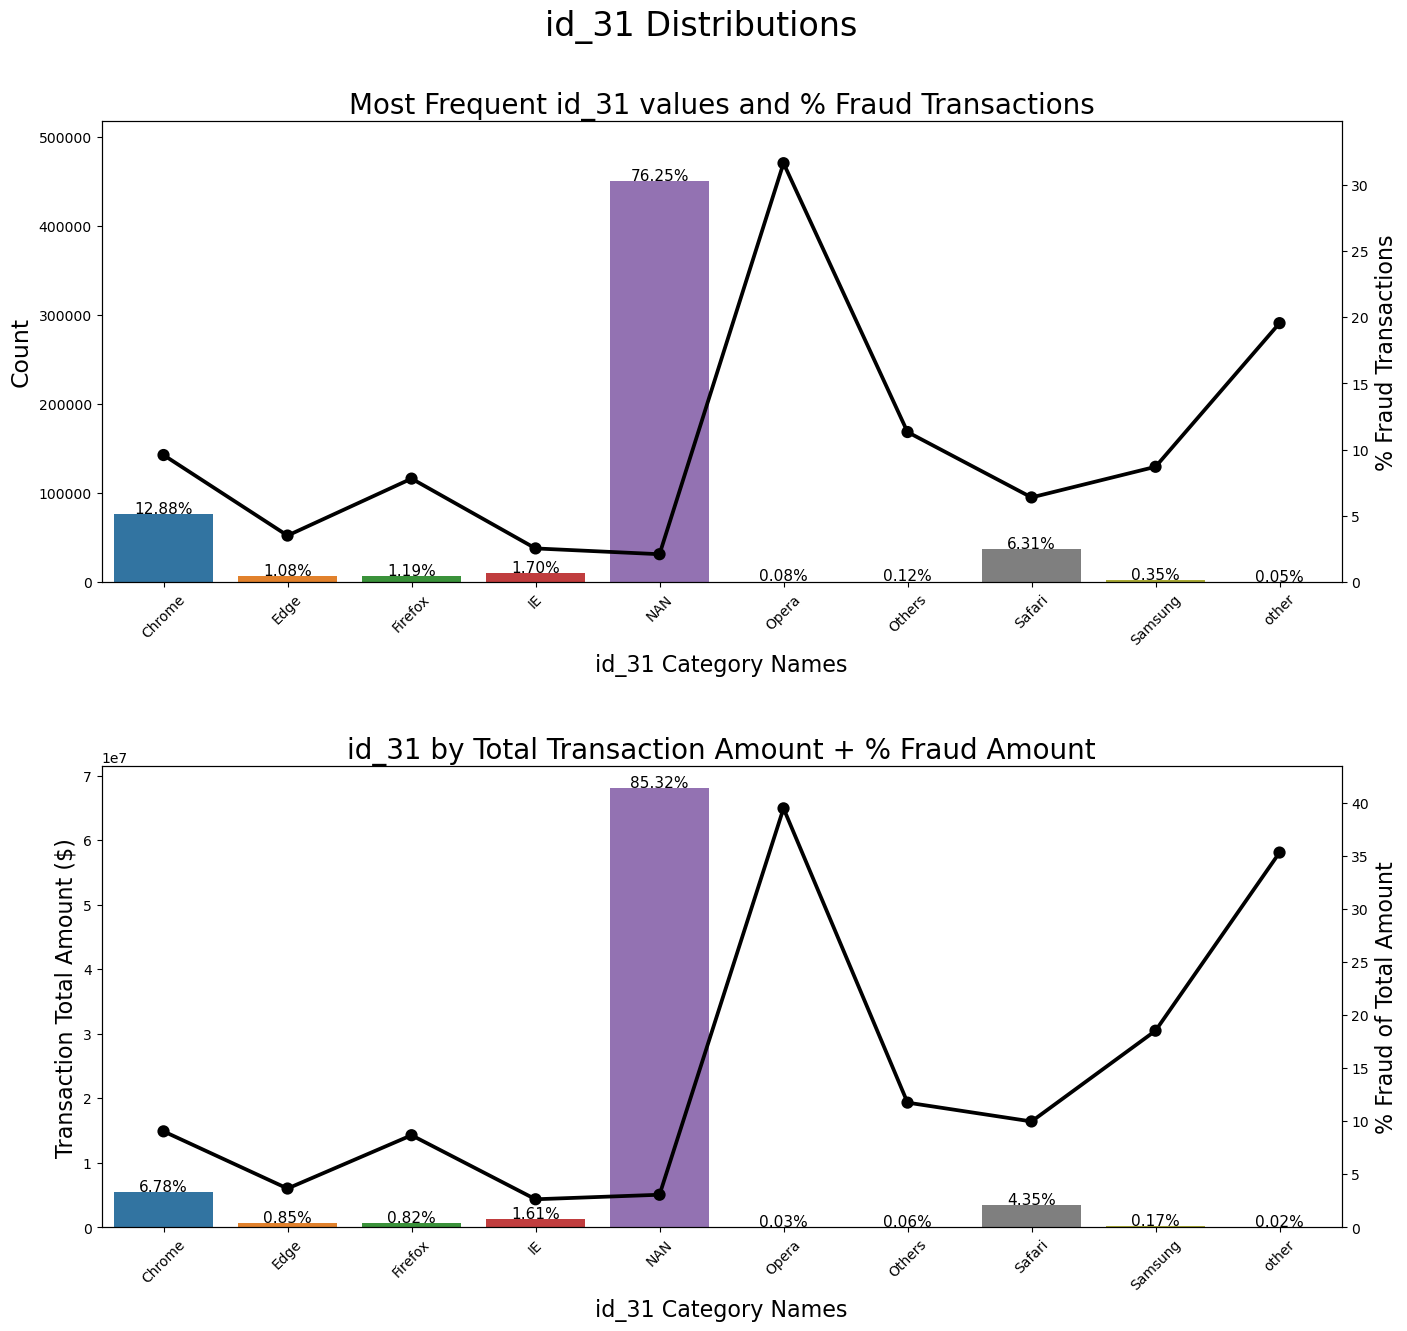

In [59]:
ploting_cnt_amt(df_train, 'id_31')

## Feature Engineering

**Merging Transaction and Identity Data**

The transaction dataset contains payment-level information, while the identity dataset includes device, browser, and user identity features.

We perform a **left join** to:
- Keep all transactions
- Add identity data when available
- Preserve missing identity cases (which may itself signal fraud)


Raw transaction data rarely captures fraud patterns directly.  
We create new features to help the model detect suspicious behavior.

**Types of Features We Create:**
- Log-transformed monetary features  
- Behavioral deviation features  
- Frequency encoding  
- Aggregated card/email statistics  
- Time-based features  
- PCA components from anonymized variables

In [60]:
df_test = test_transaction.merge(test_identity, on='TransactionID', how='left')
df_train = train_transaction.merge(train_identity, on='TransactionID', how='left')

**Log Transform TransactionAmt**
- Transaction amounts are highly skewed. Log transform reduces the effect of extreme values (outliers), which is common in fraud.

In [61]:
for df in [df_train, df_test]:
    df['TransactionAmt_log'] = np.log1p(df['TransactionAmt'])

**Relative Transaction Amount Features**
- Fraud often occurs with unusual transaction amounts compared to user’s typical behavior or card behavior.

In [62]:
for df in [df_train, df_test]:
    # Deviation from global mean
    df['Trans_min_mean'] = df['TransactionAmt'] - df['TransactionAmt'].mean()
    df['Trans_min_std'] = df['Trans_min_mean'] / df['TransactionAmt'].std()
    
    # Deviation relative to card1 and card4 stats
    df['TransactionAmt_to_mean_card1'] = df['TransactionAmt'] / df.groupby('card1')['TransactionAmt'].transform('mean')
    df['TransactionAmt_to_std_card1'] = df['TransactionAmt'] / df.groupby('card1')['TransactionAmt'].transform('std')
    
    df['TransactionAmt_to_mean_card4'] = df['TransactionAmt'] / df.groupby('card4')['TransactionAmt'].transform('mean')
    df['TransactionAmt_to_std_card4'] = df['TransactionAmt'] / df.groupby('card4')['TransactionAmt'].transform('std')

**Categorical Features Handling**
- Card type, product, email domain, browser, OS can indicate higher risk patterns.
- Encodes categorical values into numeric for models

- Missing values handled explicitly


In [63]:
from sklearn.preprocessing import LabelEncoder

categorical_cols = ['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain']

for df in [df_train, df_test]:
    for col in categorical_cols:
        df[col] = df[col].fillna('Missing')
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str))

**Frequency Encoding**
- Some cards, addresses, or email domains appear more often in frauds. Frequency encoding captures how “common” a value is.

In [64]:
# Columns to apply frequency encoding
freq_cols = [
    'card1',
    'card2',
    'card3',
    'card5',
    'addr1',
    'addr2',
    'P_emaildomain',
    'R_emaildomain'
]

for col in freq_cols:
    col_values_train = df_train[col].astype(str)
    col_values_test = df_test[col].astype(str)
    
    # compute frequency
    freq = col_values_train.value_counts() / len(df_train)
    
    # map frequency to train and test
    df_train[f'{col}_freq'] = col_values_train.map(freq)
    df_test[f'{col}_freq'] = col_values_test.map(freq)


**Aggregated Features**
- Compute statistics per card/email/device to identify unusual transactions:
- Helps model detect deviations from normal patterns

In [65]:
agg_cols = ['card1', 'card4', 'P_emaildomain', 'R_emaildomain']

for col in agg_cols:
    for df in [df_train, df_test]:
        df[f'{col}_txn_count'] = df.groupby(col)['TransactionID'].transform('count')
        df[f'{col}_amt_mean'] = df.groupby(col)['TransactionAmt'].transform('mean')
        df[f'{col}_amt_std'] = df.groupby(col)['TransactionAmt'].transform('std')

**Time Difference Features**
- Fraud often occurs as multiple transactions in quick succession.

In [66]:
for df in [df_train, df_test]:
    df = df.sort_values(['card1', 'TransactionDT'])
    df['card1_time_diff'] = df.groupby('card1')['TransactionDT'].diff().fillna(-1)
    df['card1_time_diff_log'] = np.log1p(df['card1_time_diff'])

**PCA for V Features**
- V1–V339 are anonymized, high-dimensional. PCA reduces dimensionality while keeping variance.

In [67]:
from sklearn.preprocessing import minmax_scale
from sklearn.decomposition import PCA

v_cols = df_train.columns[55:394]  

df_all = pd.concat([df_train, df_test], axis=0, sort=False).reset_index(drop=True)

# Scale
for col in v_cols:
    df_all[col] = df_all[col].fillna(df_all[col].min() - 2)
    df_all[col] = minmax_scale(df_all[col], feature_range=(0,1))

# PCA
pca = PCA(n_components=30, random_state=4)
pcs = pca.fit_transform(df_all[v_cols])
df_all = df_all.drop(v_cols, axis=1)
df_pca = pd.DataFrame(pcs, columns=[f'PCA_V_{i}' for i in range(30)])
df_all = pd.concat([df_all, df_pca], axis=1)

df_train = df_all[df_all['isFraud'].notna()]
df_test = df_all[df_all['isFraud'].isna()]


**Some combinations like card + product, card + email are more predictive than single columns.**

In [68]:
for df in [df_train, df_test]:
    df['card1_ProductCD'] = LabelEncoder().fit_transform(df['card1'].astype(str) + '_' + df['ProductCD'].astype(str))
    df['card4_email'] = LabelEncoder().fit_transform(df['card4'].astype(str) + '_' + df['P_emaildomain'].astype(str))


## Feature Selection

**drop High-Missing Features**
- If a column is mostly missing, the model learns very little and may overfit noise.
- Drop Highly correlated columns
- Drop low variance columns


| Method       | What it Removes         | Why                    |
| ------------ | ----------------------- | ---------------------- |
| Low variance | Almost constant columns | No predictive power    |
| High missing | Sparse columns          | Too little information |


In [69]:
target_col = 'isFraud'

low_variance_cols = []

for col in df_train.columns:
    if col == target_col:
        continue   # NEVER drop the target
    
    class_dist = df_train[col].value_counts(normalize=True, dropna=False) * 100
    if class_dist.max() > 95:
        low_variance_cols.append(col)



In [70]:
# Drop them because if one dominates>95%, the feature barely helps separate fraud vs non-fraud.
df_train.drop(columns=low_variance_cols, inplace=True)
df_test.drop(columns=low_variance_cols, inplace=True)


In [71]:
# Define threshold for dropping columns
missing_threshold = 0.9  # drop if more than 90% missing

# Ensure we don't accidentally drop the target
target_col = 'isFraud'

# Calculate missing ratio per column, excluding target
missing_ratio_train = df_train.drop(columns=[target_col]).isnull().mean()
missing_ratio_test = df_test.drop(columns=[target_col], errors='ignore').isnull().mean()  # test may not have target

# Identify columns exceeding threshold in train or test
high_missing_cols_train = missing_ratio_train[missing_ratio_train > missing_threshold].index.tolist()
high_missing_cols_test = missing_ratio_test[missing_ratio_test > missing_threshold].index.tolist()

# Combine both lists to drop from both datasets
cols_to_drop = list(set(high_missing_cols_train + high_missing_cols_test))
print("Columns with high missing values to drop (excluding target):", len(cols_to_drop))


# Drop the columns from both train and test
df_train.drop(columns=cols_to_drop, inplace=True)
df_test.drop(columns=cols_to_drop, inplace=True)

Columns with high missing values to drop (excluding target): 35


In [72]:
# Duplicate Columns
duplicate_cols = []

cols = df_train.columns

for i in range(len(cols)):
    col1 = cols[i]
    for j in range(i + 1, len(cols)):
        col2 = cols[j]
        
        # Check if columns are exactly equal (including NaNs)
        if df_train[col1].equals(df_train[col2]):
            duplicate_cols.append(col2)

print("Duplicate columns found:", len(duplicate_cols))

df_train.drop(columns=duplicate_cols, inplace=True)
df_test.drop(columns=duplicate_cols, inplace=True)


Duplicate columns found: 0


In [73]:
# Define target column
target_col = 'isFraud'

# Select only numeric columns excluding the target
numeric_cols = df_train.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [col for col in numeric_cols if col != target_col]

# Compute correlation matrix
corr_matrix = df_train[numeric_cols].corr().abs()

# Take upper triangle only to avoid duplicates
upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Find columns with correlation above threshold
correlation_threshold = 0.98
high_corr_cols = [col for col in upper_triangle.columns if any(upper_triangle[col] > correlation_threshold)]

print("Highly correlated columns to drop (excluding target):", len(high_corr_cols))


# Drop highly correlated columns from train and test
df_train.drop(columns=high_corr_cols, inplace=True)
df_test.drop(columns=high_corr_cols, inplace=True)



Highly correlated columns to drop (excluding target): 16


## ML Model

In [74]:
X = df_train.drop(['isFraud', 'TransactionID'], axis=1)
y = df_train['isFraud']


In [75]:
X_all = X.copy()

for col in X_all.select_dtypes(include=['object', 'category']):
    X_all[col] = LabelEncoder().fit_transform(X_all[col].astype(str))

for col in X_all.select_dtypes(include=['datetime']):
    X_all[col] = X_all[col].astype('int64')


In [76]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X_all, y, test_size=0.2, random_state=42, stratify=y
)


In [77]:
X_train.replace([np.inf, -np.inf], np.nan, inplace=True)
X_val.replace([np.inf, -np.inf], np.nan, inplace=True)


In [78]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median') 
X_train = imputer.fit_transform(X_train)
X_val = imputer.transform(X_val)


### Logistic Regression

In [79]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

log_model = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(class_weight='balanced', max_iter=1000))
])

log_model.fit(X_train, y_train)
log_pred = log_model.predict_proba(X_val)[:, 1]


### Decision Tree

In [80]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    max_depth=10,
    class_weight='balanced',
    random_state=42
)

dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict_proba(X_val)[:, 1]


### Random Forest

In [81]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)

rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict_proba(X_val)[:, 1]


### XGBoost

In [82]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=400,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=len(y_train[y_train==0]) / len(y_train[y_train==1]),
    eval_metric='auc',
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict_proba(X_val)[:, 1]


### LightGBM

In [83]:
import lightgbm as lgb

lgb_model = lgb.LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=64,
    colsample_bytree=0.8,
    subsample=0.8,
    class_weight='balanced',
    random_state=42
)

lgb_model.fit(X_train, y_train)
lgb_pred = lgb_model.predict_proba(X_val)[:, 1]


[LightGBM] [Info] Number of positive: 16530, number of negative: 455902
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.296600 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 15601
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 95
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


## Evaluation Metrics

In [84]:
from sklearn.metrics import (
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
import seaborn as sns
import matplotlib.pyplot as plt

In [85]:
def evaluate_model(y_true, y_pred, y_proba=None, model_name="Model"):
    """
    Evaluates a classification model on several metrics and plots confusion matrix.
    
    Args:
    - y_true : array-like, true labels
    - y_pred : array-like, predicted labels
    - y_proba: array-like, predicted probabilities for positive class (optional)
    - model_name: string, model identifier
    
    Returns:
    - metrics_dict : dictionary of metrics
    """
    
    metrics_dict = {}
    
    # ROC AUC (requires probabilities)
    if y_proba is not None:
        metrics_dict['roc_auc'] = roc_auc_score(y_true, y_proba)
    else:
        metrics_dict['roc_auc'] = None
    
    metrics_dict['precision'] = precision_score(y_true, y_pred)
    metrics_dict['recall'] = recall_score(y_true, y_pred)
    metrics_dict['f1_score'] = f1_score(y_true, y_pred)
    
    print(f"--- {model_name} Evaluation ---")
    print(f"ROC AUC Score: {metrics_dict['roc_auc']}")
    print(f"Precision Score: {metrics_dict['precision']}")
    print(f"Recall Score: {metrics_dict['recall']}")
    print(f"F1 Score: {metrics_dict['f1_score']}")
    
    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'{model_name} Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()
    
    print("\nClassification Report:\n")
    print(classification_report(y_true, y_pred))
    
    return metrics_dict


In [86]:
# Example models
models = {
    "LogisticRegression":log_model,
    "DecisionTree":dt_model,
    "RandomForest": rf_model,   # trained RandomForestClassifier
    "XGBoost": xgb_model,       # trained XGBClassifier
    "LightGBM": lgb_model       # trained LGBMClassifier
}


In [87]:
X_val, y_val  # Validation set


(array([[ 1.07937500e+02,  4.00000000e+00,  7.58500000e+03, ...,
         -2.75844751e-04,  1.83490000e+04,  9.80000000e+01],
        [ 3.70312500e+01,  0.00000000e+00,  3.15400000e+03, ...,
          6.93976491e-03,  1.29220000e+04,  6.10000000e+01],
        [ 5.90000000e+01,  4.00000000e+00,  1.00570000e+04, ...,
         -4.12580001e-03,  1.03000000e+02,  7.20000000e+01],
        ...,
        [ 9.20000000e+01,  4.00000000e+00,  9.00200000e+03, ...,
          7.95791057e-04,  2.01610000e+04,  9.60000000e+01],
        [ 2.62000000e+02,  4.00000000e+00,  6.17400000e+03, ...,
          2.15514035e-03,  1.65890000e+04,  9.30000000e+01],
        [ 5.89375000e+01,  4.00000000e+00,  1.58560000e+04, ...,
          4.82704497e-03,  7.91000000e+03,  7.20000000e+01]]),
 316078    0.0
 116888    0.0
 410211    0.0
 251027    0.0
 191265    0.0
          ... 
 119307    0.0
 145129    1.0
 500536    0.0
 255768    1.0
 56935     0.0
 Name: isFraud, Length: 118108, dtype: float64)

--- LogisticRegression Evaluation ---
ROC AUC Score: 0.8475282256504458
Precision Score: 0.11369585253456221
Recall Score: 0.7461892088071619
F1 Score: 0.19732548467592295


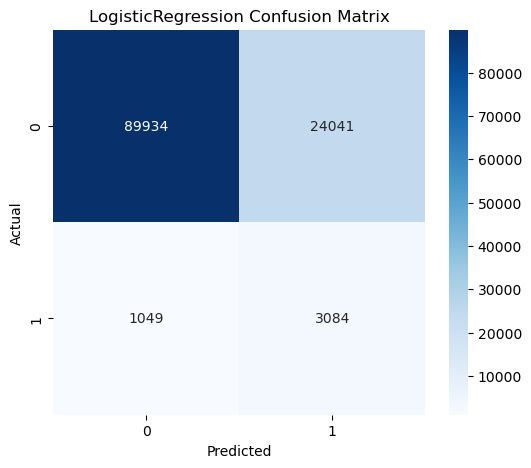


Classification Report:

              precision    recall  f1-score   support

         0.0       0.99      0.79      0.88    113975
         1.0       0.11      0.75      0.20      4133

    accuracy                           0.79    118108
   macro avg       0.55      0.77      0.54    118108
weighted avg       0.96      0.79      0.85    118108

--- DecisionTree Evaluation ---
ROC AUC Score: 0.8729468935053578
Precision Score: 0.17225484278110081
Recall Score: 0.759496733607549
F1 Score: 0.28081946680980496


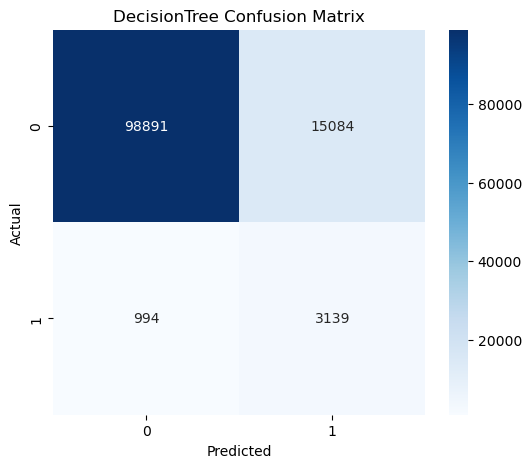


Classification Report:

              precision    recall  f1-score   support

         0.0       0.99      0.87      0.92    113975
         1.0       0.17      0.76      0.28      4133

    accuracy                           0.86    118108
   macro avg       0.58      0.81      0.60    118108
weighted avg       0.96      0.86      0.90    118108

--- RandomForest Evaluation ---
ROC AUC Score: 0.9226029262702782
Precision Score: 0.3051567239635996
Recall Score: 0.7302201790466973
F1 Score: 0.43043571275761244


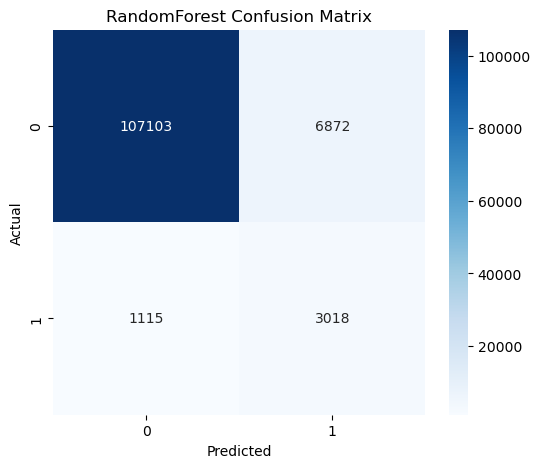


Classification Report:

              precision    recall  f1-score   support

         0.0       0.99      0.94      0.96    113975
         1.0       0.31      0.73      0.43      4133

    accuracy                           0.93    118108
   macro avg       0.65      0.83      0.70    118108
weighted avg       0.97      0.93      0.95    118108

--- XGBoost Evaluation ---
ROC AUC Score: 0.9612154876459924
Precision Score: 0.41062977793957045
Recall Score: 0.8187757077183644
F1 Score: 0.5469532891546791


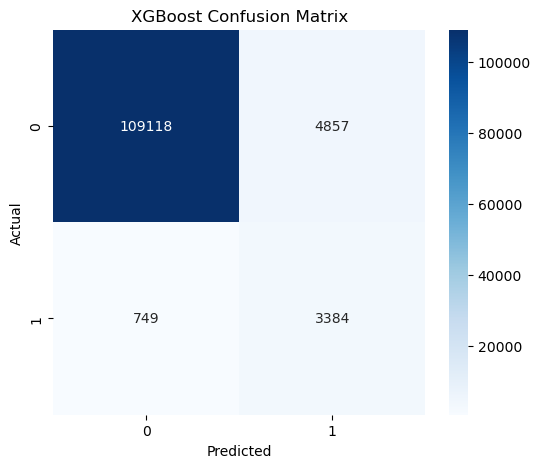


Classification Report:

              precision    recall  f1-score   support

         0.0       0.99      0.96      0.97    113975
         1.0       0.41      0.82      0.55      4133

    accuracy                           0.95    118108
   macro avg       0.70      0.89      0.76    118108
weighted avg       0.97      0.95      0.96    118108

--- LightGBM Evaluation ---
ROC AUC Score: 0.9639600130493298
Precision Score: 0.45816409423233145
Recall Score: 0.8187757077183644
F1 Score: 0.5875510026912057


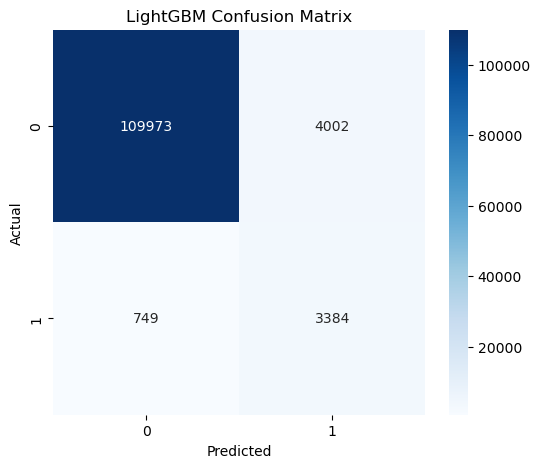


Classification Report:

              precision    recall  f1-score   support

         0.0       0.99      0.96      0.98    113975
         1.0       0.46      0.82      0.59      4133

    accuracy                           0.96    118108
   macro avg       0.73      0.89      0.78    118108
weighted avg       0.97      0.96      0.97    118108



In [88]:
results = {}

for name, model in models.items():
    # Predict labels
    y_pred = model.predict(X_val)
    
    # Predict probabilities (for ROC AUC)
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_val)[:, 1]
    else:  # some models like CatBoost
        y_proba = model.predict(X_val)  # raw prediction scores
    
    # Evaluate
    metrics = evaluate_model(y_val, y_pred, y_proba, model_name=name)
    results[name] = metrics


In [89]:
results_df = pd.DataFrame(results).T
results_df.sort_values(by='roc_auc', ascending=False)


,roc_auc,precision,recall,f1_score
LightGBM,0.963960,0.458164,0.818776,0.587551
XGBoost,0.961215,0.410630,0.818776,0.546953
RandomForest,0.922603,0.305157,0.730220,0.430436
DecisionTree,0.872947,0.172255,0.759497,0.280819
LogisticRegression,0.847528,0.113696,0.746189,0.197325




##### Analyze Metrics

**ROC AUC**  
Measures how well the model ranks fraudulent transactions higher than legitimate ones.

**Ranking:**  
**LightGBM (0.964)** > XGBoost (0.961) > RandomForest (0.923) > DecisionTree (0.873) > LogisticRegression (0.848)

- All **tree-based ensemble models** perform strongly  
- **LightGBM** slightly leads in ranking transactions by fraud probability  
- **Logistic Regression** struggles because fraud patterns are highly **non-linear and interaction-heavy**

---

**Precision**  
Measures how many predicted fraud transactions are actually fraud.

**Ranking:**  
**LightGBM (0.458)** > XGBoost (0.411) > RandomForest (0.305) > DecisionTree (0.172) > LogisticRegression (0.114)

- Even the best model has **more false positives than true fraud alerts**, which is expected due to **extreme class imbalance**  
- **LightGBM produces the cleanest fraud alerts** among all models  

---

**Recall**  
Measures how many actual fraud cases were correctly detected.

**Ranking:**  
**LightGBM (0.819)** ≈ **XGBoost (0.819)** > DecisionTree (0.759) > LogisticRegression (0.746) > RandomForest (0.730)

- **Boosting models (LightGBM & XGBoost)** catch **over 81% of fraud cases**, which is excellent  
- **RandomForest** misses more fraud cases compared to boosting models  

---

**F1 Score**  
Harmonic mean of Precision and Recall — balances fraud detection vs. false alarms.

**Ranking:**  
**LightGBM (0.588)** > XGBoost (0.547) > RandomForest (0.430) > DecisionTree (0.281) > LogisticRegression (0.197)

- **LightGBM achieves the best trade-off**, detecting many frauds without overwhelming the system with false alerts  
- **Logistic Regression and Decision Tree** perform poorly because they can’t model complex fraud behavior well  

---


**LightGBM is the best-performing model** across nearly all evaluation metrics. It provides:

- Strong fraud ranking ability (**ROC AUC**)  
- The highest precision (**cleaner alerts**)  
- Excellent recall (**catches most fraud cases**)  
- The best balance between detection and false alarms (**F1 Score**)  

**XGBoost** is a very close second, while simpler models struggle with the complexity of fraud patterns.


###### AUC ROC Curve

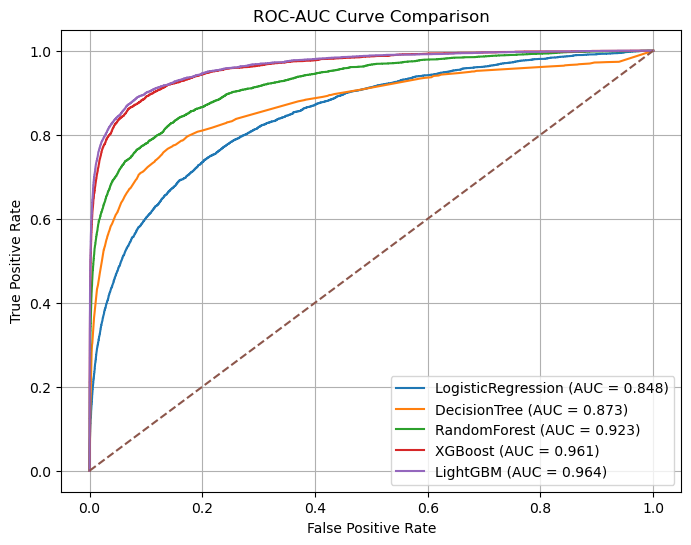

In [90]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

for name, model in models.items():
    # Get probabilities for positive class
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_val)[:, 1]
    else:
        y_proba = model.predict(X_val)

    # Compute ROC curve
    fpr, tpr, _ = roc_curve(y_val, y_proba)
    roc_auc = auc(fpr, tpr)

    # Plot curve
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")

# Random guessing line
plt.plot([0, 1], [0, 1], linestyle='--')

plt.title("ROC-AUC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()



The ROC (Receiver Operating Characteristic) curve plots **True Positive Rate (TPR)** against **False Positive Rate (FPR)** at different classification thresholds. The **AUC (Area Under the Curve)** summarizes the overall ability of the model to distinguish between positive and negative classes.


| Model                | AUC   |
|----------------------|-------|
| Logistic Regression  | 0.848 |
| Decision Tree        | 0.873 |
| Random Forest        | 0.923 |
| XGBoost              | 0.961 |
| LightGBM             | 0.964 |

**Interpretation**
- AUC ranges from **0.5** (random guessing) to **1.0** (perfect classifier).  
- Curves closer to the **top-left corner** indicate better performance.  
- **LightGBM** and **XGBoost** have the highest AUCs → they are the best at distinguishing between classes.  
- **Random Forest** performs well, slightly behind the gradient boosting models.  
- **Logistic Regression** and **Decision Tree** have lower AUCs → less effective at separating classes.  

Tree-based ensemble methods (**Random Forest, XGBoost, LightGBM**) outperform simpler models in terms of class separation. Among all, **LightGBM** achieves the best ROC-AUC.


###### Precision–Recall Curve

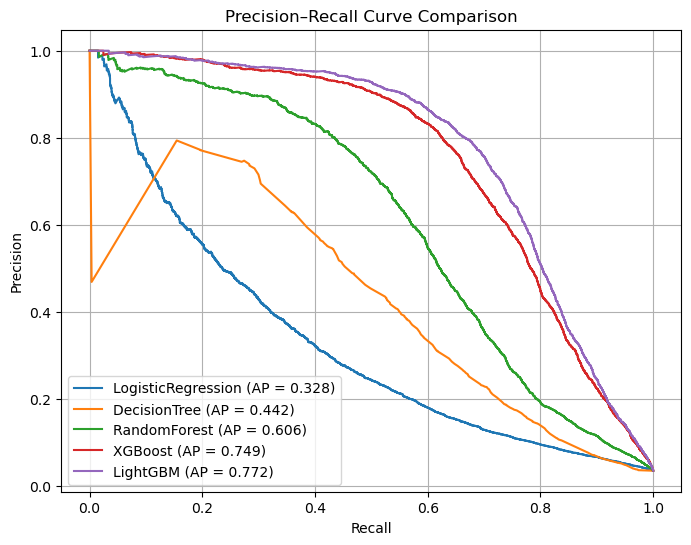

In [91]:
from sklearn.metrics import precision_recall_curve, average_precision_score

plt.figure(figsize=(8, 6))

for name, model in models.items():
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_val)[:, 1]
    else:
        y_proba = model.predict(X_val)

    precision, recall, _ = precision_recall_curve(y_val, y_proba)
    ap_score = average_precision_score(y_val, y_proba)

    plt.plot(recall, precision, label=f"{name} (AP = {ap_score:.3f})")

plt.title("Precision–Recall Curve Comparison")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.grid(True)
plt.show()



The Precision-Recall (PR) curve plots **Precision** (y-axis) against **Recall** (x-axis). It is especially useful for **imbalanced datasets** where positive examples are rare. The **AP (Average Precision)** score is the area under the PR curve.

| Model                | AP    |
|----------------------|-------|
| Logistic Regression  | 0.328 |
| Decision Tree        | 0.442 |
| Random Forest        | 0.606 |
| XGBoost              | 0.749 |
| LightGBM             | 0.772 |

**Interpretation**
- **Precision** indicates how many predicted positives are actually correct.  
- **Recall** measures how many actual positives are detected.  
- PR curves that **stay high along the x-axis** indicate strong precision even at high recall.  
- **LightGBM** maintains the highest precision across most recall values → best overall performance.  
- **XGBoost** is slightly behind LightGBM but still strong.  
- **Random Forest** is good, but performance drops at higher recall.  
- **Decision Tree** and **Logistic Regression** struggle with precision at moderate-to-high recall.  

For datasets where **precision and recall matter** (e.g., imbalanced classes), **LightGBM** is the most reliable model, followed closely by **XGBoost**. Simple models like **Logistic Regression** are not suitable in this scenario.


## Feature Importance

In [97]:
feature_names = X.columns.tolist()


In [98]:
lr_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': np.abs(log_model.named_steps['clf'].coef_[0])
}).sort_values(by='Importance', ascending=False)


In [99]:
dt_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': dt_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

rf_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)


In [100]:
xgb_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': xgb_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

lgb_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': lgb_model.feature_importances_
}).sort_values(by='Importance', ascending=False)


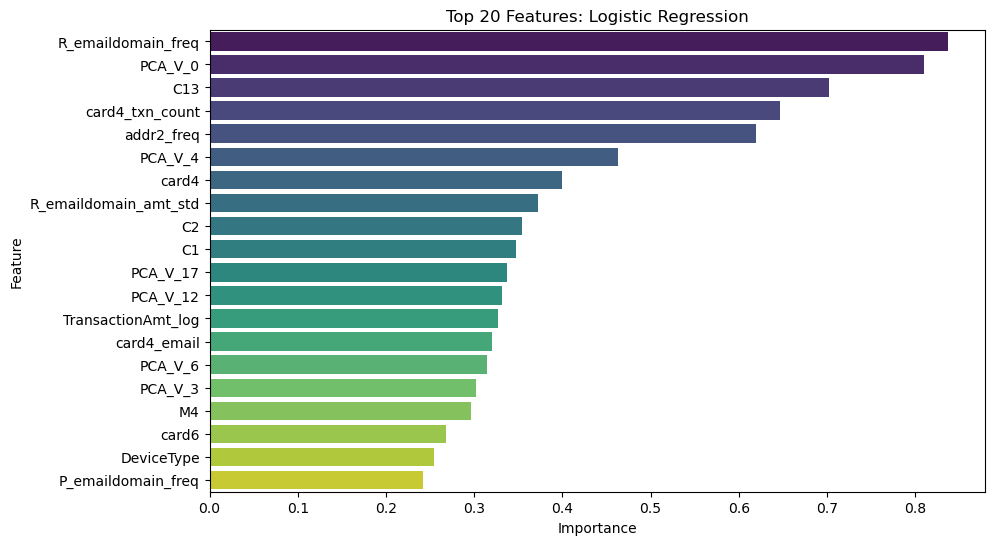

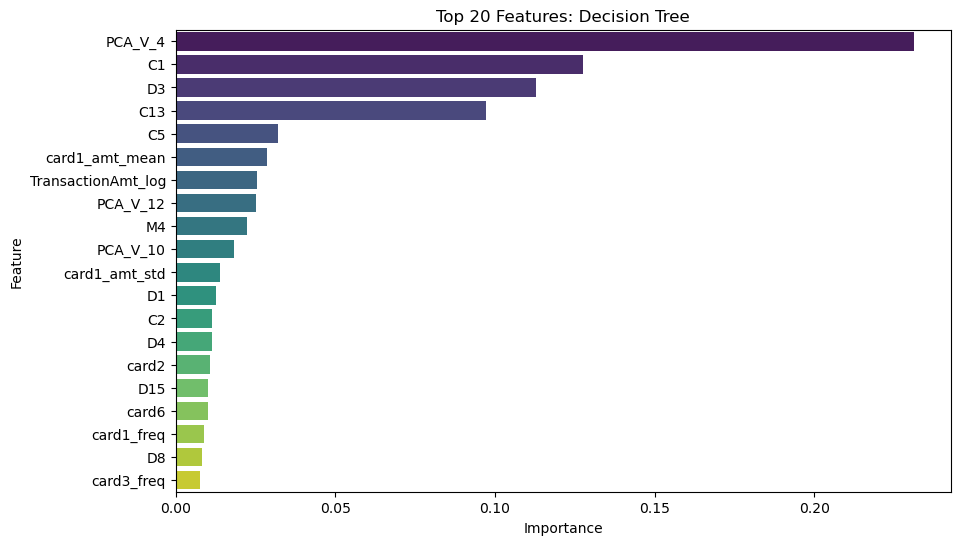

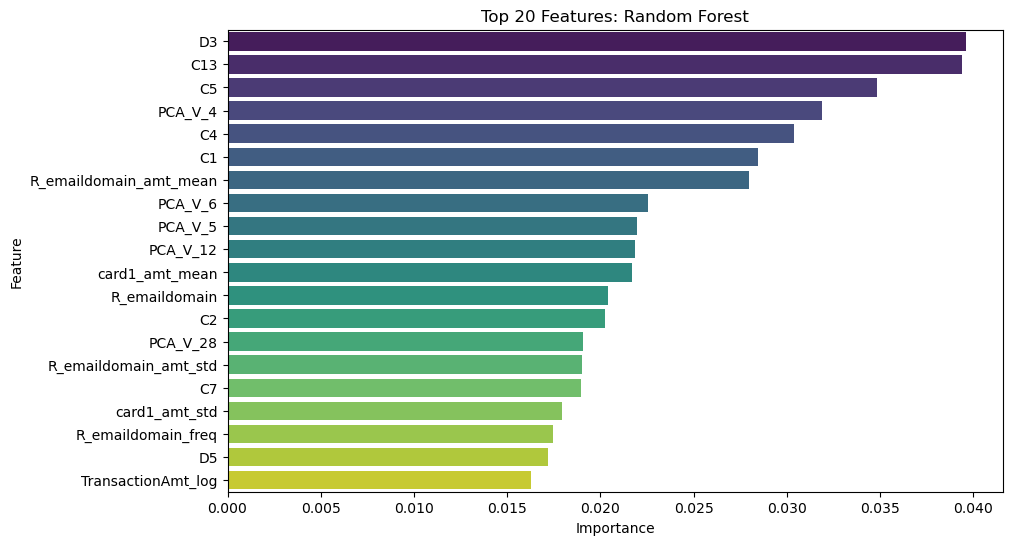

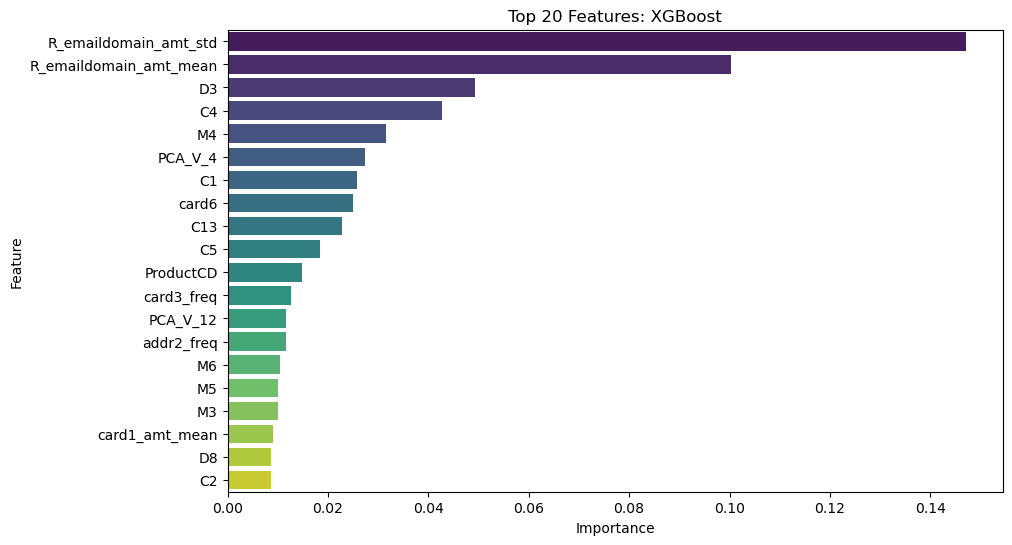

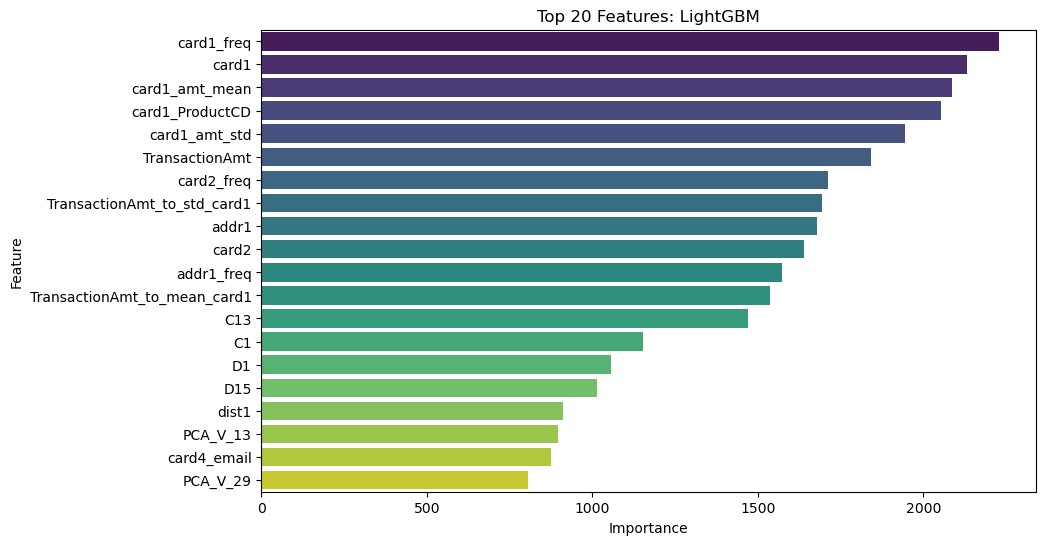

In [102]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_top_features(df, model_name, top_n=20):
    plt.figure(figsize=(10,6))
    sns.barplot(x='Importance', y='Feature', data=df.head(top_n), palette='viridis')
    plt.title(f"Top {top_n} Features: {model_name}")
    plt.show()

plot_top_features(lr_importance, "Logistic Regression")
plot_top_features(dt_importance, "Decision Tree")
plot_top_features(rf_importance, "Random Forest")
plot_top_features(xgb_importance, "XGBoost")
plot_top_features(lgb_importance, "LightGBM")


## Future recommendation for Fraud Detection

**Advanced Handling of Class Imbalance**

Fraud datasets are extremely imbalanced. While class weights were used, performance can be further improved by:

- **Using Stratified K-Fold Cross-Validation** instead of a single train-test split  
- **Trying resampling techniques**:  
  - **SMOTE** (Synthetic Minority Oversampling)  
  - **Random Under-sampling** of the majority class  
- **Using focal loss** (available in XGBoost/LightGBM custom objectives) to focus more on hard-to-classify fraud cases  


**Hyperparameter Tuning**

Most models were trained with baseline or lightly adjusted parameters. Performance can be improved through **systematic tuning**:

- **Search strategies:**  
  - Grid Search / Random Search  
  - Or more efficiently, **Optuna / Bayesian Optimization**  

- **Key parameters to tune** for LightGBM / XGBoost:  
  - `num_leaves` / `max_depth`  
  - `learning_rate`  
  - `n_estimators`  
  - `subsample`, `colsample_bytree`  
  - `min_child_samples`  


**SHAP for Better Model Interpretability**

Currently, feature importance gives a **global view**, but fraud detection often requires **transaction-level explanations**. Using **SHAP (SHapley Additive exPlanations)** allows:

- Understanding **why a specific transaction was flagged as fraud**  
- Identifying **top contributing features** per prediction  
- Building **trust with risk teams and auditors**  


